In [1]:
import cvxpy as cp
import numpy as np
import pandas as pd
from cvxpy import psd_wrap
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from cvxpy.atoms.affine.wraps import psd_wrap
from sklearn.covariance import LedoitWolf
import seaborn as sns
import pickle
from plot_functions import plot_te_carbon_by_sector, plot_origin_vs_opt_weights_comparison, plot_te_carbon_heatmap
from tabulate import tabulate
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform

| Term         | What to Use                                                     |
| ------------ | --------------------------------------------------------------- |
| `w_b_sector` | Benchmark weights **within the sector**, normalized to sum to 1 |
| `Σ_sector`   | Covariance matrix of sector constituents                        |
| `c_sector`   | Carbon intensities of sector companies                          |
| `w`          | Optimization variable: weights in sector                        |
| Constraints  | All operate **within** the sector universe                      |


# Missing Data and Scope emissions composition

In [2]:
# Load data
df = pd.read_excel("Data/out-of-sample/dataset_comp_0622.xlsx")
df.isna().any()

Unnamed: 0                       False
NAME                             False
TYPE                             False
SYMBOL                           False
GICS Sector                      False
ffnosh last day Jun 22           False
Price last day Jun 22            False
Scope 1                          False
Scope 2                          False
Scope 3                          False
Revenue                          False
Scope 1+2+3                      False
Carbon Intensity                 False
AnonID                            True
Manually Imputed Scope 2          True
Manually Imputed Scope 1          True
Manually Imputed Scope 3          True
Sector_Communication Services    False
Sector_Consumer Discretionary    False
Sector_Consumer Staples          False
Sector_Energy                    False
Sector_Financials                False
Sector_Health Care               False
Sector_Industrials               False
Sector_Information Technology    False
Sector_Materials         

In [3]:


# Columns of interest
manually_imputed_flags = ['Manually Imputed Scope 1', 'Manually Imputed Scope 2', 'Manually Imputed Scope 3']
imputed_flags = ['Scope 1 Imputed', 'Scope 2 Imputed', 'Scope 3 Imputed']

# Build the summary table
summary_rows = []

for sector, group in df.groupby('GICS Sector'):
    n_stocks = len(group)
    row = {
        'Sector': sector,
        'Number of Stocks': n_stocks
    }

    # Automatically imputed
    for col in imputed_flags:
        count = group[col].fillna(False).sum()
        row[f'{col} Count'] = count
        row[f'{col} %'] = count / n_stocks * 100

    # Manually imputed
    for col in manually_imputed_flags:
        count = group[col].fillna(False).sum()
        row[f'{col} Count'] = count
        row[f'{col} %'] = count / n_stocks * 100

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values("Sector")
summary_df.reset_index(drop=True, inplace=True)
# Round all percentage columns to integers
percentage_cols = [col for col in summary_df.columns if '%' in col]
summary_df[percentage_cols] = summary_df[percentage_cols].round(0).astype('Int64')
# Create 'Missing Scope' as the sum of max imputed counts across S1/S2/S3
summary_df["Missing Scope Count"] = summary_df[
    ["Scope 1 Imputed Count", "Scope 2 Imputed Count", "Scope 3 Imputed Count"]
].max(axis=1) + summary_df[
    ["Manually Imputed Scope 1 Count", "Manually Imputed Scope 2 Count", "Manually Imputed Scope 3 Count"]
].max(axis=1)

# Now compute Missing Scope % over sector
summary_df["Missing Scope (%)"] = (summary_df["Missing Scope Count"] / summary_df["Number of Stocks"] * 100).round(0).astype('Int64')

# Define the new column order
columns_order = ['Sector', 'Number of Stocks', 'Missing Scope Count', 'Missing Scope (%)'] + \
                [col for col in summary_df.columns if col not in ['Sector', 'Number of Stocks', 'Missing Scope Count', 'Missing Scope (%)']]

# Reorder the columns
summary_df = summary_df[columns_order]

# Sort by "Missing Scope (%)"
summary_df = summary_df.sort_values("Missing Scope (%)", ascending=False)

# Optional: reset index for clean display
summary_df = summary_df.reset_index(drop=True)

summary_df

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_32803/3858772605.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  count = group[col].fillna(False).sum()
/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_32803/3858772605.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  count = group[col].fillna(False).sum()


,Sector,Number of Stocks,Missing Scope Count,Missing Scope (%),Scope 1 Imputed Count,Scope 1 Imputed %,Scope 2 Imputed Count,Scope 2 Imputed %,Scope 3 Imputed Count,Scope 3 Imputed %,Manually Imputed Scope 1 Count,Manually Imputed Scope 1 %,Manually Imputed Scope 2 Count,Manually Imputed Scope 2 %,Manually Imputed Scope 3 Count,Manually Imputed Scope 3 %
0,Energy,21,10.0,48,0.0,0,0.0,0,10.0,48,0.0,0,0.0,0,0.0,0
1,Health Care,64,25.0,39,2.0,3,2.0,3,24.0,38,1.0,2,1.0,2,1.0,2
2,Industrials,76,27.0,36,2.0,3,2.0,3,25.0,33,2.0,3,2.0,3,1.0,1
3,Consumer Discretionary,54,16.0,30,1.0,2,2.0,4,14.0,26,2.0,4,2.0,4,2.0,4
4,Real Estate,31,9.0,29,1.0,3,1.0,3,8.0,26,1.0,3,0.0,0,0.0,0
5,Communication Services,23,6.0,26,3.0,13,3.0,13,5.0,22,1.0,4,1.0,4,1.0,4
6,Consumer Staples,37,9.0,24,0.0,0,0.0,0,6.0,16,3.0,8,3.0,8,1.0,3
7,Financials,74,18.0,24,4.0,5,4.0,5,13.0,18,5.0,7,5.0,7,5.0,7
8,Information Technology,63,12.0,19,2.0,3,2.0,3,11.0,17,1.0,2,1.0,2,1.0,2
9,Materials,28,4.0,14,0.0,0,0.0,0,4.0,14,0.0,0,0.0,0,0.0,0


In [4]:
def sector_aggregates(df, top_weight_pct=0.2):
    results = []

    total_mcap = df["float_mcap"].sum()  # total benchmark market cap

    for sector, g in df.groupby("GICS Sector"):
        # absolute totals
        s1 = g["Scope 1"].sum()
        s2 = g["Scope 2"].sum()
        s3 = g["Scope 3"].sum()
        total_emissions = g["Scope 1+2+3"].sum()

        # percentages of each scope
        pct_s1, pct_s2, pct_s3 = s1/total_emissions, s2/total_emissions, s3/total_emissions

        # top 5 emitters in sector
        top5 = g.nlargest(5, "Scope 1+2+3")["Scope 1+2+3"].sum() / total_emissions

        # emissions captured within top X% of sector weights
        g_sorted = g.sort_values("weight_in_sector", ascending=False).copy()
        g_sorted["cum_weight"] = g_sorted["weight_in_sector"].cumsum()
        emissions_top_weight = g_sorted.loc[g_sorted["cum_weight"] <= top_weight_pct, "Scope 1+2+3"].sum()
        pct_emissions_top_weight = emissions_top_weight / total_emissions

        # sector market cap as percentage of benchmark
        sector_mcap = g["float_mcap"].sum()
        sector_mcap_pct = sector_mcap / total_mcap

        results.append({
            "Sector": sector,
            "Scope 1 sum": s1,
            "Scope 2 sum": s2,
            "Scope 3 sum": s3,
            "Scope 1+2+3 absolute": total_emissions,
            "% Scope 1": pct_s1,
            "% Scope 2": pct_s2,
            "% Scope 3": pct_s3,
            "% Top 5 emitters": top5,
            f"% Emissions in Top {int(top_weight_pct*100)}% Weight": pct_emissions_top_weight,
            "Avg Scope 1+2+3": g["Scope 1+2+3"].mean(),
            "Avg Scope 1": g["Scope 1"].mean(),
            "Avg Scope 2": g["Scope 2"].mean(),
            "Avg Scope 3": g["Scope 3"].mean(),
            "Var Scope 1": g["Scope 1"].std(),
            "Var Scope 2": g["Scope 2"].std(),
            "Var Scope 3": g["Scope 3"].std(),
            "Avg Carbon Intensity": g["Carbon Intensity"].mean(),
            "Aggregate Carbon Intensity": total_emissions / g["Revenue"].sum(),
            "Sector Market Cap %": sector_mcap_pct
        })

    return pd.DataFrame(results)


In [5]:
pd.options.display.float_format = '{:,.2f}'.format
df = sector_aggregates(df)
pct_cols = ["% Scope 1", "% Scope 2", "% Scope 3", "% Top 5 emitters", 
            "% Emissions in Top 20% Weight", "Sector Market Cap %"]

df[pct_cols] = df[pct_cols].applymap(lambda x: f"{x:.1%}")

round_cols = ["Avg Scope 1+2+3", "Avg Scope 1", "Avg Scope 2", "Avg Scope 3",
              "Var Scope 1", "Var Scope 2", "Var Scope 3",
              "Avg Carbon Intensity", "Aggregate Carbon Intensity"]

df[round_cols] = df[round_cols].round(2)
def human_format(num):
    for unit in ['', 'K', 'M', 'B', 'T']:
        if abs(num) < 1000:
            return f"{num:.1f}{unit}"
        num /= 1000
    return f"{num:.1f}P"

num_cols = ["Scope 1 sum","Scope 2 sum","Scope 3 sum","Scope 1+2+3 absolute"]
df[num_cols] = df[num_cols].applymap(human_format)
df

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_32803/3136223177.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[pct_cols] = df[pct_cols].applymap(lambda x: f"{x:.1%}")
/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_32803/3136223177.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[num_cols] = df[num_cols].applymap(human_format)


,Sector,Scope 1 sum,Scope 2 sum,Scope 3 sum,Scope 1+2+3 absolute,% Scope 1,% Scope 2,% Scope 3,% Top 5 emitters,% Emissions in Top 20% Weight,Avg Scope 1+2+3,Avg Scope 1,Avg Scope 2,Avg Scope 3,Var Scope 1,Var Scope 2,Var Scope 3,Avg Carbon Intensity,Aggregate Carbon Intensity,Sector Market Cap %
0,Communication Services,32.1M,37.2M,342.0M,411.3M,7.8%,9.0%,83.2%,86.5%,0.0%,"17,882,739.51","1,394,937.20","1,616,191.59","14,871,610.72","5,718,445.06","2,431,152.07","51,991,456.30",0.09,0.03,9.1%
1,Consumer Discretionary,41.7M,25.7M,1.2B,1.3B,3.2%,2.0%,94.8%,75.4%,0.0%,"23,863,095.36","772,684.02","476,207.96","22,614,203.38","2,261,876.55","885,507.85","68,259,208.86",0.56,0.63,10.4%
2,Consumer Staples,45.8M,36.0M,1.2B,1.3B,3.6%,2.8%,93.6%,67.4%,13.8%,"34,778,973.07","1,237,700.88","973,402.73","32,567,869.46","2,541,294.78","1,696,872.70","61,335,849.79",0.60,0.61,7.7%
3,Energy,327.1M,44.8M,1.9B,2.2B,14.6%,2.0%,83.4%,59.2%,0.0%,"106,996,572.11","15,578,087.19","2,134,062.24","89,284,422.68","22,719,013.48","2,532,132.70","97,774,422.89",3.40,1.76,4.3%
4,Financials,79.6M,26.9M,927.7M,1.0B,7.7%,2.6%,89.7%,92.8%,0.1%,"13,976,093.22","1,076,042.76","363,773.40","12,536,277.06","6,325,723.53","1,400,417.83","53,497,497.48",0.96,0.06,13.2%
5,Health Care,47.8M,14.3M,492.2M,554.3M,8.6%,2.6%,88.8%,67.6%,6.0%,"8,660,520.94","746,284.29","223,246.55","7,690,990.09","4,978,877.62","519,612.16","29,560,545.00",0.15,0.14,15.1%
6,Industrials,250.6M,17.4M,3.5B,3.8B,6.7%,0.5%,92.9%,68.2%,2.1%,"49,513,666.59","3,296,888.08","229,149.21","45,987,629.30","8,090,624.50","288,905.45","151,866,013.84",2.15,0.74,8.4%
7,Information Technology,43.3M,31.7M,562.4M,637.4M,6.8%,5.0%,88.2%,65.2%,0.0%,"10,117,755.61","687,524.99","503,466.11","8,926,764.52","4,246,778.00","1,232,193.46","35,829,212.91",0.29,0.13,23.3%
8,Materials,142.4M,68.3M,452.8M,663.5M,21.5%,10.3%,68.2%,61.5%,9.6%,"23,695,458.48","5,085,633.86","2,438,385.08","16,171,439.55","6,957,153.23","4,310,354.92","23,957,753.82",1.49,1.46,2.6%
9,Real Estate,19.8M,13.1M,176.8M,209.7M,9.4%,6.2%,84.3%,90.4%,2.5%,"6,765,693.78","638,410.52","422,650.67","5,704,632.59","3,164,460.17","904,563.28","21,076,086.29",0.28,0.17,3.0%


High concentration + low overlap with cap weights = easier to decarbonize with minimal tracking error. (for example this is the case for consumer discretionary that should be easier to decarbonise compared to inf. technology)

Low concentration + emissions aligned with big caps = harder to decarbonize without straying from the benchmark. (Health care harder to decarbonise compared to Consumer Staples )


# TE - CARBON FRONTIERS
Clipping negative eigenvalues to 0 and reconstructing the closest possible PSD matrix to the original covariance matrix in Frobenius norm

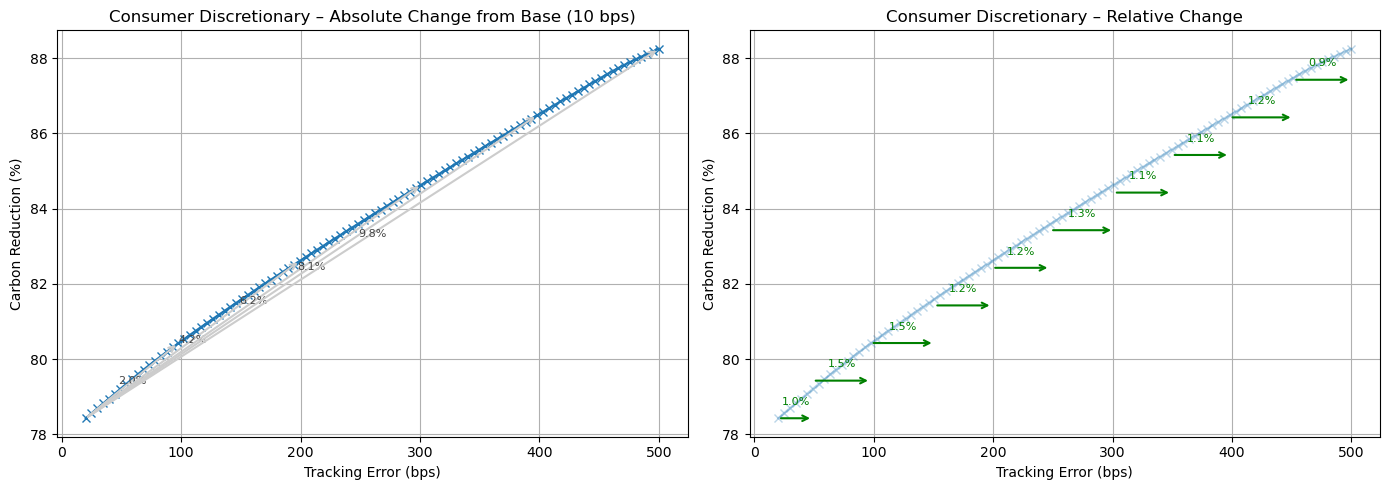

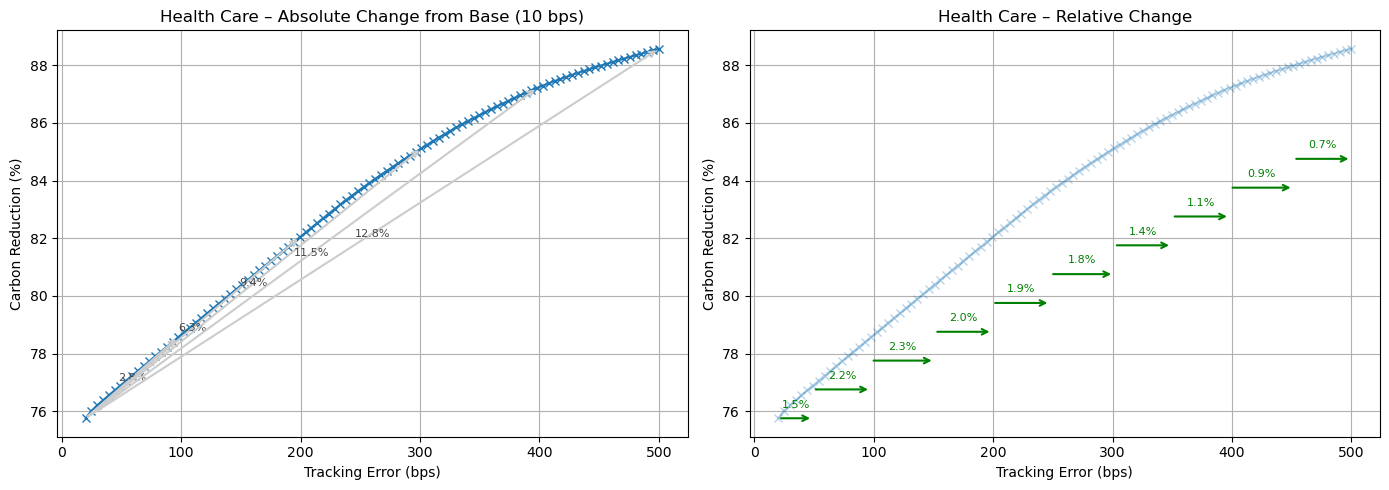

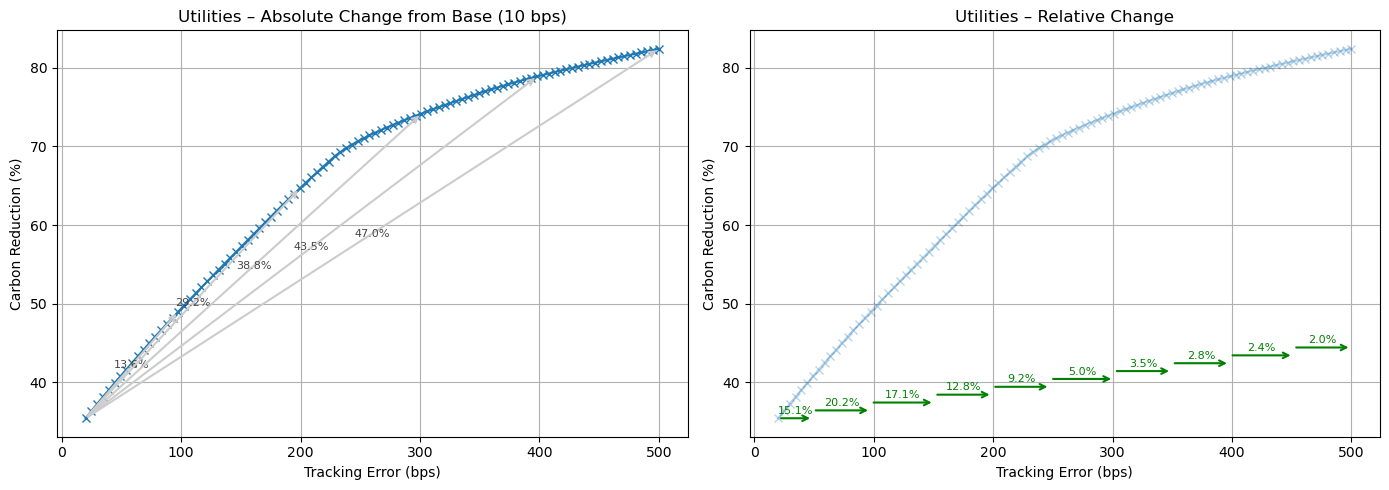

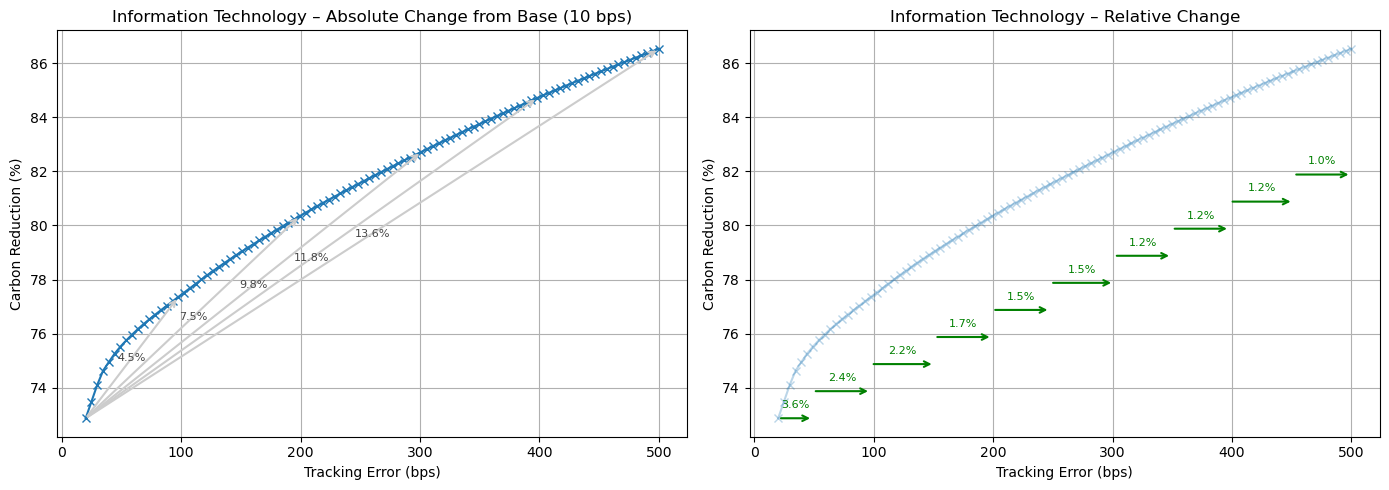

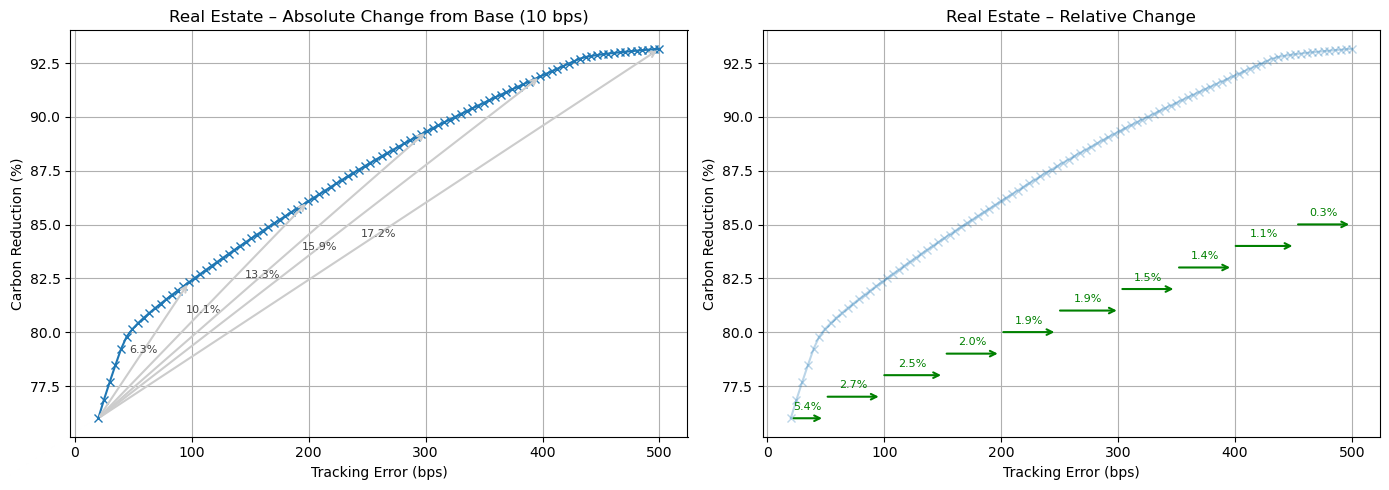

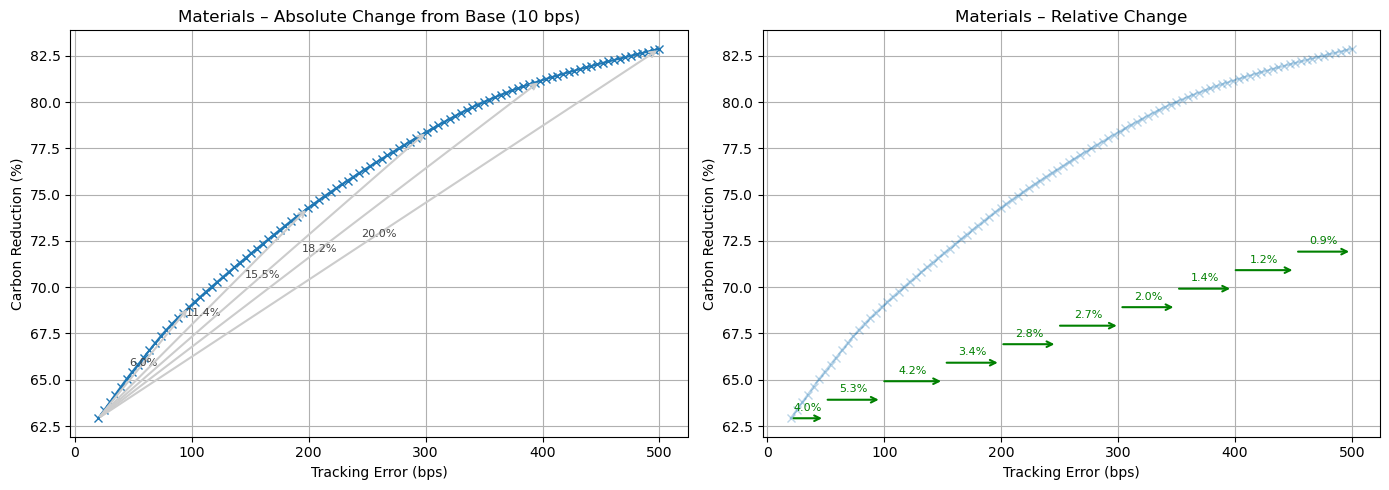

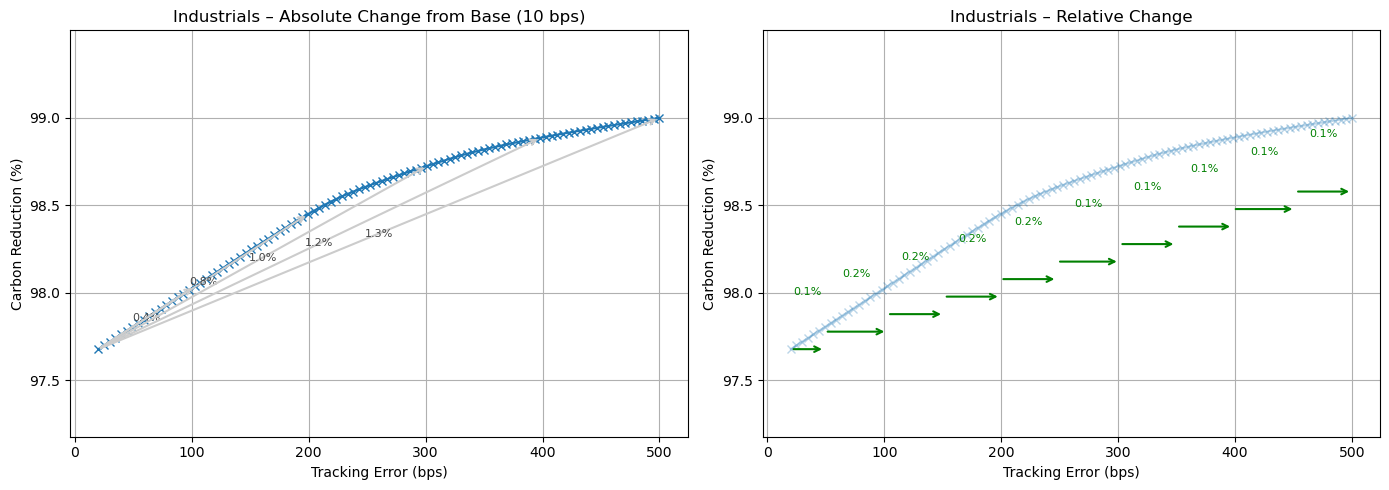

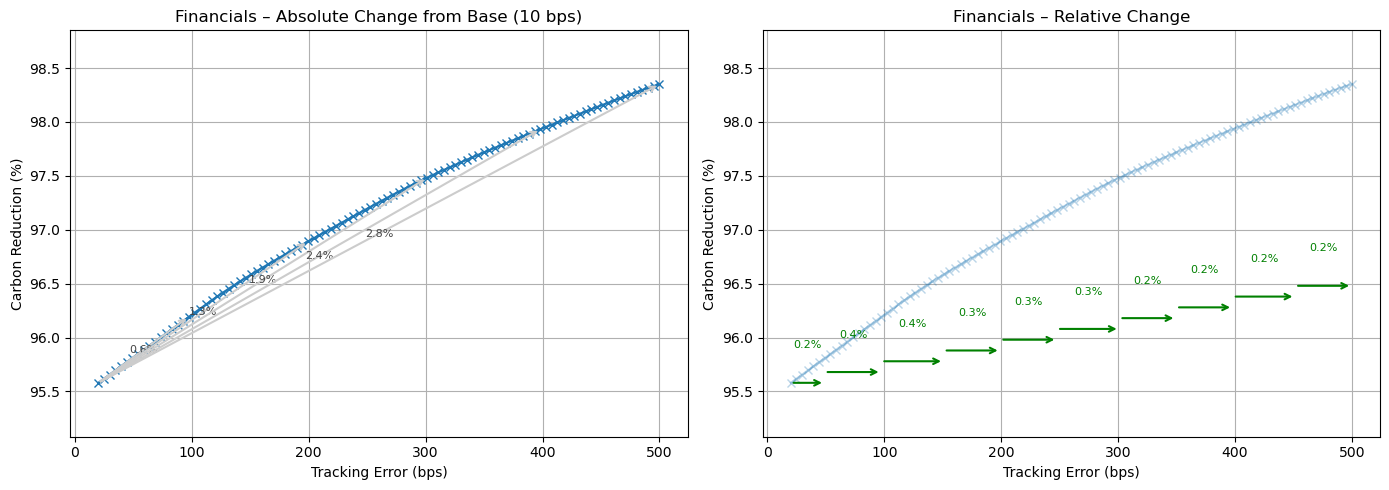

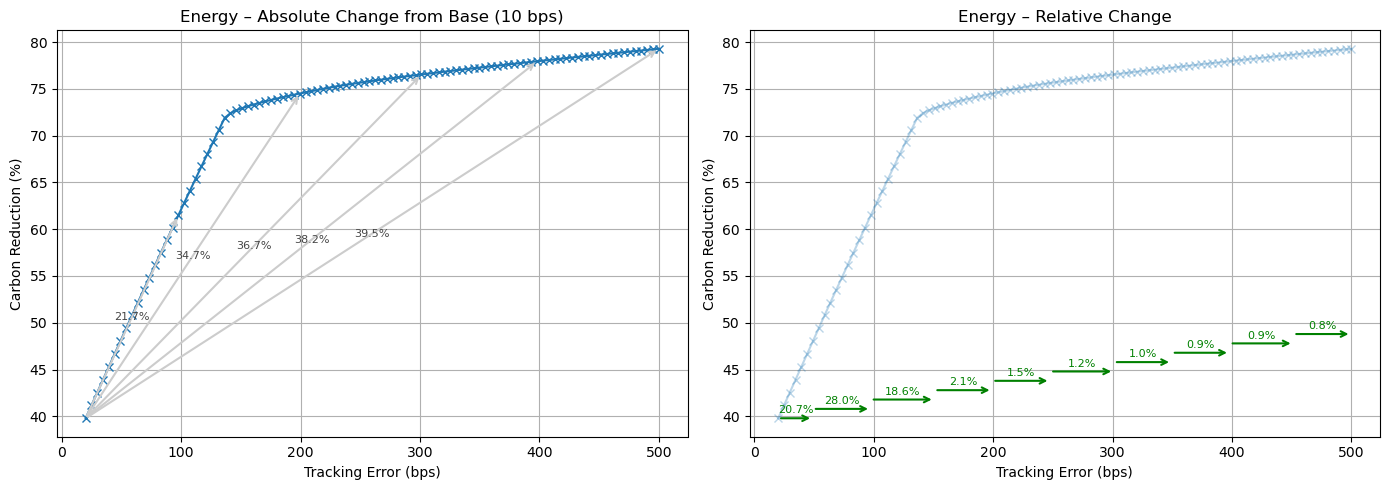

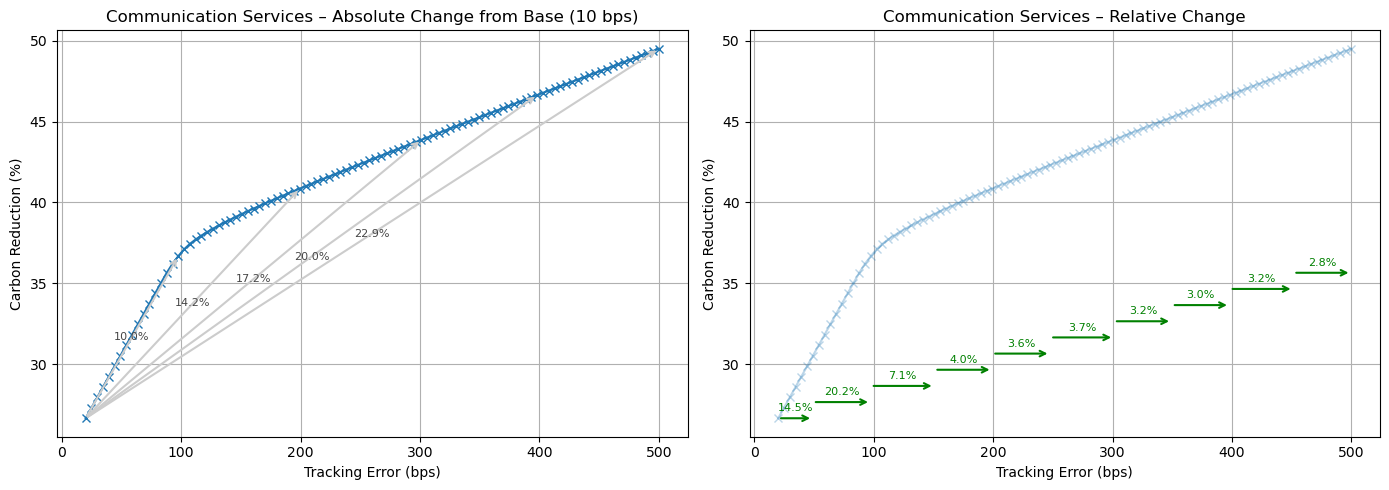

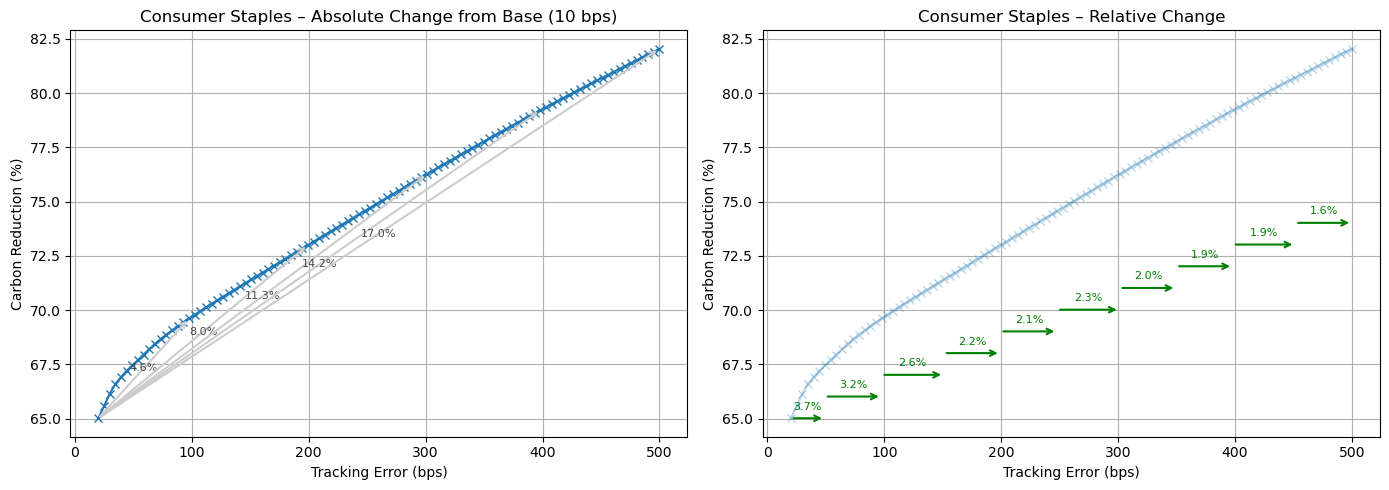

| Sector                 |   Num Features |   Rank |   Min_Eigval1 |   Min_Eigval2 |   Min_Eigval3 |   Min_Eigval4 |   Min_Eigval5 | Low Rank?   | Not PSD?   |
|------------------------|----------------|--------|---------------|---------------|---------------|---------------|---------------|-------------|------------|
| Communication Services |             23 |     12 |  -4.59701e-18 |  -2.90438e-18 |  -1.97511e-18 |  -7.12315e-19 |   1.35141e-18 | True        | False      |
| Consumer Discretionary |             54 |     12 |  -1.08922e-17 |  -6.30336e-18 |  -5.52939e-18 |  -4.12753e-18 |  -3.59682e-18 | True        | False      |
| Consumer Staples       |             37 |     12 |  -2.28081e-18 |  -1.6419e-18  |  -1.46291e-18 |  -1.02177e-18 |  -7.79077e-19 | True        | False      |
| Energy                 |             21 |     12 |  -5.06434e-18 |  -2.53744e-18 |  -3.49363e-19 |   2.00194e-19 |   1.0062e-18  | True        | False      |
| Financials             |             7

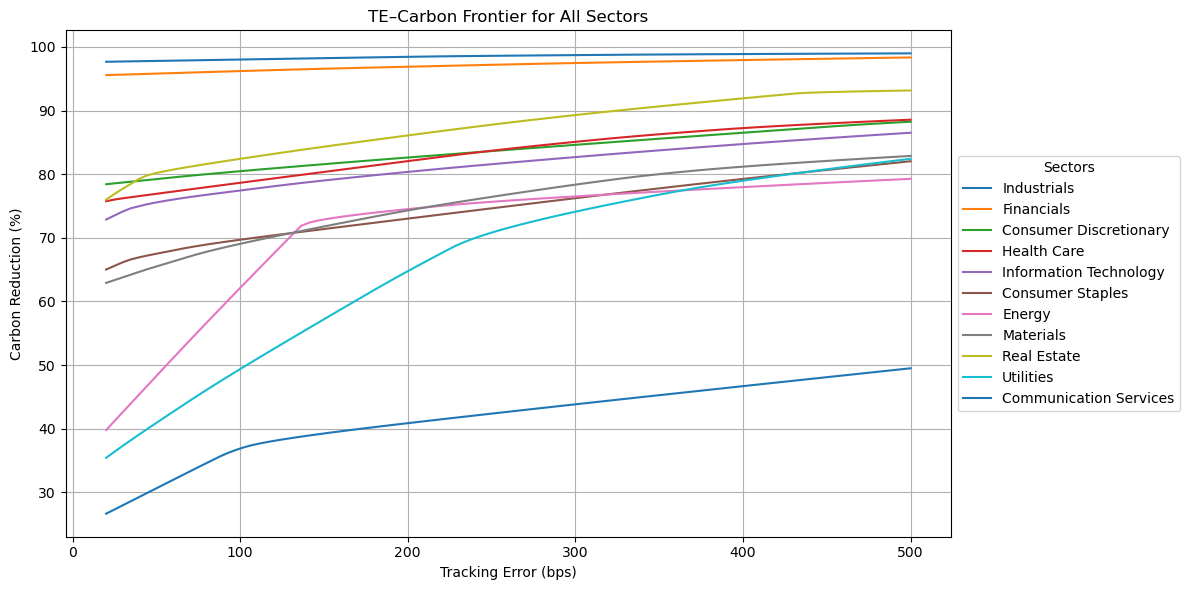

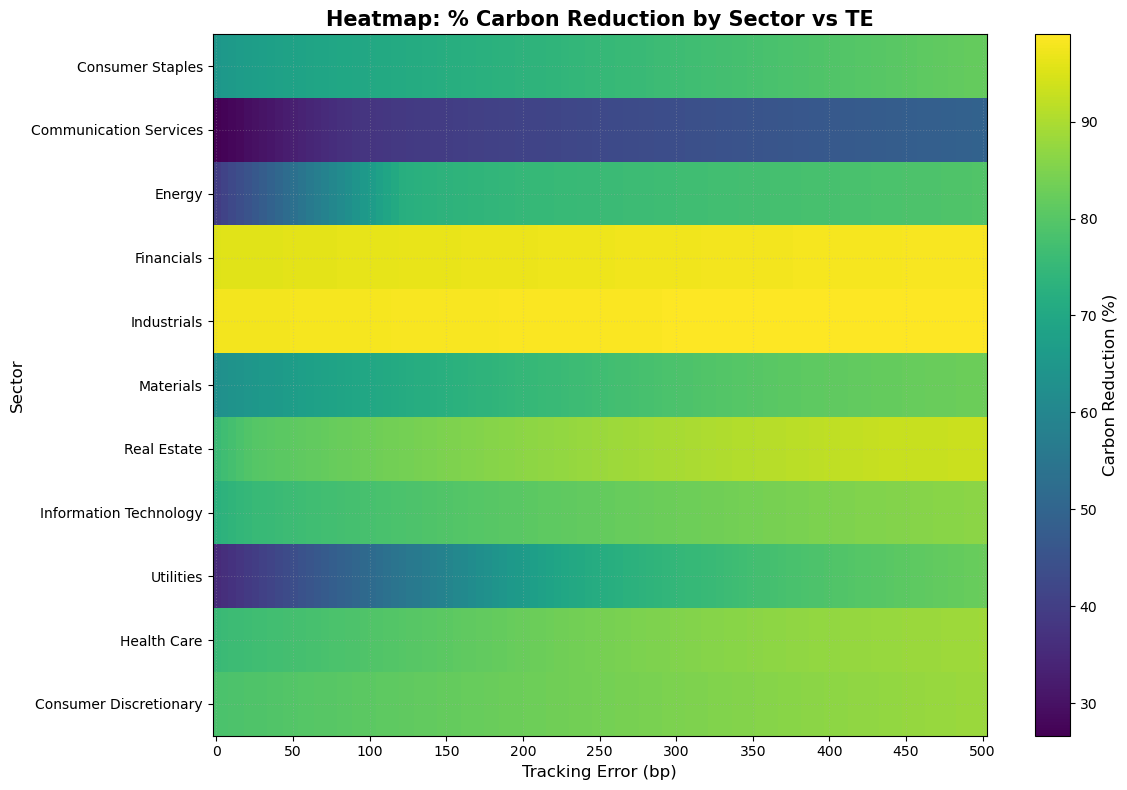

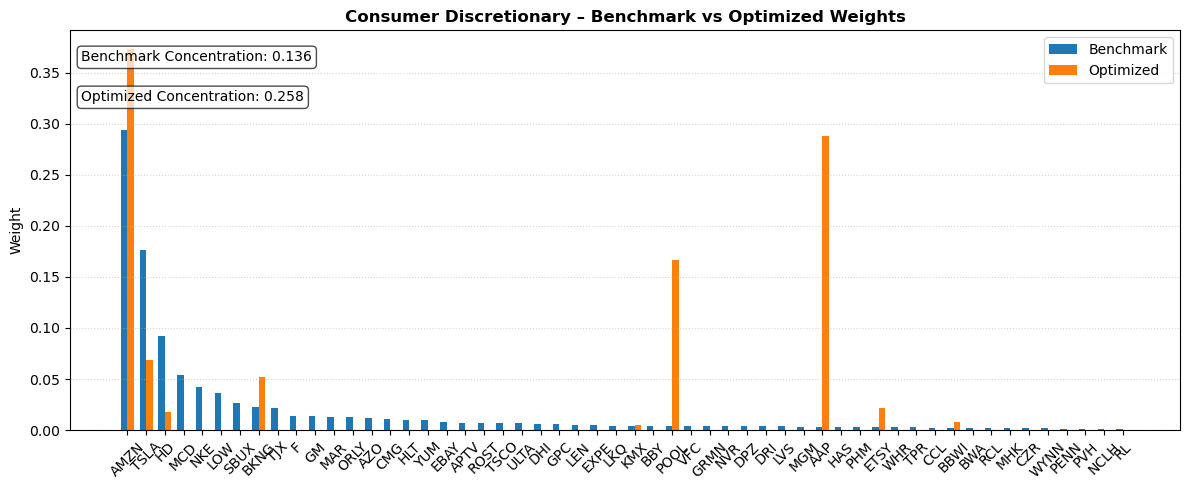

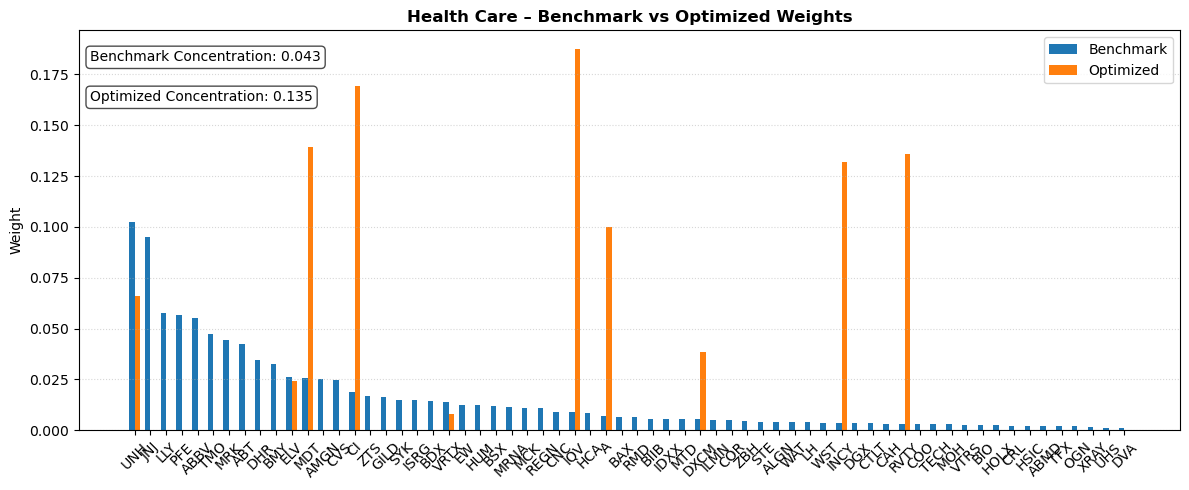

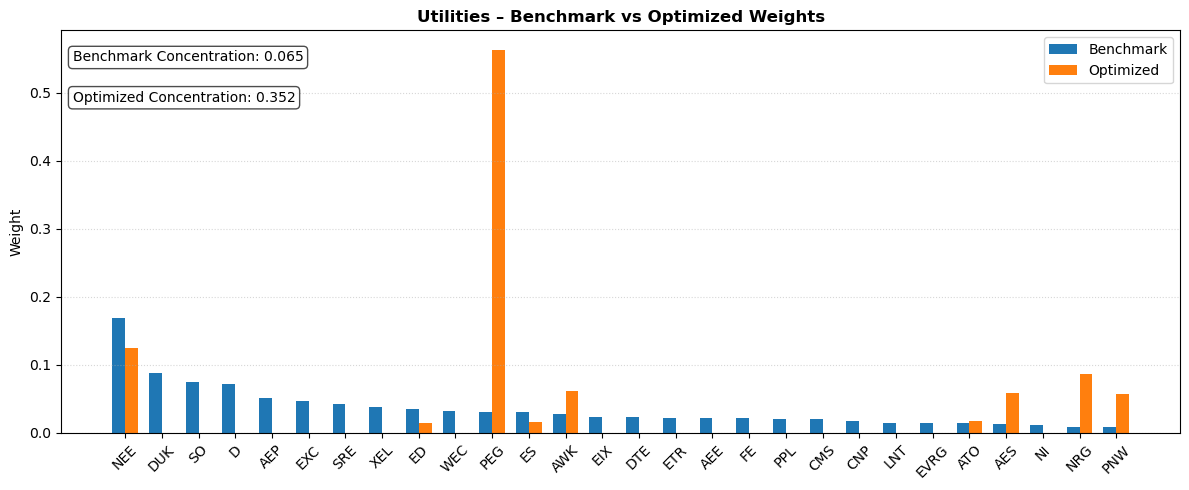

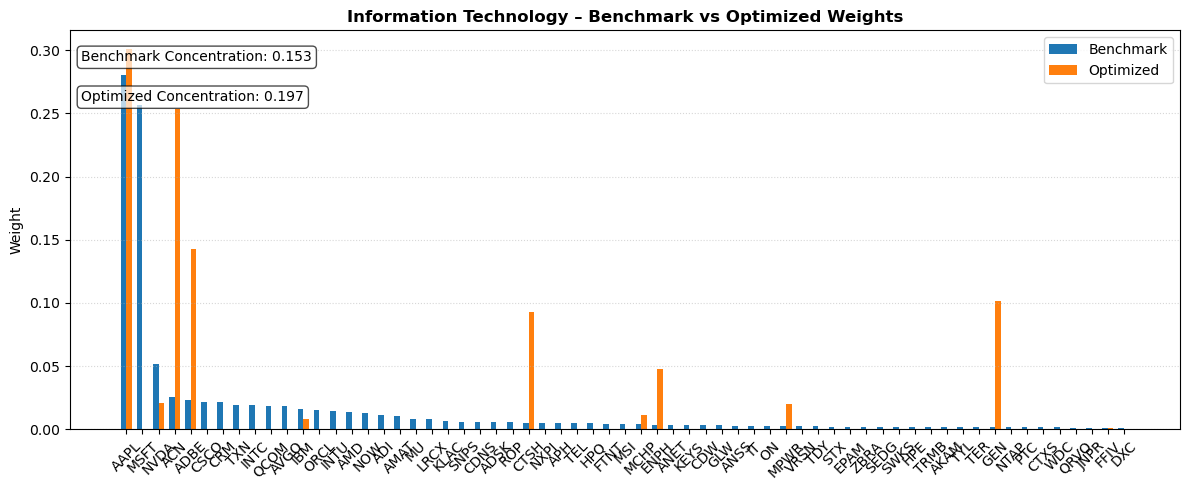

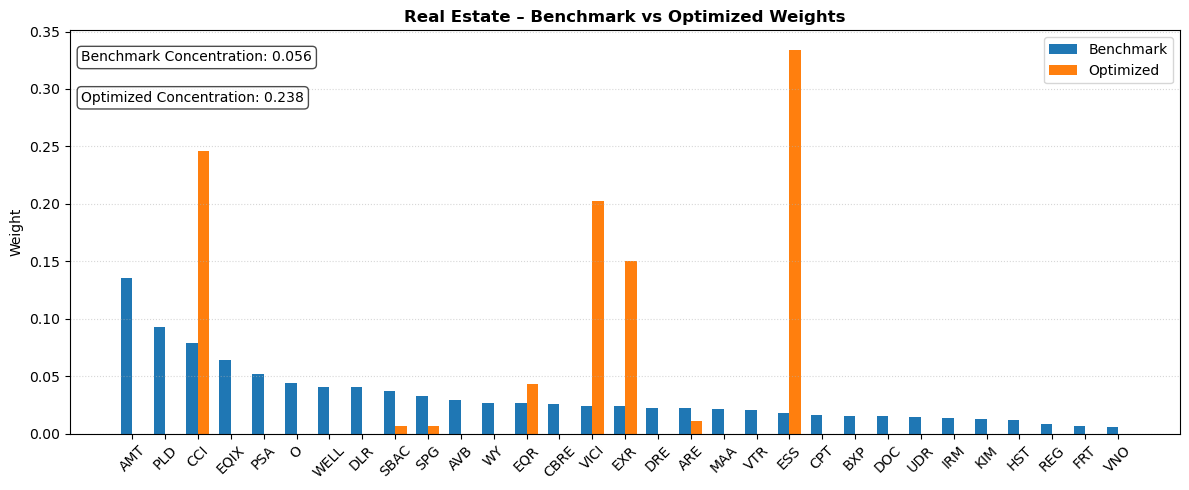

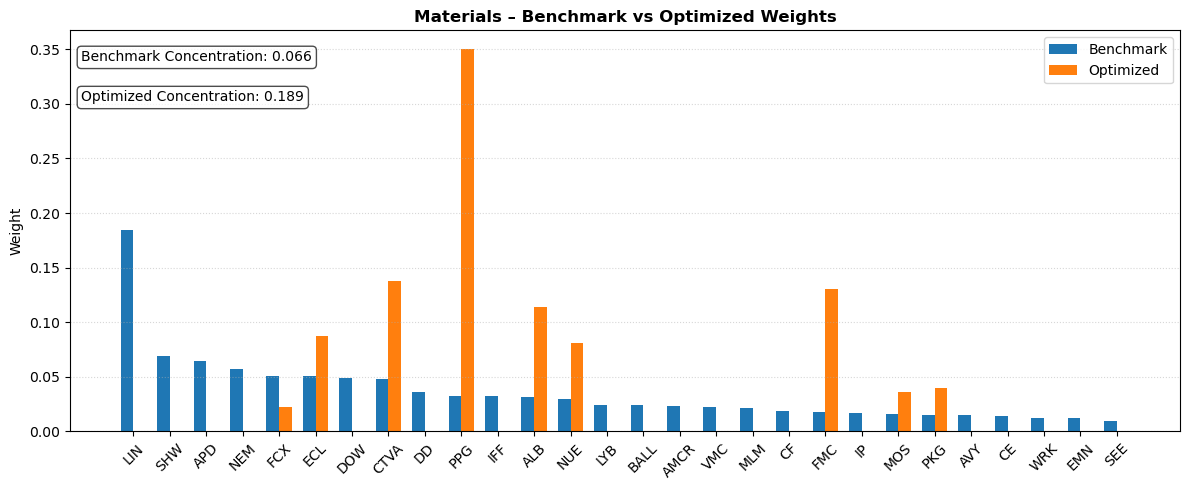

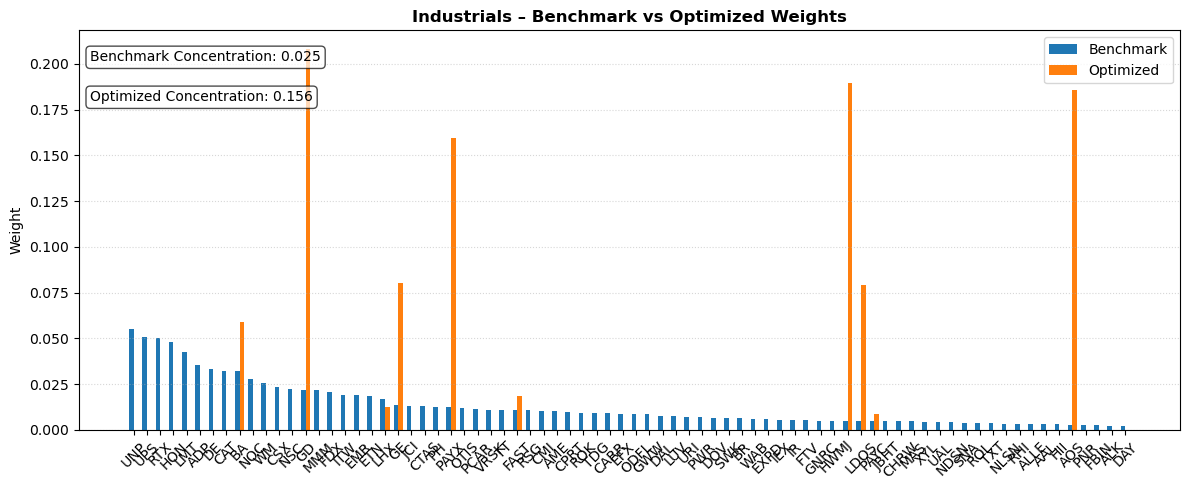

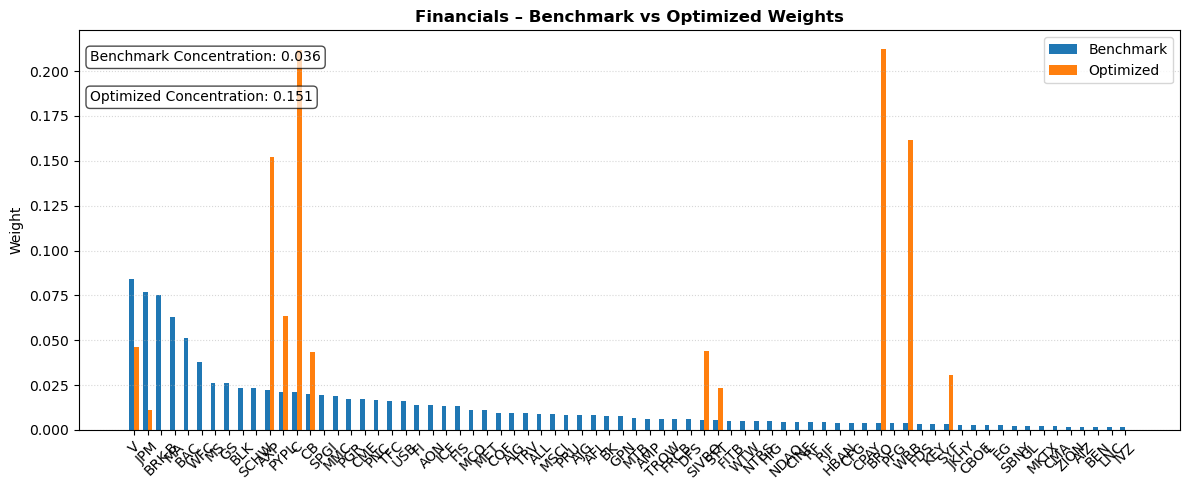

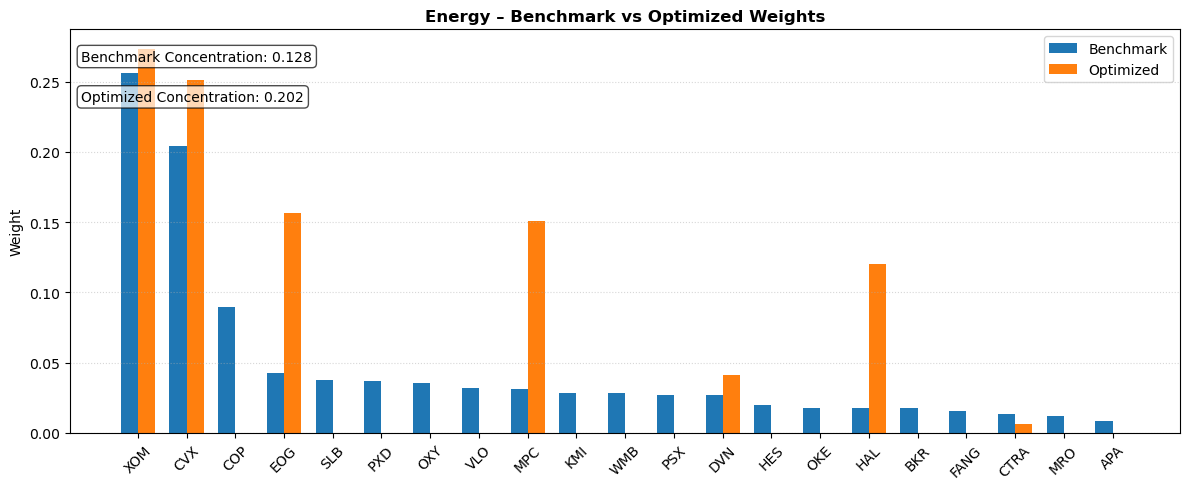

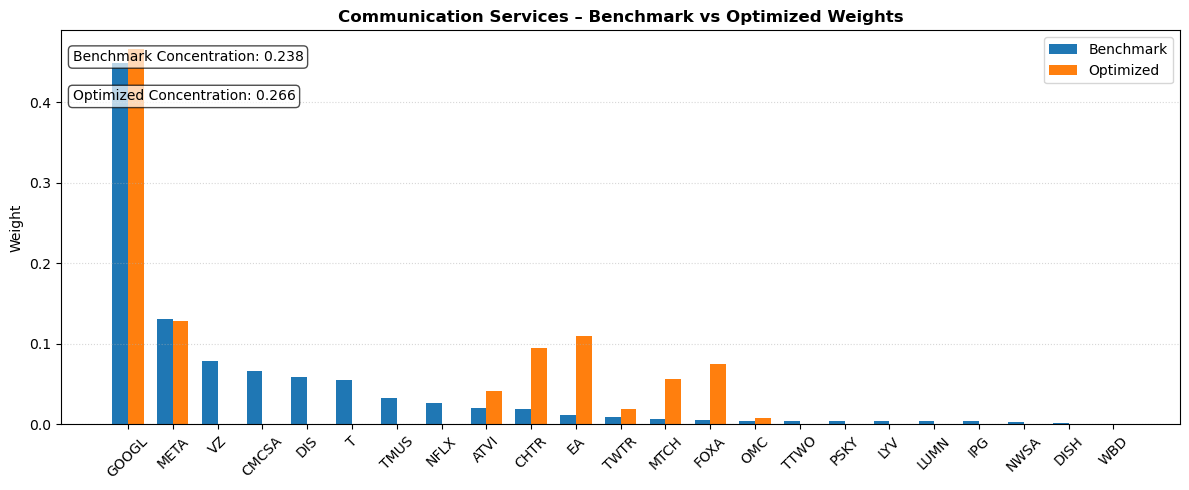

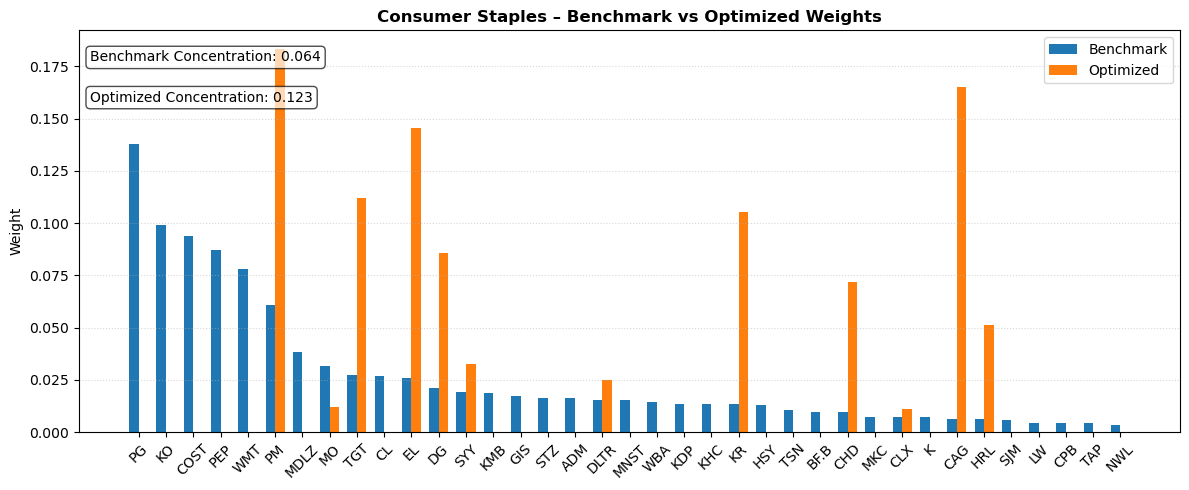

In [6]:
data = pd.read_excel("Data/out-of-sample/dataset_comp_0622.xlsx")
diagnostics_raw = []
diagnostics_clipped = []

def nearest_psd(A):
    eigvals, eigvecs = np.linalg.eigh(A)
    eigvals[eigvals < 0] = 0  # clip negative eigenvalues
    return eigvecs @ np.diag(eigvals) @ eigvecs.T # reconstructing the covariance matrix in frobenius norm
# Raw Sigma from empirical returns
def sigma_raw_fn(R_clean):
    Sigma_sector = R_clean.cov()
    return Sigma_sector



sector_weights = {} 
optimal_portfolios = {}
diagnostics = []
reductions_raw = []

for sector_name in data['GICS Sector'].unique():
    sector = data.loc[data['GICS Sector'] == sector_name]



    # Benchmark weights (should sum to 1)
    w_b_sector = sector[['weight_in_sector']]
    assert np.isclose(w_b_sector.sum().values[0], 1.0), f"{sector_name}: weights don't sum to 1"

    # Carbon intensities
    c_sector = sector[['Carbon Intensity']]
    assert c_sector.isna().sum().values[0] == 0, f"{sector_name}: carbon data has NaNs"

    R = pd.read_excel("Data/out-of-sample/sector_log_returns_comp_0622.xlsx", sheet_name=sector_name)
    # Drop the 'Date' column — keep only numeric log returns
    R_numeric = R.drop(columns=['Date'])
    R_clean = R_numeric.dropna()
    stock_labels = R_clean.columns
    Sigma_raw = sigma_raw_fn(R_clean)
    # Raw Sigma
    eigvals_raw = np.linalg.eigvalsh(Sigma_raw)
    rank_raw = np.linalg.matrix_rank(Sigma_raw)
    num_features = Sigma_raw.shape[1]
    smallest_eigs_raw = np.sort(eigvals_raw)[:5]
    
    Sigma_clipped = nearest_psd(Sigma_raw)
    Sigma_sector = Sigma_clipped

    

    diagnostics_raw.append({
        "Sector": sector_name,
        "Num Features": num_features,
        "Rank": rank_raw,
        "Min_Eigval1": smallest_eigs_raw[0],
        "Min_Eigval2": smallest_eigs_raw[1] if len(smallest_eigs_raw) > 1 else np.nan,
        "Min_Eigval3": smallest_eigs_raw[2] if len(smallest_eigs_raw) > 2 else np.nan,
        "Low Rank?": rank_raw < num_features,
        "Not PSD?": eigvals_raw.min() < -1e-6
    })

    # Clipped Sigma
    eigvals_clip = np.linalg.eigvalsh(Sigma_clipped)
    rank_clip = np.linalg.matrix_rank(Sigma_clipped)
    smallest_eigs_clip = np.sort(eigvals_clip)[:5]

    diagnostics_clipped.append({
        "Sector": sector_name,
        "Num Features": num_features,
        "Rank": rank_clip,
        "Min_Eigval1": smallest_eigs_clip[0],
        "Min_Eigval2": smallest_eigs_clip[1] if len(smallest_eigs_clip) > 1 else np.nan,
        "Min_Eigval3": smallest_eigs_clip[2] if len(smallest_eigs_clip) > 2 else np.nan,
        "Low Rank?": rank_clip < num_features,
        "Not PSD?": eigvals_clip.min() < -1e-6
    })

    eigvals = np.linalg.eigvalsh(Sigma_sector)
    rank = np.linalg.matrix_rank(Sigma_sector)
    num_features = Sigma_sector.shape[1]


    # Convert covariance matrix to correlation matrix
    stddev = np.sqrt(np.diag(Sigma_sector))
    corr_matrix = Sigma_sector / np.outer(stddev, stddev)
    

   

    # Inputs
    N = len(w_b_sector)
    w_b_vec = w_b_sector.values.flatten()
    c_vec = c_sector.values.flatten()
    
   
    sector_weights[sector_name] = {
    'weights_by_te': [],         # list of np.array
    'tracking_errors': [],
    'carbon_reductions': [],
    'w_b_vec': w_b_vec,
    'stock_labels': list(stock_labels),  
    'relative_deltas':[]
    }
    # TE caps and results
    te_caps_annual = np.linspace(0.002, 0.05, 100)  # up to 10% TE
    tracking_errors = []
    carbon_reductions = []
    smallest_eigs = np.sort(eigvals)[:5]

    for te_annual in te_caps_annual:
        # Convert to monthly variance
        te_cap_var_monthly = (te_annual / np.sqrt(12)) ** 2

        # Optimization
        w = cp.Variable(N)
        tracking_error = cp.quad_form(w - w_b_vec, psd_wrap(Sigma_sector))
        constraints = [
            tracking_error <= te_cap_var_monthly,
            cp.sum(w) == 1,
            w >= 0,
        ]
        objective = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.ECOS, verbose=False)
        # Check if solution is usable
        if prob.status in ["optimal", "optimal_inaccurate"] and w.value is not None:
            pass
        else:
            print("Optimization failed or unreliable:", prob.status)
        w_opt = w.value
        if w_opt is not None:
            # Ex-post tracking error (annualized)
            diff = w_opt - w_b_vec
            te_real = np.sqrt(diff.T @ Sigma_sector @ diff) * np.sqrt(12)
            tracking_errors.append(te_real * 10000)  # in bps

            # Carbon reduction
            carbon_b = w_b_vec @ c_vec
            carbon_opt = w_opt @ c_vec
            reduction_pct = (carbon_b - carbon_opt) / carbon_b * 100
            carbon_reductions.append(reduction_pct)
            sector_weights[sector_name]['weights_by_te'].append(w_opt)
            sector_weights[sector_name]['tracking_errors'].append(te_real * 10000)
            sector_weights[sector_name]['carbon_reductions'].append(reduction_pct)



   
            if np.round(te_annual, 3) == 0.02:
                optimal_portfolios[sector_name] = {
                "w_b_vec": w_b_vec,
                "w_opt": w_opt,
                "stock_labels": stock_labels}
                # w_b_vec is the benchmark weights vector
                # w_opt is the optimised weights vector
                # stock labels is the companies name
                benchmark_df =  pd.DataFrame({"w": w_b_vec, "symbol": stock_labels})
                optimised_df = pd.DataFrame({"w": w_opt, "symbol": stock_labels})
                benchmark_df.sort_values(by = 'w', ascending=False, inplace=True)
                optimised_df.sort_values(by = 'w', ascending=False, inplace=True)

                # Count if the leading asset by portfolio weight in the optimized allocation aligns with that of the benchmark portfolio.
                optimal_portfolios[sector_name].update({'count_1' : 1 if benchmark_df['symbol'].values[0] == optimised_df['symbol'].values[0] else 0})
                # Count how many assets coincide by comparing the three assets with the highest weight in the optimized allocation coincide with the top three weighted consitutents of the benchmark portfolio.
                optimal_portfolios[sector_name].update({'count_3' : len(set(benchmark_df['symbol'].values[:3]).intersection(set(optimised_df['symbol'].values[:3])))})
                # Count how many assets coincide by comparing the five assets with the highest weight in the optimized allocation coincide with the 
                # 
                # 
                #  five weighted consitutents of the benchmark portfolio.
                optimal_portfolios[sector_name].update({'count_5' : len(set(benchmark_df['symbol'].values[:5]).intersection(set(optimised_df['symbol'].values[:5])))})
                # Count how many assets coincide by comparing the ten assets with the highest weight in the optimized allocation coincide with the top ten weighted consitutents of the benchmark portfolio.
                optimal_portfolios[sector_name].update({'count_10' : len(set(benchmark_df['symbol'].values[:10]).intersection(set(optimised_df['symbol'].values[:10])))})

                # Count stocks with non-zero weights in the optimised portfolio:
                optimal_portfolios[sector_name].update({'zero_stocks': len(optimised_df.loc[optimised_df['w'] < 1e-04])})
                optimal_portfolios[sector_name].update({'zero_stocks_%': len(optimised_df.loc[optimised_df['w'] < 1e-04])/len(optimised_df)})
                
    # Define the tracking error breakpoints (in bps)
    absolute_te_points = [100, 200, 300, 400, 500]
    relative_te_points = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500]

    tracking_errors_np = np.array(tracking_errors)
    carbon_reductions_np = np.array(carbon_reductions)
    # === Carbon Summary Diagnostics ===
    if len(carbon_reductions_np) > 0:
        start_reduction = carbon_reductions_np[0]
        end_reduction = carbon_reductions_np[-1]
        total_gain = end_reduction - start_reduction

        idx_2pct = np.argmin(np.abs(tracking_errors_np - 200))  # ~2% TE = 200bps
        reduction_at_2pct = carbon_reductions_np[idx_2pct]

        diagnostics.append({
            "Sector": sector_name,
            "Num Features": num_features,
            "Rank": rank,
            "Min_Eigval1": smallest_eigs[0],
            "Min_Eigval2": smallest_eigs[1] if len(smallest_eigs) > 1 else np.nan,
            "Min_Eigval3": smallest_eigs[2] if len(smallest_eigs) > 2 else np.nan,
            "Min_Eigval4": smallest_eigs[3] if len(smallest_eigs) > 3 else np.nan,
            "Min_Eigval5": smallest_eigs[4] if len(smallest_eigs) > 4 else np.nan,
            "Low Rank?": rank < num_features,
            "Not PSD?": eigvals.min() < -1e-6,
        })
        reductions_raw.append({
            "Sector": sector_name,
            "Start Reduction (%)": round(start_reduction, 2),
            "End Reduction (%)": round(end_reduction, 2),
            "Gain (%)": round(total_gain, 2),
            "Reduction @2% TE (%)": round(reduction_at_2pct, 2)})
    plot_te_carbon_by_sector(tracking_errors=tracking_errors, carbon_reductions=carbon_reductions, tracking_errors_np=tracking_errors_np, absolute_te_points=absolute_te_points, sector_name=sector_name, sector_weights=sector_weights, relative_te_points=relative_te_points)

diagnostics_df = pd.DataFrame(diagnostics)
diagnostics_df = diagnostics_df.sort_values("Sector")  # optional
print(tabulate(diagnostics_df, headers='keys', tablefmt='github', showindex=False))
print()
reductions_raw_df = pd.DataFrame(reductions_raw)
reductions_raw_df = reductions_raw_df.sort_values("Gain (%)", ascending=False)  # optional
print(tabulate(reductions_raw_df, headers='keys', tablefmt='github', showindex=False))

# print("Before clipping & reconstructing matrix:")
# diagnostics_raw_df = pd.DataFrame(diagnostics_raw)
# diagnostics_raw_df = diagnostics_raw_df.sort_values("Sector")  # optional

# print(tabulate(diagnostics_raw_df, headers='keys', tablefmt='github', showindex=False))

# print("After Clipping & reconstructing matrix:")
# diagnostics_clipped_df = pd.DataFrame(diagnostics_clipped)
# diagnostics_clipped_df = diagnostics_clipped_df.sort_values("Sector")  # optional

# print(tabulate(diagnostics_clipped_df, headers='keys', tablefmt='github', showindex=False))

# Custom sector order
ordered_sectors = [
    "Industrials",
    "Financials",
    "Consumer Discretionary",
    "Health Care",
    "Information Technology",
    "Consumer Staples",
    "Energy",
    "Materials",
    "Real Estate",
    "Utilities",
    "Communication Services"
]

plt.figure(figsize=(12, 6))  # Wider figure helps with spacing

for sector_name in ordered_sectors:
    if sector_name in sector_weights:
        metrics = sector_weights[sector_name]
        plt.plot(metrics['tracking_errors'], metrics['carbon_reductions'], label=sector_name)

plt.xlabel('Tracking Error (bps)')
plt.ylabel('Carbon Reduction (%)')
plt.title('TE–Carbon Frontier for All Sectors')

# Legend outside right
plt.legend(title="Sectors", loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.grid(True)
plt.tight_layout()  # Adjust layout to fit legend
plt.show()


plot_te_carbon_heatmap(sector_weights=sector_weights, te_caps_annual=te_caps_annual)

for sector_name, data in optimal_portfolios.items():
    plot_origin_vs_opt_weights_comparison(
        data["w_b_vec"],
        data["w_opt"],
        data["stock_labels"],
        sector_name=sector_name,
        weight_comp_bool=True
    )

# TE - CARBON FRONTIERS WITH COVARIANCE REGULARIZATION
Ledoit-Wolf shrinkage + clipping eigenvalues + λI regularization:

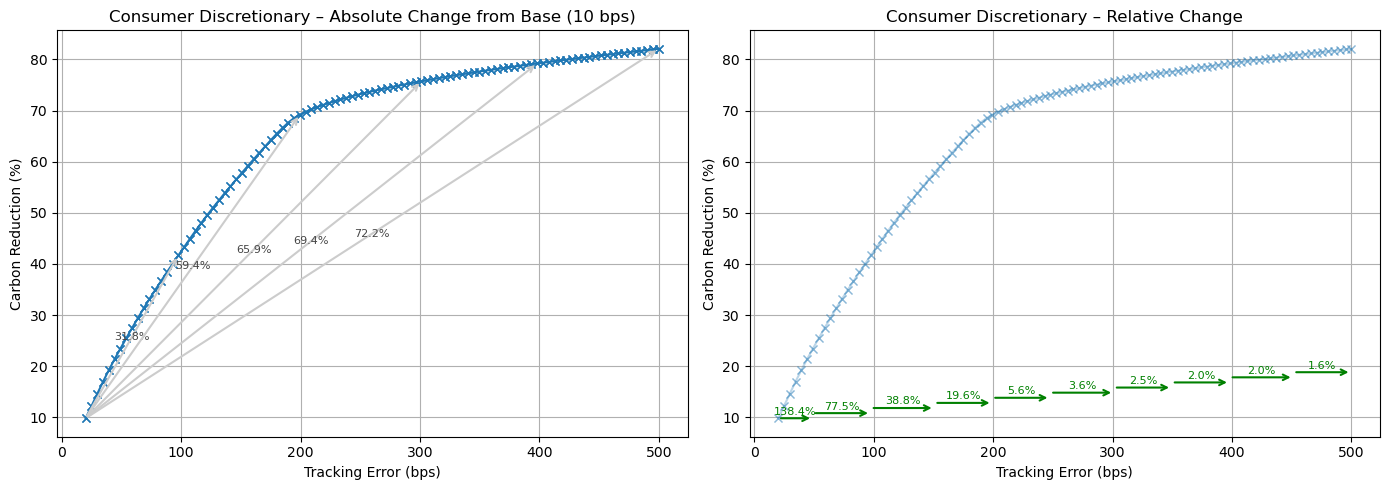

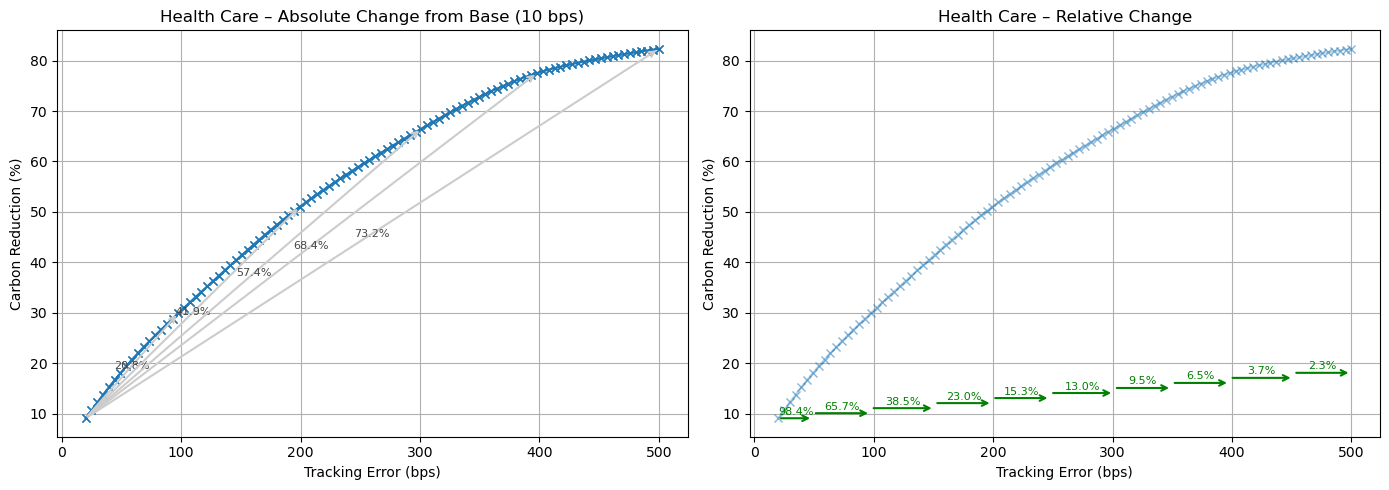

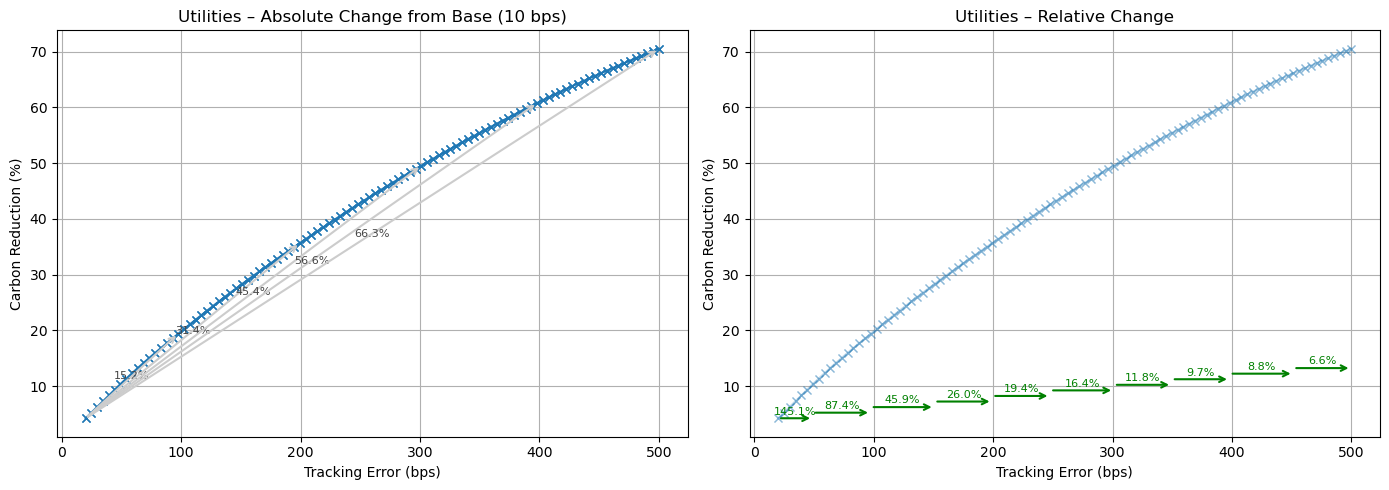

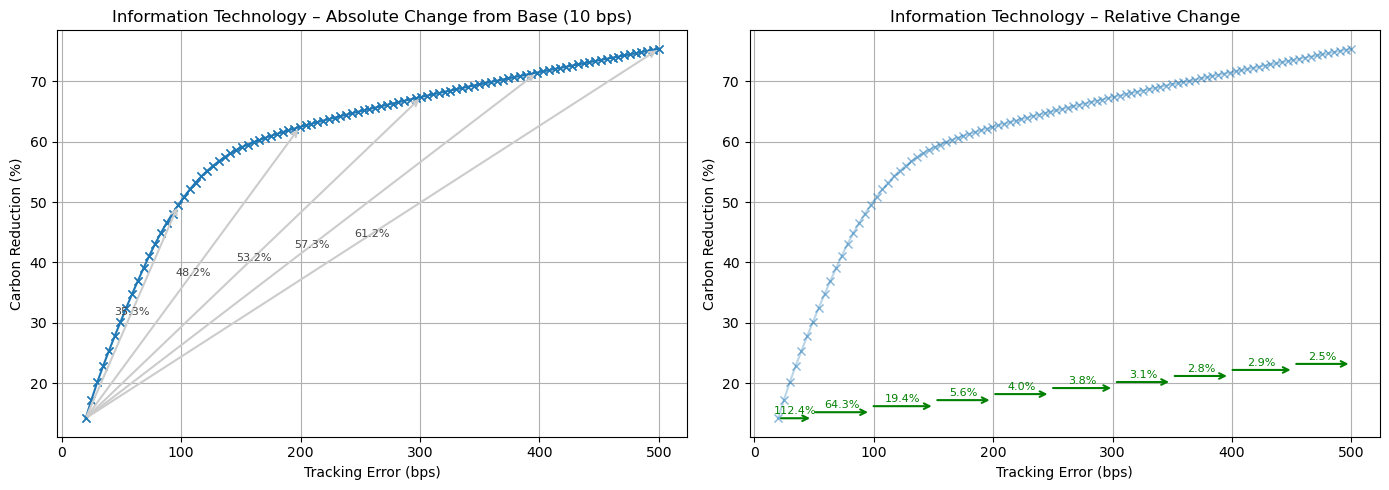

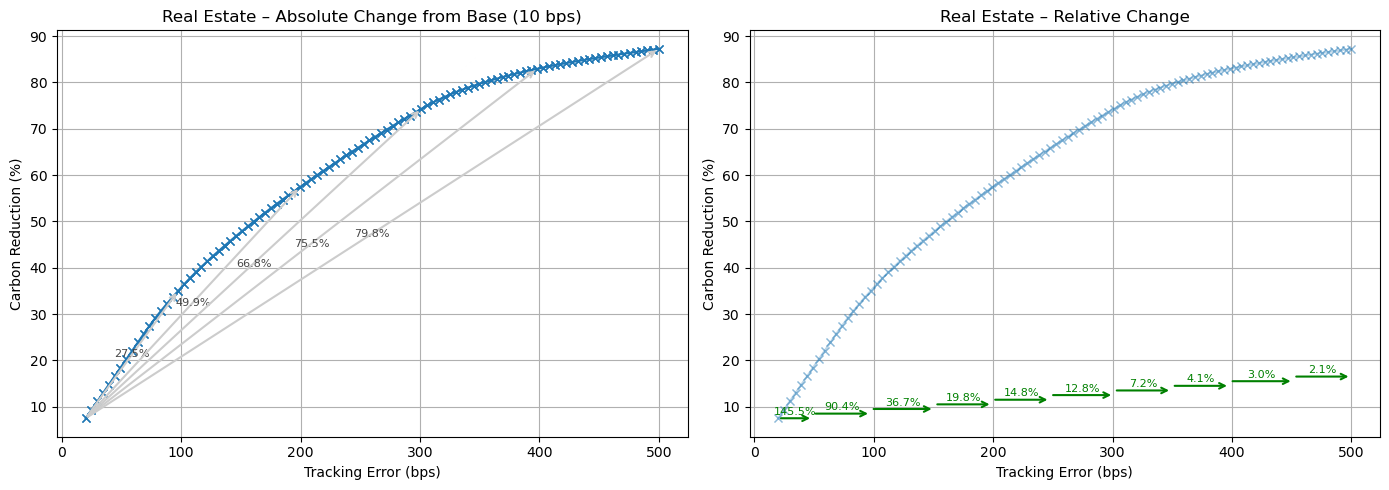

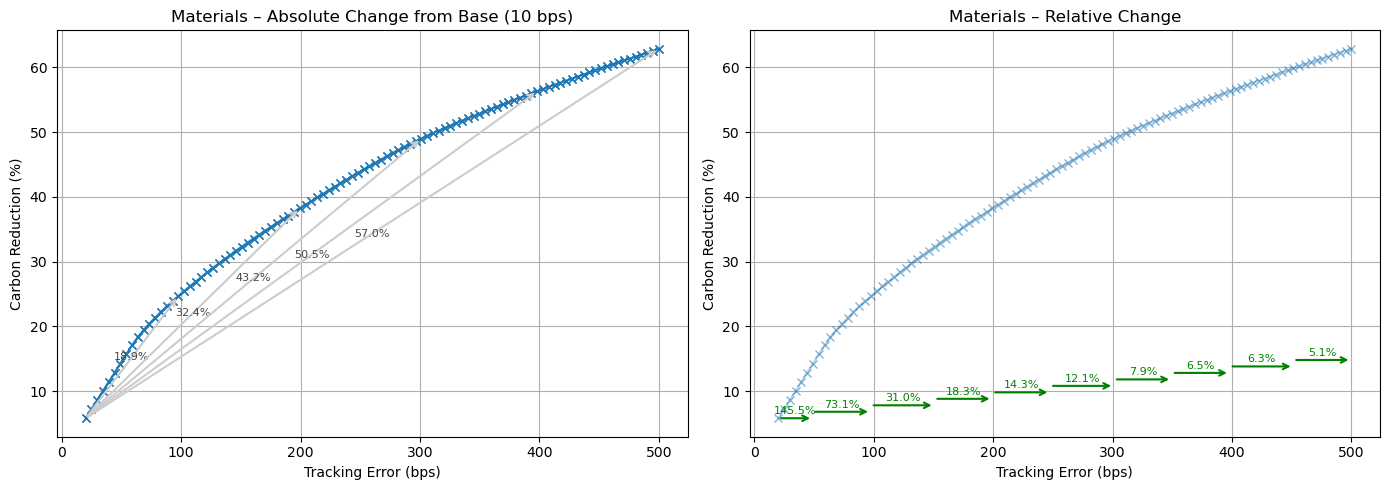

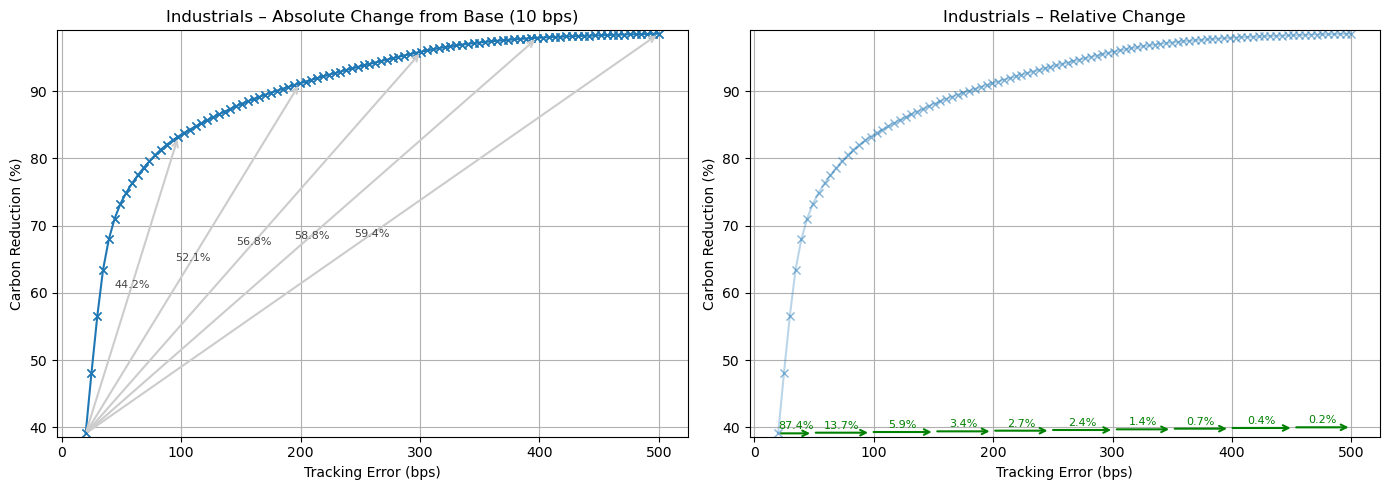

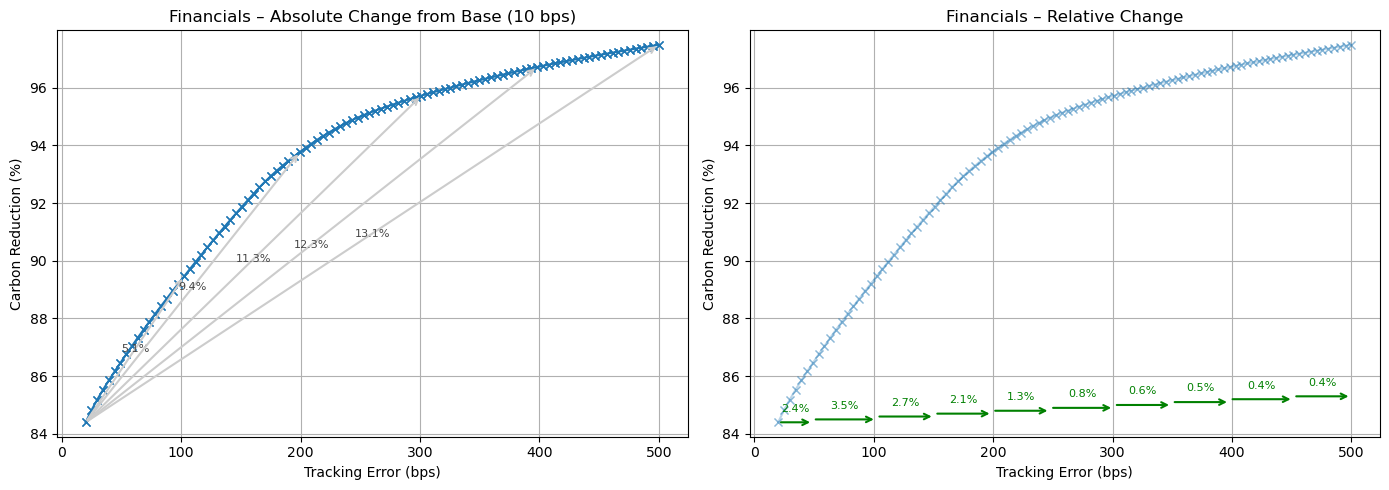

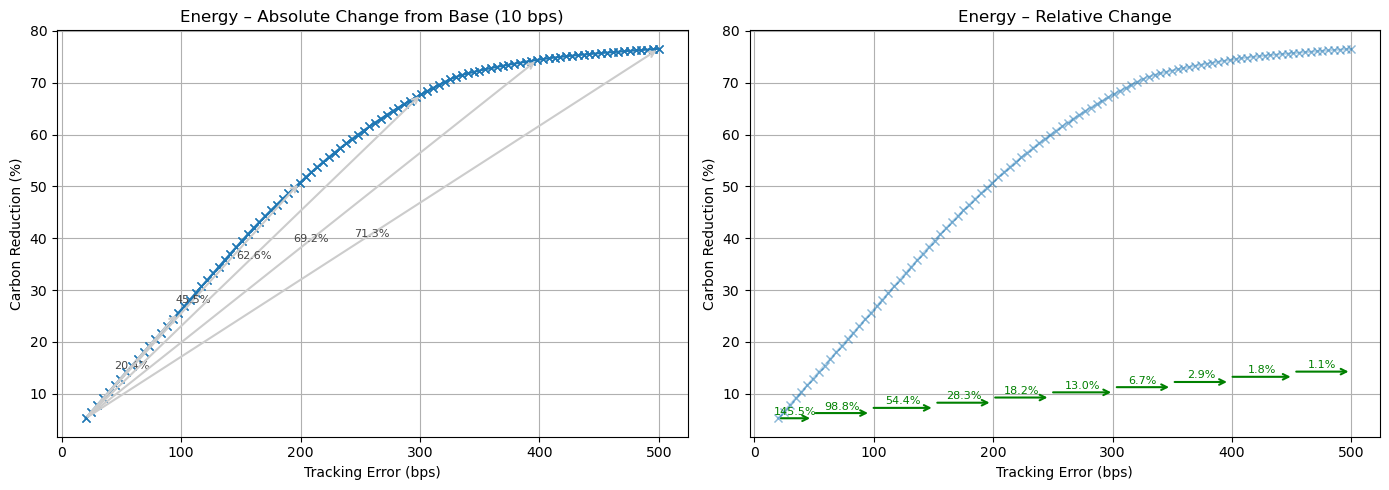

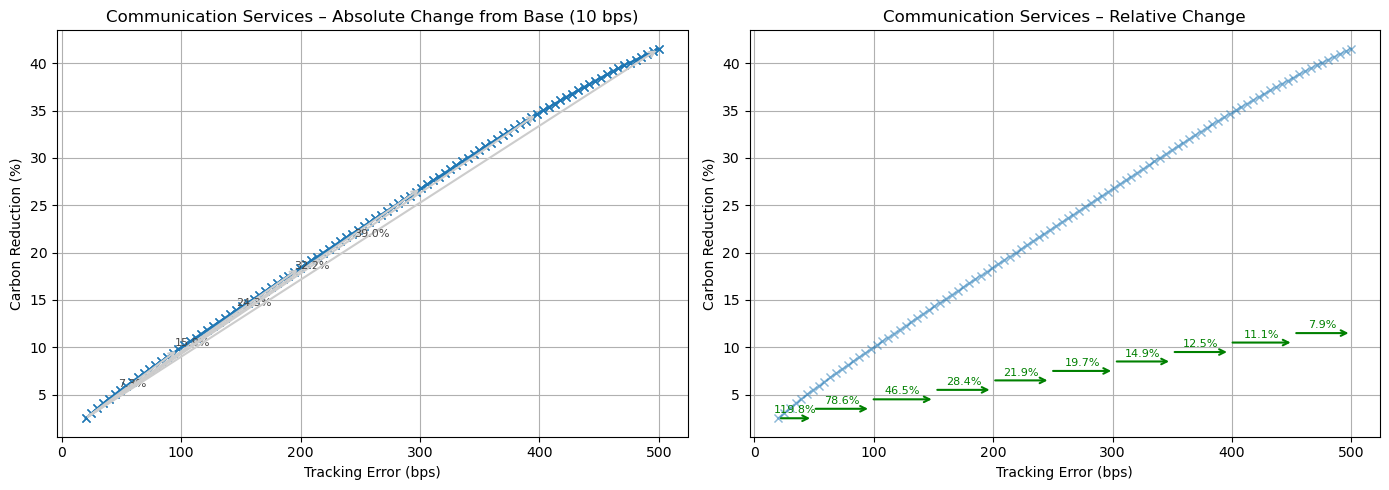

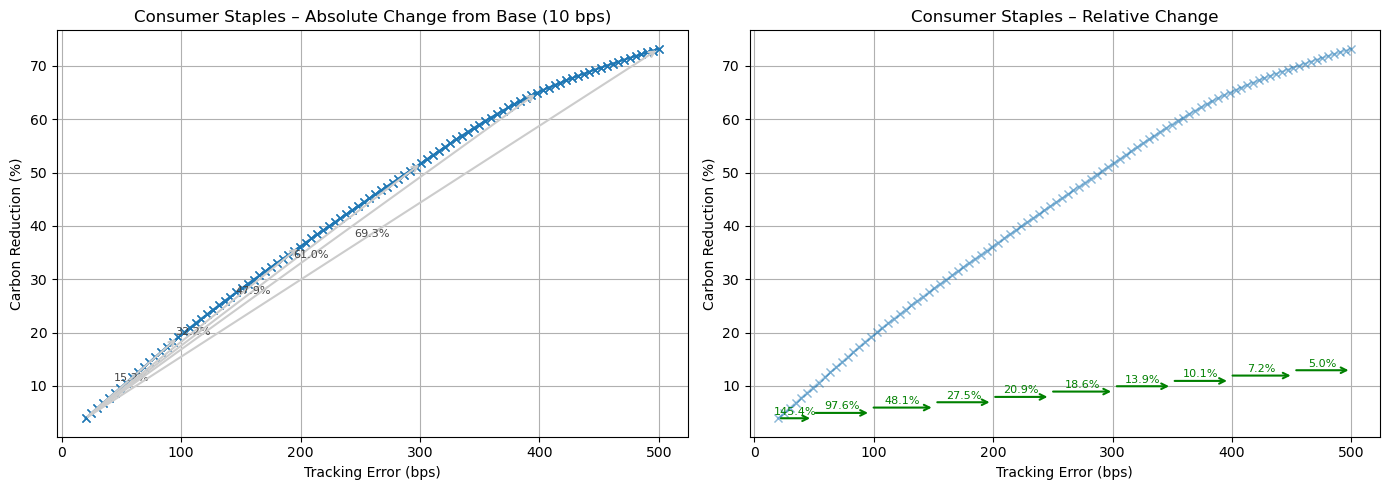

| Sector                 |   Num Features |   Num time observations |   Rank |   Min_Eigval1 |   Min_Eigval2 |   Min_Eigval3 |   Min_Eigval4 |   Min_Eigval5 | Low Rank?   | Not PSD?   |   Start Reduction (%) |   End Reduction (%) |   Gain (%) |   Reduction @2% TE (%) |   Shrinkage Alpha |
|------------------------|----------------|-------------------------|--------|---------------|---------------|---------------|---------------|---------------|-------------|------------|-----------------------|---------------------|------------|------------------------|-------------------|
| Communication Services |             23 |                      13 |     23 |   0.00576153  |   0.00576153  |   0.00576153  |   0.00576153  |   0.00576153  | False       | False      |                  2.49 |               41.54 |      39.05 |                  18.37 |             0.569 |
| Consumer Discretionary |             54 |                      13 |     54 |   0.00404902  |   0.00404902  |   0.00404902  |   0

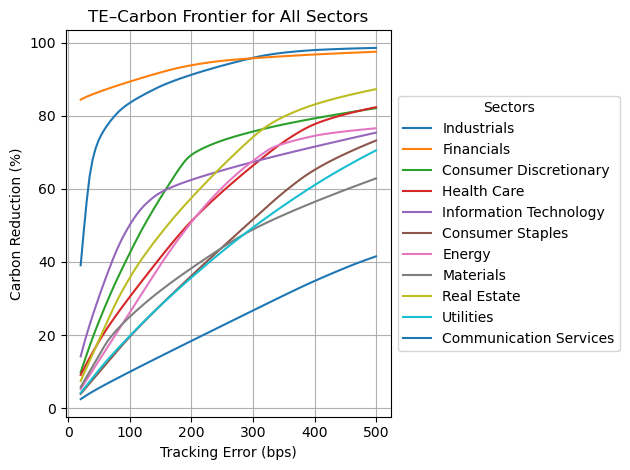

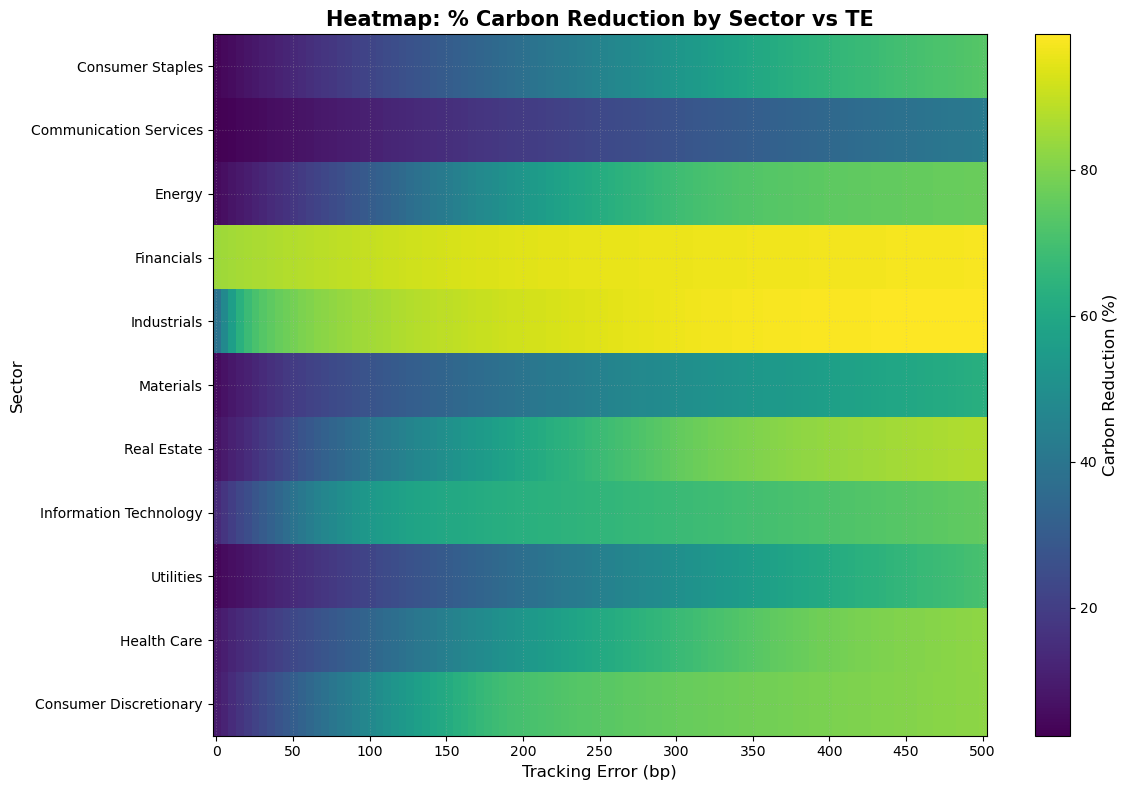

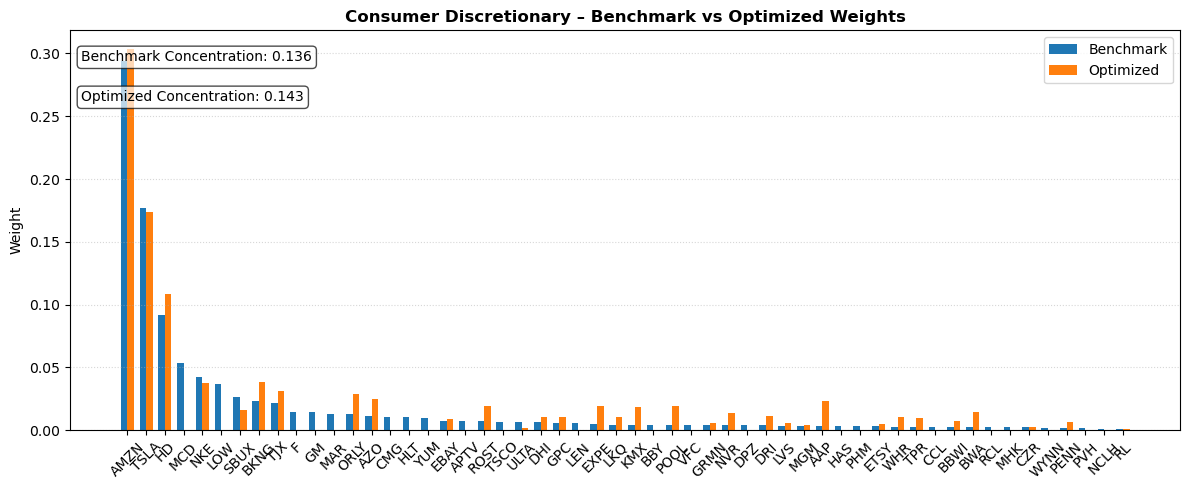

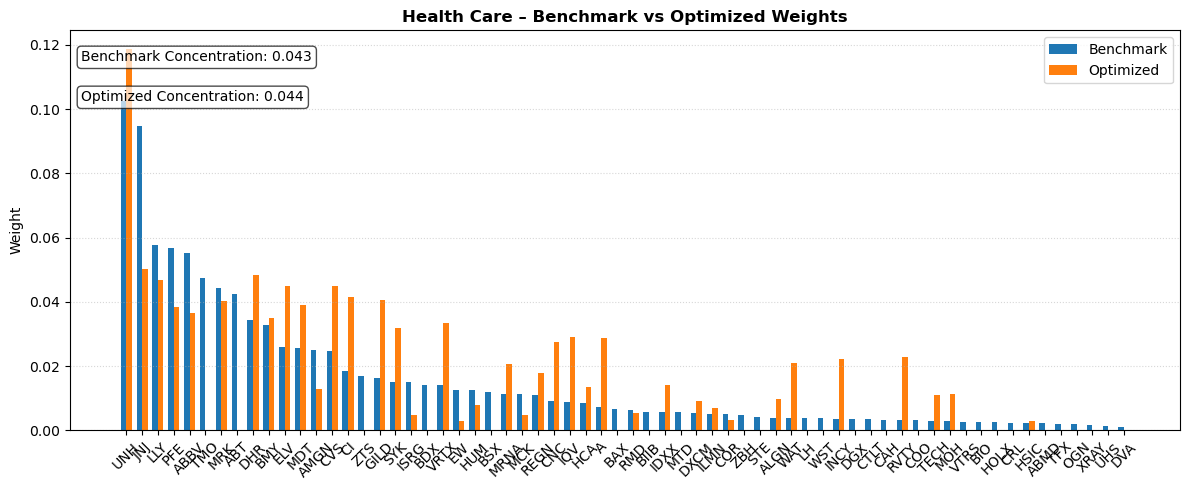

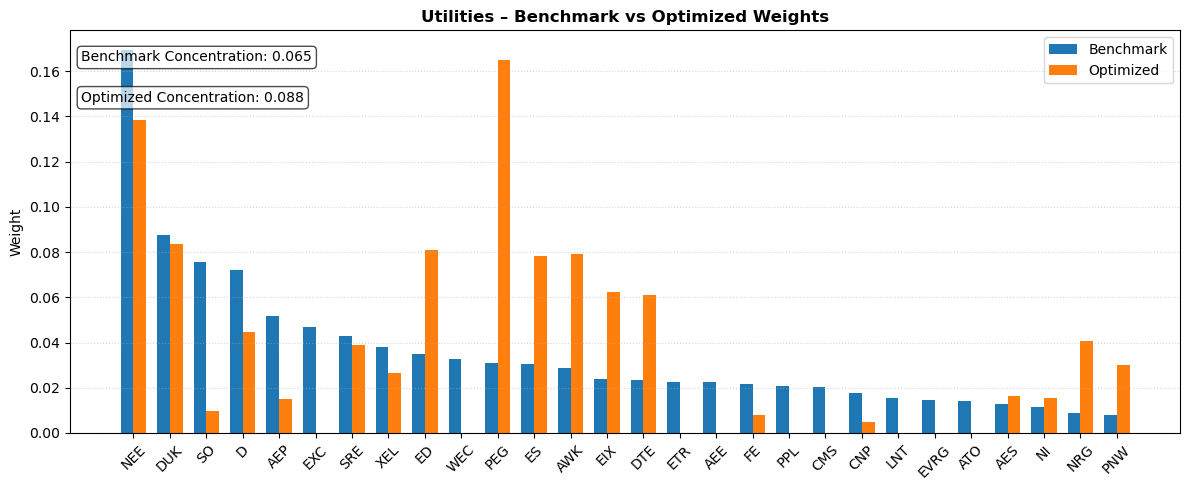

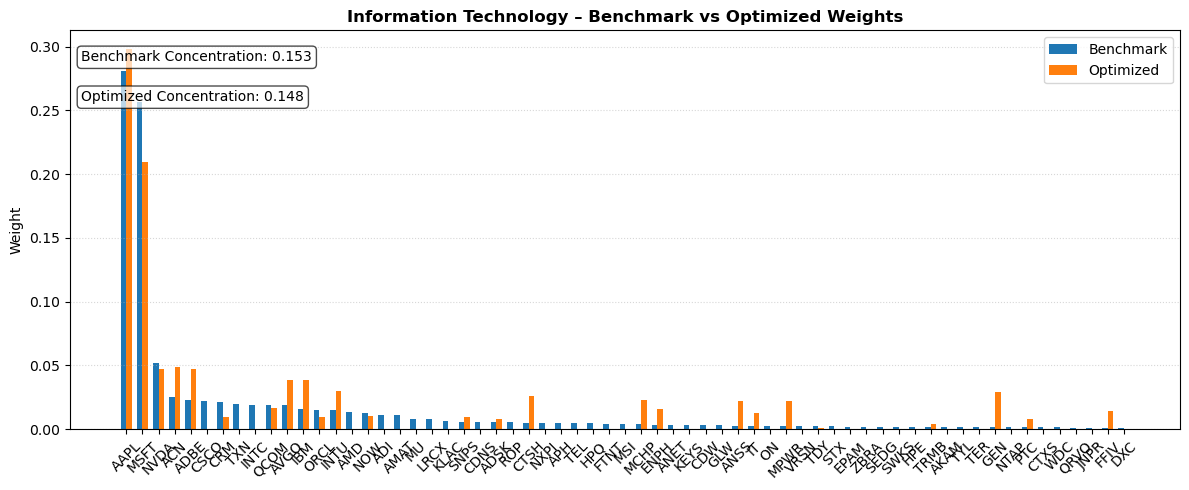

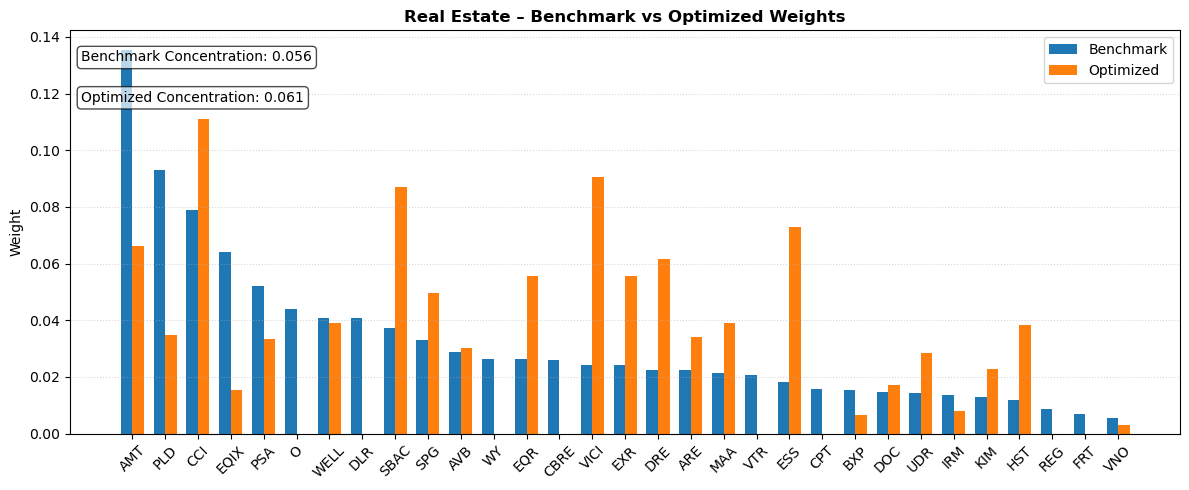

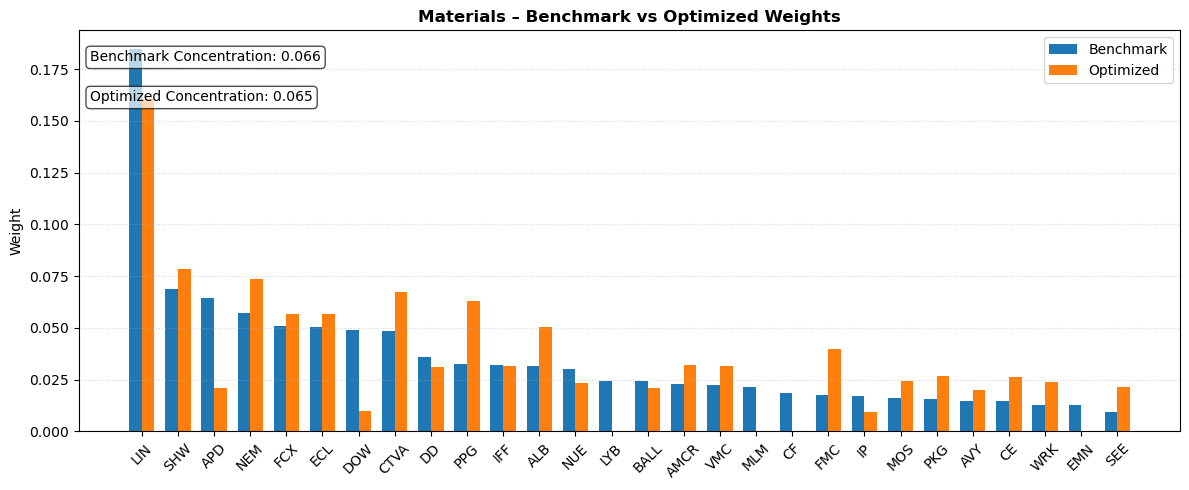

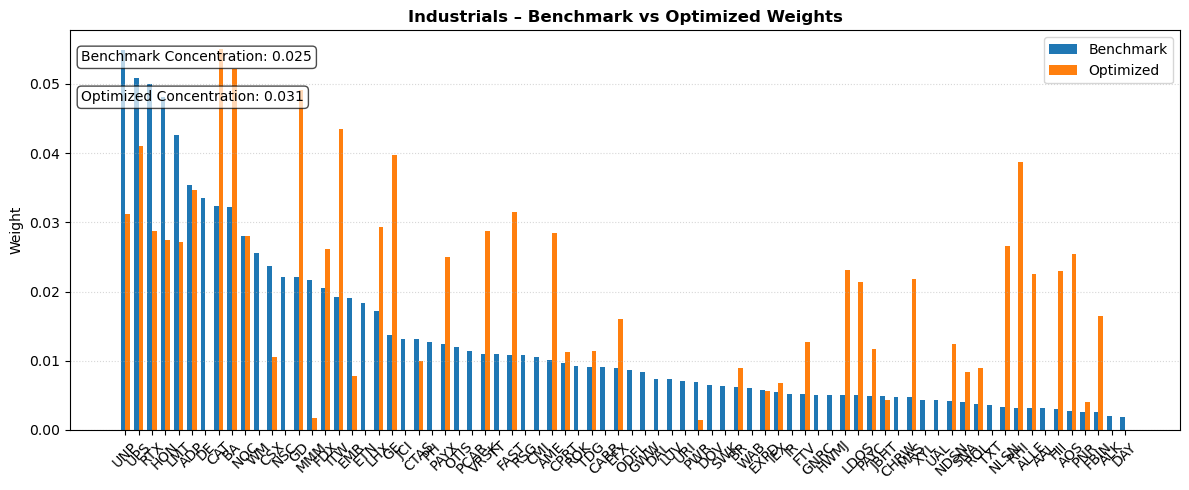

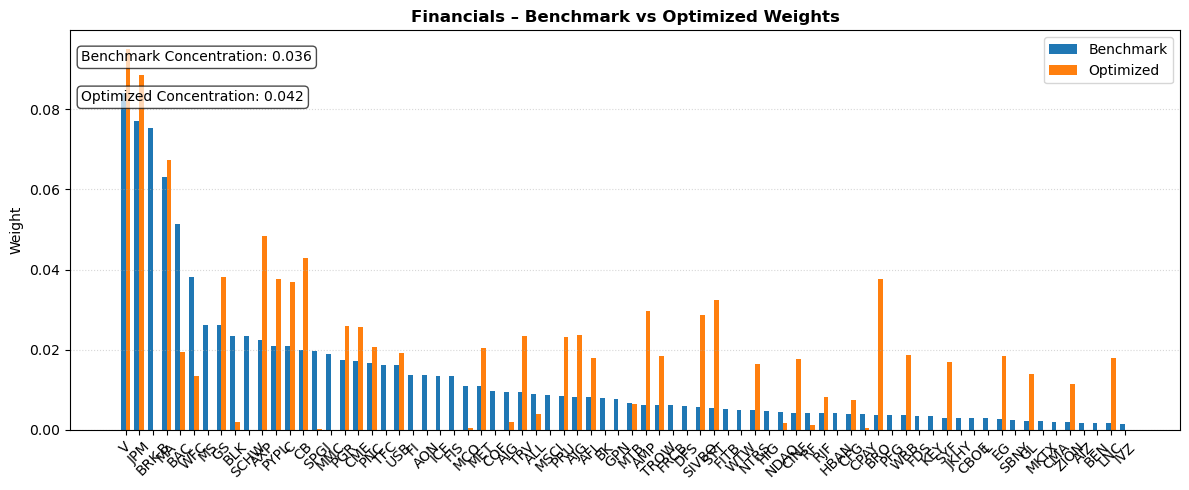

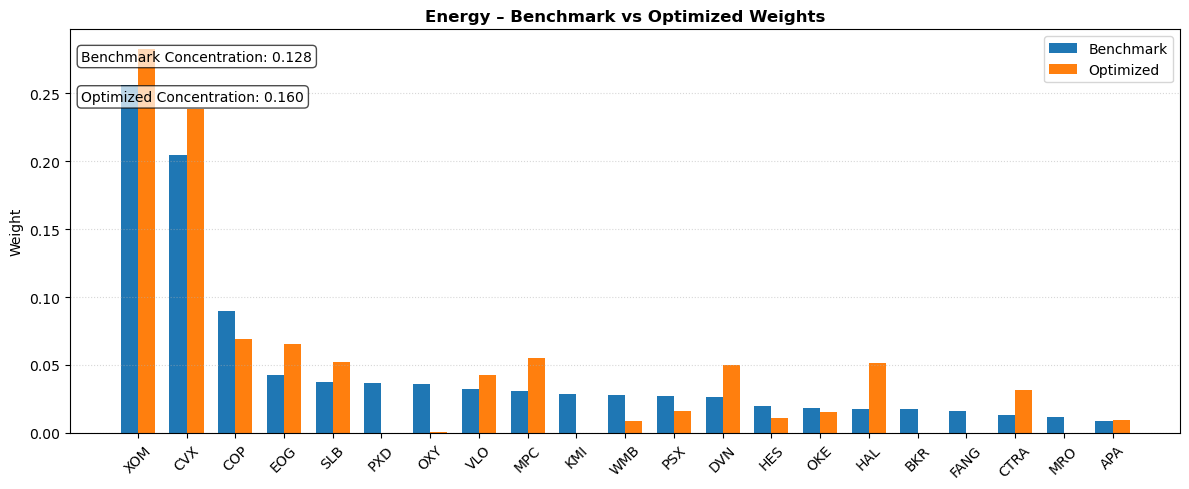

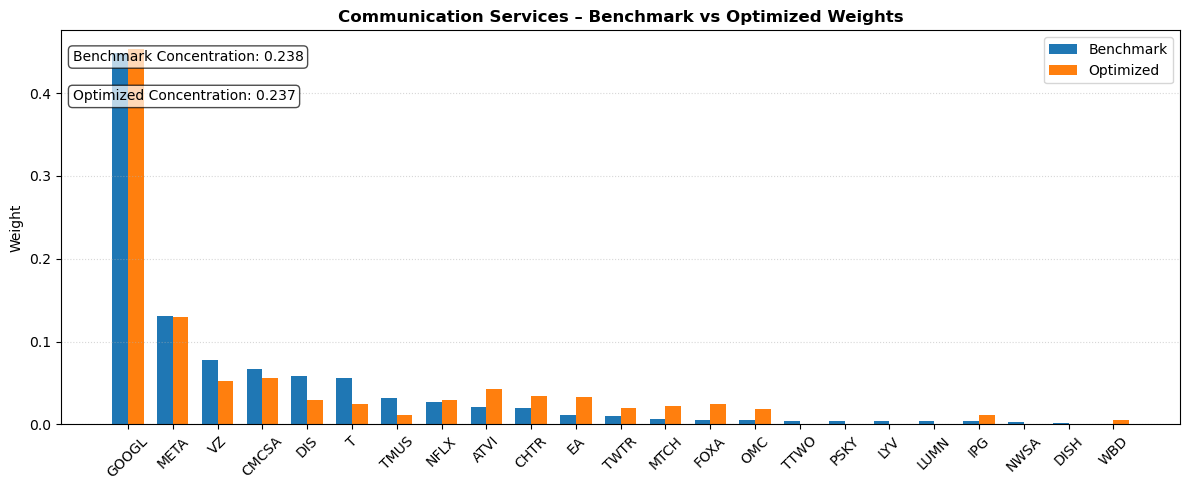

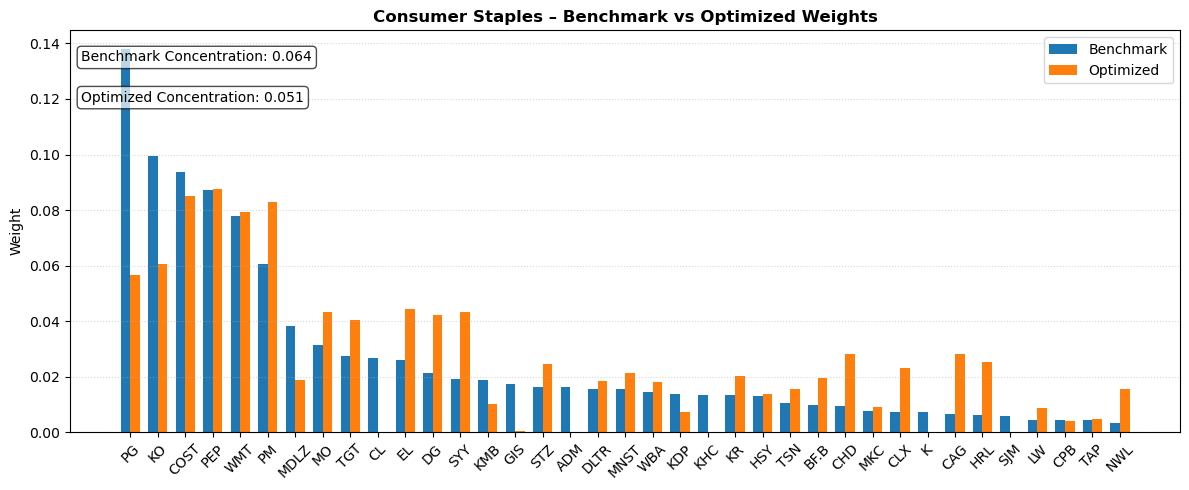

In [7]:
def compute_hhi(weights):
    return np.sum(np.square(weights))

# Load data
# Regularized Sigma (shrinkage + lambda_I + nearest PSD)
def sigma_reg_fn(R_clean):

    # Apply Ledoit-Wolf shrinkage
    lw = LedoitWolf().fit(R_clean)
    Sigma_shrink = lw.covariance_
    tolerance = 1e-4  # or 0.0001 (allows small wiggle room)

    # --- λI regularization ---
    lambda_I = 1e-5
    Sigma_reg = Sigma_shrink + lambda_I * np.eye(Sigma_shrink.shape[0])
    return Sigma_reg, lw.shrinkage_

def nearest_psd(A):
    eigvals, eigvecs = np.linalg.eigh(A)
    eigvals[eigvals < 0] = 0  # clip negative eigenvalues
    return eigvecs @ np.diag(eigvals) @ eigvecs.T

data = pd.read_excel("Data/out-of-sample/dataset_comp_0622.xlsx")

sector_weights = {} 
optimal_portfolios_shrink = {}
diagnostics = []
reductions = []
for sector_name in data['GICS Sector'].unique():
    sector_weights[sector_name] = {
    'weights_by_te': [],
    'tracking_errors': [],
    'carbon_reductions': [],
    'relative_deltas': [],
    }
    sector = data.loc[data['GICS Sector'] == sector_name]

    w_b_sector = sector[['weight_in_sector']]
    assert np.isclose(w_b_sector.sum().values[0], 1.0), f"{sector_name}: weights don't sum to 1"

    c_sector = sector[['Carbon Intensity']]
    assert c_sector.isna().sum().values[0] == 0, f"{sector_name}: carbon data has NaNs"
    R = pd.read_excel("Data/out-of-sample/sector_log_returns_comp_0622.xlsx", sheet_name=sector_name)
    
    # Drop the 'Date' column — keep only numeric log returns
    R_numeric = R.drop(columns=['Date'])
    R_clean = R_numeric.dropna()
    stock_labels = R_clean.columns
    # Asserting that the sector order between log returns matrix and df is the same
    assert (sector['SYMBOL'].values == stock_labels).all()
    Sigma_sector, shrinkage_alpha = sigma_reg_fn(R_clean)
  
    Sigma_sector = nearest_psd(Sigma_sector)

    eigvals = np.linalg.eigvalsh(Sigma_sector)
    rank = np.linalg.matrix_rank(Sigma_sector)
    num_features = Sigma_sector.shape[1]
   
    # Prepare optimization inputs
    N = len(w_b_sector)
    w_b_vec = w_b_sector.values.flatten()
    c_vec = c_sector.values.flatten()

    te_caps_annual = np.linspace(0.002, 0.05, 100)
    tracking_errors = []
    carbon_reductions = []
    smallest_eigs = np.sort(eigvals)[:5]


 
    for te_annual in te_caps_annual:
        te_cap_var_monthly = (te_annual / np.sqrt(12)) ** 2

        w = cp.Variable(N)
        tracking_error = cp.quad_form(w - w_b_vec, cp.psd_wrap(Sigma_sector))
        constraints = [tracking_error <= te_cap_var_monthly, cp.sum(w) == 1, w >= 0]
        objective = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.ECOS, verbose=False)

        if prob.status in ["optimal", "optimal_inaccurate"] and w.value is not None:
            w_opt = w.value
            diff = w_opt - w_b_vec
            te_real = np.sqrt(diff.T @ Sigma_sector @ diff) * np.sqrt(12)
            carbon_b = w_b_vec @ c_vec
            carbon_opt = w_opt @ c_vec
            reduction_pct = (carbon_b - carbon_opt) / carbon_b * 100

            tracking_errors.append(te_real * 10000)
            carbon_reductions.append(reduction_pct)
        else:
            print(f"{sector_name}: Optimization failed at TE cap {te_annual:.3%}")
        w_opt = w.value
        if w_opt is not None:
            # Ex-post tracking error (annualized)
            diff = w_opt - w_b_vec
            te_real = np.sqrt(diff.T @ Sigma_sector @ diff) * np.sqrt(12)
            tracking_errors.append(te_real * 10000)  # in bps

            # Carbon reduction
            carbon_b = w_b_vec @ c_vec
            carbon_opt = w_opt @ c_vec
            reduction_pct = (carbon_b - carbon_opt) / carbon_b * 100
            carbon_reductions.append(reduction_pct)
            sector_weights[sector_name]['weights_by_te'].append(w_opt)
            sector_weights[sector_name]['tracking_errors'].append(te_real * 10000)
            sector_weights[sector_name]['carbon_reductions'].append(reduction_pct)

        
        cov_sector = pd.read_excel("Data/out-of-sample/sector_cov_matrices_comp_0622.xlsx", sheet_name=sector_name)



        if np.round(te_annual, 3) == 0.02:
            # Carbon reduction
            carbon_b = w_b_vec @ c_vec
            carbon_opt = w_opt @ c_vec
            reduction_pct = (carbon_b - carbon_opt) / carbon_b * 100
           
            optimal_portfolios_shrink[sector_name] = {
            "w_b_vec": w_b_vec,
            "w_opt": w_opt,
            "stock_labels": stock_labels,
            "% carbon reduction": reduction_pct,
            "hhi_benchmark_portfolio" : compute_hhi(w_b_vec),
            "hhi_optimised_portfolio" : compute_hhi(w_opt) } 
            # w_b_vec is the benchmark weights vector
            # w_opt is the optimised weights vector
            # stock labels is the companies name
            benchmark_df =  pd.DataFrame({"w": w_b_vec, "symbol": stock_labels})
            optimised_df = pd.DataFrame({"w": w_opt, "symbol": stock_labels})
            benchmark_df.sort_values(by = 'w', ascending=False, inplace=True)
            optimised_df.sort_values(by = 'w', ascending=False, inplace=True)

            # Count if the leading asset by portfolio weight in the optimized allocation aligns with that of the benchmark portfolio.
            optimal_portfolios_shrink[sector_name].update({'count_1' : 1 if benchmark_df['symbol'].values[0] == optimised_df['symbol'].values[0] else 0})
            # Count how many assets coincide by comparing the three assets with the highest weight in the optimized allocation coincide with the top three weighted consitutents of the benchmark portfolio.
            optimal_portfolios_shrink[sector_name].update({'count_3' : len(set(benchmark_df['symbol'].values[:3]).intersection(set(optimised_df['symbol'].values[:3])))})
            # Count how many assets coincide by comparing the five assets with the highest weight in the optimized allocation coincide with the top five weighted consitutents of the benchmark portfolio.
            optimal_portfolios_shrink[sector_name].update({'count_5' : len(set(benchmark_df['symbol'].values[:5]).intersection(set(optimised_df['symbol'].values[:5])))})
            # Count how many assets coincide by comparing the ten assets with the highest weight in the optimized allocation coincide with the top ten weighted consitutents of the benchmark portfolio.
            optimal_portfolios_shrink[sector_name].update({'count_10' : len(set(benchmark_df['symbol'].values[:10]).intersection(set(optimised_df['symbol'].values[:10])))})

            # Count stocks with non-zero weights in the optimised portfolio:
           
            optimal_portfolios_shrink[sector_name].update({'zero_stocks': len(optimised_df.loc[optimised_df['w'] < 1e-04])})
            optimal_portfolios_shrink[sector_name].update({'zero_stocks_%': len(optimised_df.loc[optimised_df['w'] < 1e-04])/len(optimised_df)})

    # Define the tracking error breakpoints (in bps)
    absolute_te_points = [100, 200, 300, 400, 500]
    relative_te_points = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500]

    tracking_errors_np = np.array(tracking_errors)
    carbon_reductions_np = np.array(carbon_reductions)
    # === Carbon Summary Diagnostics ===
    if len(carbon_reductions_np) > 0:
        start_reduction = carbon_reductions_np[0]
        end_reduction = carbon_reductions_np[-1]
        total_gain = end_reduction - start_reduction

        idx_2pct = np.argmin(np.abs(tracking_errors_np - 200))  # ~2% TE = 200bps
        reduction_at_2pct = carbon_reductions_np[idx_2pct]
       
        diagnostics.append({
            "Sector": sector_name,
            "Num Features": num_features,
            "Num time observations": R_clean.shape[0], 
            "Rank": rank,
            "Min_Eigval1": smallest_eigs[0],
            "Min_Eigval2": smallest_eigs[1] if len(smallest_eigs) > 1 else np.nan,
            "Min_Eigval3": smallest_eigs[2] if len(smallest_eigs) > 2 else np.nan,
            "Min_Eigval4": smallest_eigs[3] if len(smallest_eigs) > 3 else np.nan,
            "Min_Eigval5": smallest_eigs[4] if len(smallest_eigs) > 4 else np.nan,
            "Low Rank?": rank < num_features,
            "Not PSD?": eigvals.min() < -1e-6,
            "Start Reduction (%)": round(start_reduction, 2),
            "End Reduction (%)": round(end_reduction, 2),
            "Gain (%)": round(total_gain, 2),
            "Reduction @2% TE (%)": round(reduction_at_2pct, 2),
            "Shrinkage Alpha": round(shrinkage_alpha, 3)
    
        })
        reductions.append({
            "Sector": sector_name,
            "Start Reduction (%)": round(start_reduction, 2),
            "End Reduction (%)": round(end_reduction, 2),
            "Gain (%)": round(total_gain, 2),
            "Reduction @2% TE (%)": round(reduction_at_2pct, 2)})
    plot_te_carbon_by_sector(tracking_errors=tracking_errors, carbon_reductions=carbon_reductions, tracking_errors_np=tracking_errors_np, absolute_te_points=absolute_te_points, sector_name=sector_name, sector_weights=sector_weights, relative_te_points=relative_te_points)

diagnostics_df = pd.DataFrame(diagnostics)
diagnostics_df = diagnostics_df.sort_values("Sector")  # optional
print(tabulate(diagnostics_df, headers='keys', tablefmt='github', showindex=False))
print()
# reductions_df = pd.DataFrame(reductions)
# print(reductions_raw_df)
# print()
# print(reductions_df)
# print()
# # Ensure the DataFrames are aligned on the 'Sector' column
# if "Sector" in reductions_raw_df.columns:
#     reductions_raw_df = reductions_raw_df.set_index("Sector")
# reductions_df = reductions_df.set_index("Sector")

# # Compute the difference: (after shrinkage) - (before shrinkage)
# delta_df = reductions_df - reductions_raw_df

# # Optional: Reset index to make 'Sector' a column again
# delta_df = delta_df.reset_index()

# # Rename columns to indicate they are deltas
# delta_df.columns = ["Sector"] + [f"Δ {col}" for col in reductions_df.columns]
# for col in delta_df.columns[1:]:
#     delta_df.sort_values(col, inplace=True, ascending= False, key= abs)
#     print(tabulate(delta_df, headers='keys', tablefmt='github', showindex=False))

# # Custom sector order
# ordered_sectors = [
#     "Industrials",
#     "Financials",
#     "Consumer Discretionary",
#     "Health Care",
#     "Information Technology",
#     "Consumer Staples",
#     "Energy",
#     "Materials",
#     "Real Estate",
#     "Utilities",
#     "Communication Services"
# ]

# plt.figure(figsize=(12, 6))  # Wider figure helps with spacing

for sector_name in ordered_sectors:
    if sector_name in sector_weights:
        metrics = sector_weights[sector_name]
        plt.plot(metrics['tracking_errors'], metrics['carbon_reductions'], label=sector_name)

plt.xlabel('Tracking Error (bps)')
plt.ylabel('Carbon Reduction (%)')
plt.title('TE–Carbon Frontier for All Sectors')

# Legend outside right
plt.legend(title="Sectors", loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.grid(True)
plt.tight_layout()  # Adjust layout to fit legend
plt.show()

plot_te_carbon_heatmap(sector_weights=sector_weights, te_caps_annual=te_caps_annual)
for sector_name, data in optimal_portfolios_shrink.items():
    plot_origin_vs_opt_weights_comparison(
        data["w_b_vec"],
        data["w_opt"],
        data["stock_labels"],
        sector_name=sector_name,
        weight_comp_bool=True
    )

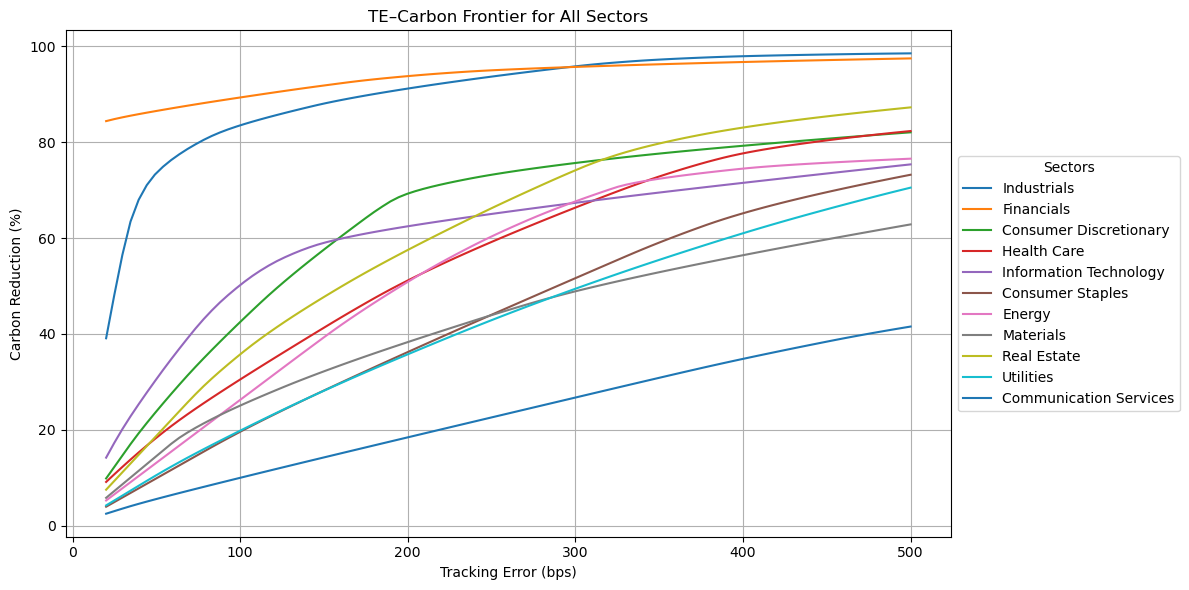

In [8]:
plt.figure(figsize=(12, 6))  # width=12, height=6 (adjust as needed)

for sector_name in ordered_sectors:
    if sector_name in sector_weights:
        metrics = sector_weights[sector_name]
        plt.plot(metrics['tracking_errors'], metrics['carbon_reductions'], label=sector_name)

plt.xlabel('Tracking Error (bps)')
plt.ylabel('Carbon Reduction (%)')
plt.title('TE–Carbon Frontier for All Sectors')

# Legend outside right
plt.legend(title="Sectors", loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()


                    Sector  Slope_at_2pct  Rstar_at_2pct
9   Communication Services           8.34          18.42
0   Consumer Discretionary          13.76          69.03
10        Consumer Staples          15.78          36.22
8                   Energy          21.21          50.83
7               Financials           3.10          93.78
1              Health Care          17.66          51.12
6              Industrials           5.48          91.18
3   Information Technology           5.66          62.45
5                Materials          11.61          38.29
4              Real Estate          18.23          57.50
2                Utilities          14.68          35.74


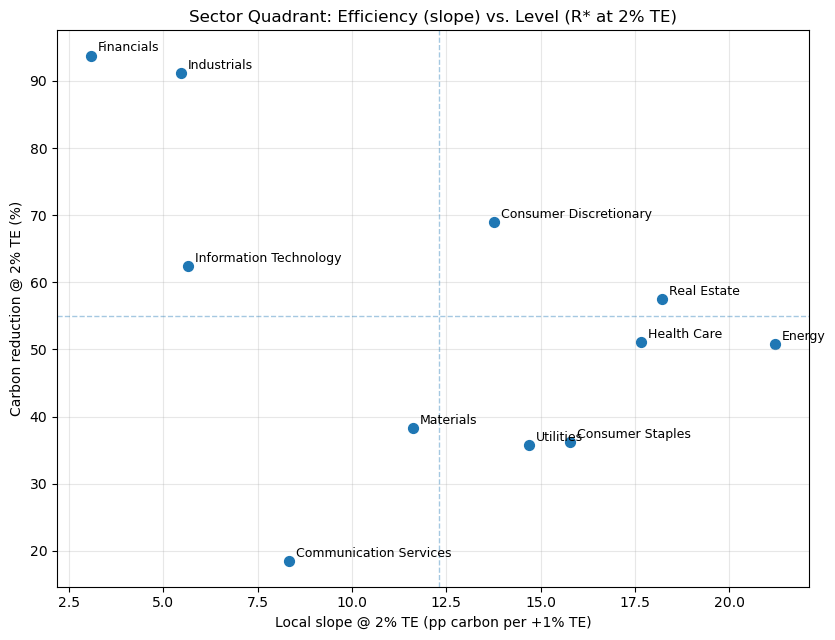

In [9]:
# --- Quadrant plot: local slope at 2% TE vs. carbon reduction level at 2% TE ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TARGET_TE_BPS = 200    # 2% TE
K_NEIGHBORS    = 7     # use up to 7 closest TE points for the local fit (min 3)

def _local_slope_at_target(te_bps, red_pct, target_bps=200, k=7):
    """
    te_bps: array-like of TE in basis points (e.g., [10, 20, ..., 500])
    red_pct: array-like of carbon reduction in percent (e.g., [12.3, 13.1, ...])
    Returns (slope_pp_per_pctTE, Rstar_pct) where:
      slope units = percentage-point carbon per +1% TE  (pp / %TE)
      Rstar_pct   = carbon reduction (%) at target TE (via local linear fit)
    """
    te_bps = np.asarray(te_bps, float)
    red_pct = np.asarray(red_pct, float)

    # guard: need at least 3 points
    if len(te_bps) < 3:
        return np.nan, np.nan

    # choose k nearest points to target_bps
    order = np.argsort(np.abs(te_bps - target_bps))
    idx = order[:max(3, min(k, len(te_bps)))]
    X_te_pct = te_bps[idx] / 100.0  # convert bps -> % TE
    y = red_pct[idx]

    # robust linear fit y = a + b * TE(%)
    X = np.c_[np.ones(len(idx)), X_te_pct]
    a, b = np.linalg.lstsq(X, y, rcond=None)[0]
    Rstar = a + b * (target_bps / 100.0)
    slope = b
    return float(slope), float(Rstar)

# Build metrics table from your sector_weights dict
rows = []
for sector_name, metrics in sector_weights.items():
    te_bps = np.asarray(metrics['tracking_errors'], float)    # bps
    red_pct = np.asarray(metrics['carbon_reductions'], float) # %

    # Deduplicate any accidental duplicates (optional but helpful)
    df_tmp = pd.DataFrame({'te_bps': te_bps, 'red_pct': red_pct}) \
               .sort_values('te_bps') \
               .drop_duplicates(subset='te_bps', keep='last')

    slope, Rstar = _local_slope_at_target(
        df_tmp['te_bps'].values,
        df_tmp['red_pct'].values,
        target_bps=TARGET_TE_BPS,
        k=K_NEIGHBORS
    )
    rows.append({
        'Sector': sector_name,
        'Slope_at_2pct': slope,         # pp carbon per +1% TE
        'Rstar_at_2pct': Rstar          # % carbon reduction at 2% TE
    })

quad_df = pd.DataFrame(rows).sort_values('Sector')
print(quad_df.round(3))

# --- Quadrant scatter ---
fig, ax = plt.subplots(figsize=(8.5, 6.5))

x = quad_df['Slope_at_2pct'].values
y = quad_df['Rstar_at_2pct'].values
labels = quad_df['Sector'].values

ax.scatter(x, y, s=50)

# label points
for xi, yi, lab in zip(x, y, labels):
    if np.isfinite(xi) and np.isfinite(yi):
        ax.annotate(lab, (xi, yi), xytext=(5, 3), textcoords='offset points', fontsize=9)

# reference lines: medians (use np.nanmedian to ignore NaNs)
vx = float(np.nanmean(x))
hy = float(np.nanmean(y))
ax.axvline(vx, linestyle='--', linewidth=1, alpha=0.4)
ax.axhline(hy, linestyle='--', linewidth=1, alpha=0.4)

ax.set_xlabel('Local slope @ 2% TE (pp carbon per +1% TE)')
ax.set_ylabel('Carbon reduction @ 2% TE (%)')
ax.set_title('Sector Quadrant: Efficiency (slope) vs. Level (R* at 2% TE)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [10]:

with open('Data/out-of-sample/optimal_portfolios_0622.pkl', 'wb') as f:
    pickle.dump(optimal_portfolios_shrink, f)

No big changes:
Real Estate, Materials, Energy, Financials, Communication Services (not a big change but smoother elbow), Consumer Staples not extreme big changes

Biggest changes:
Consumer Discretionary, Health Care, Utilities, Inf. tech, Industrials (very big change)

In [11]:

with open('Data/out-of-sample/optimal_portfolios_0622.pkl', 'rb') as f:
    optimal_portfolios_shrink = pickle.load(f)

Wide ε-bands = “flat” constraint face → many near-optimal portfolios.

Narrow ε-bands = “pointy” optimum → unique solution.

In [12]:
import numpy as np
import pandas as pd
import cvxpy as cp

# --- knobs (once) ---
eps = 0.02                      # ε for near-optimal bands (≥(1-ε)*R*)
delta_R  = 1e-3                 # same-objective tolerance around R*
delta_TE = 1e-8                 # tiny TE slack to avoid boundary pinning
K_dirs   = 500                  # random directions for L2 lower bound
NO_IMPROVE_PATIENCE = 40        # early-stop if no improvement
ZERO_TOL = 1e-10

ECOS_OPTS = dict(abstol=1e-9, reltol=1e-9, feastol=1e-9, verbose=False)
USE_SCS_FALLBACK = True
SCS_OPTS  = dict(eps=5e-5, max_iters=8000, verbose=False, acceleration_lookback=20)

# containers
sector_bands = {}
sector_summary_rows = []

def sigma_reg_fn(R_clean):

    # Apply Ledoit-Wolf shrinkage
    lw = LedoitWolf().fit(R_clean)
    Sigma_shrink = lw.covariance_
    tolerance = 1e-4  # or 0.0001 (allows small wiggle room)

    # --- λI regularization ---
    lambda_I = 1e-5
    Sigma_reg = Sigma_shrink + lambda_I * np.eye(Sigma_shrink.shape[0])
    return Sigma_reg, lw.shrinkage_

def nearest_psd(A):
    eigvals, eigvecs = np.linalg.eigh(A)
    eigvals[eigvals < 0] = 0  # clip negative eigenvalues
    return eigvecs @ np.diag(eigvals) @ eigvecs.T

data = pd.read_excel("Data/out-of-sample/dataset_comp_0622.xlsx")

# === main loop ===
for sector_name, info in optimal_portfolios_shrink.items():
    w_b_vec = info["w_b_vec"].astype(float).ravel()
    w_opt   = info["w_opt"].astype(float).ravel()
    stock_labels = list(info["stock_labels"])

    # covariance for this sector
    R = pd.read_excel("Data/out-of-sample/sector_log_returns_comp_0622.xlsx", sheet_name=sector_name)
    R_clean = R.drop(columns=['Date']).dropna()
    Sigma_sector, _ = sigma_reg_fn(R_clean)
    Sigma_sector = nearest_psd(Sigma_sector)

    # carbon vector
    c_vec = data.loc[data['GICS Sector'] == sector_name, ['Carbon Intensity']].values.flatten().astype(float)

    # baseline / optimal reduction
    c_b   = float(w_b_vec @ c_vec)
    c_opt = float(w_opt   @ c_vec)
    R_star = (c_b - c_opt) / c_b

    # TE cap (2% annual)
    te_annual = 0.02
    te_var_monthly_cap = (te_annual / np.sqrt(12))**2

    N = len(w_b_vec)

    # -------------------------------
    # A) ε-bands (quad_form + ECOS)
    # -------------------------------
    def eps_constraints(w):
        return [
            cp.quad_form(w - w_b_vec, cp.psd_wrap(Sigma_sector)) <= te_var_monthly_cap,
            cp.sum(w) == 1,
            w >= 0,
            (c_b - c_vec @ w) / c_b >= (1 - eps) * R_star
        ]

    bands = []
    for i, name in enumerate(stock_labels):
        # Max w_i
        w = cp.Variable(N)
        prob_max = cp.Problem(cp.Maximize(w[i]), eps_constraints(w))
        prob_max.solve(solver=cp.ECOS, **ECOS_OPTS)
        if (w.value is None or prob_max.status not in ("optimal", "optimal_inaccurate")) and USE_SCS_FALLBACK:
            prob_max.solve(solver=cp.SCS, **SCS_OPTS)
        w_max = w.value[i] if w.value is not None else np.nan

        # Min w_i
        w = cp.Variable(N)
        prob_min = cp.Problem(cp.Minimize(w[i]), eps_constraints(w))
        prob_min.solve(solver=cp.ECOS, **ECOS_OPTS)
        if (w.value is None or prob_min.status not in ("optimal", "optimal_inaccurate")) and USE_SCS_FALLBACK:
            prob_min.solve(solver=cp.SCS, **SCS_OPTS)
        w_min = w.value[i] if w.value is not None else np.nan

        # hygiene
        if (not np.isfinite(w_min)) or (w_min < ZERO_TOL): w_min = 0.0
        if (not np.isfinite(w_max)) or (w_max < ZERO_TOL): w_max = 0.0
        w_min = float(min(max(w_min, 0.0), 1.0))
        w_max = float(min(max(w_max, 0.0), 1.0))

        bands.append([name, w_min, w_max, w_max - w_min])

    bands_df = pd.DataFrame(bands, columns=["symbol", "w_min", "w_max", "bandwidth"]).sort_values("bandwidth", ascending=False)
    sector_bands[sector_name] = bands_df

    # quick ε-band stats
    avg_bw = float(bands_df["bandwidth"].mean())
    med_bw = float(bands_df["bandwidth"].median())
    max_bw = float(bands_df["bandwidth"].max())
    pct_wmin_zero = float((bands_df["w_min"] <= ZERO_TOL).mean()) * 100.0

    print(f"\n=== ε-bands for {sector_name} (≥{(1-eps):.0%} of optimal carbon, TE≤2%) ===")
    print(bands_df.head(10).round(4))

    # ---------------------------------------------------------
    # B) L2 lower bound at SAME objective (quad_form + ECOS)
    #     — with three minimal tweaks —
    # ---------------------------------------------------------
    w = cp.Variable(N)
    v = cp.Parameter(N)  # direction parameter (avoids re-canonization)

    constraints_same_obj = [
        cp.quad_form(w - w_b_vec, cp.psd_wrap(Sigma_sector)) <= te_var_monthly_cap + delta_TE,
        cp.sum(w) == 1,
        w >= 0,
        ((c_b - c_vec @ w) / c_b) >= R_star - delta_R,
        ((c_b - c_vec @ w) / c_b) <= R_star + delta_R
    ]
    prob_dir = cp.Problem(cp.Maximize(v @ w), constraints_same_obj)

    rng = np.random.default_rng(42)
    best_lb = 0.0
    stale = 0

    for it in range(K_dirs):
        vv = rng.standard_normal(N)
        nrm = np.linalg.norm(vv)
        if nrm == 0:
            continue
        vv /= nrm

        # max v^T w
        v.value = vv
        prob_dir.solve(solver=cp.ECOS, **ECOS_OPTS)
        if (w.value is None or prob_dir.status not in ("optimal", "optimal_inaccurate")) and USE_SCS_FALLBACK:
            prob_dir.solve(solver=cp.SCS, **SCS_OPTS)
        cand1 = abs(float(vv @ (w.value - w_opt))) if (w.value is not None and prob_dir.status in ("optimal","optimal_inaccurate")) else 0.0

        # max (-v)^T w  (≡ min v^T w)
        v.value = -vv
        prob_dir.solve(solver=cp.ECOS, **ECOS_OPTS)
        if (w.value is None or prob_dir.status not in ("optimal", "optimal_inaccurate")) and USE_SCS_FALLBACK:
            prob_dir.solve(solver=cp.SCS, **SCS_OPTS)
        cand2 = abs(float((-vv) @ (w.value - w_opt))) if (w.value is not None and prob_dir.status in ("optimal","optimal_inaccurate")) else 0.0

        new_best = max(best_lb, cand1, cand2)
        if new_best > best_lb + 1e-6:
            best_lb = new_best
            stale = 0
        else:
            stale += 1
            if stale >= NO_IMPROVE_PATIENCE:
                break

    # quick diagnostic on the last feasible solution
    if w.value is not None:
        R_w  = float((c_b - c_vec @ w.value) / c_b)
        TE_w = float((w.value - w_b_vec) @ Sigma_sector @ (w.value - w_b_vec))
        print(f"[{sector_name}] check R(w)-R*: {R_w - R_star:+.3e}, TE_var_gap: {TE_w - te_var_monthly_cap:+.3e}")
    if w.value is not None:
        TE_val = (w.value - w_b_vec) @ Sigma_sector @ (w.value - w_b_vec)
        TE_gap = TE_val - te_var_monthly_cap
        carbon_val = (c_b - c_vec @ w.value) / c_b
        print(f"TE gap: {TE_gap:+.2e}, carbon vs target: {carbon_val - R_star:+.2e}")

    l2_lower_bound = best_lb
    l1_turnover_upper = float(np.sqrt(N) * l2_lower_bound)
    print(f"[{sector_name}] L2 lower bound (same objective) = {l2_lower_bound:.6f} | Turnover upper bound ≤ {l1_turnover_upper:.4f}")

    # collect for final summary
    sector_summary_rows.append({
        "Sector": sector_name,
        "N": N,
        "L2_lower_bound_same_obj": l2_lower_bound,
        "Turnover_upper_bound": l1_turnover_upper,
        "Eps": eps,
        "Avg_bandwidth": avg_bw,
        "Median_bandwidth": med_bw,
        "Max_bandwidth": max_bw,
        "Pct_wmin_zero": pct_wmin_zero
    })

# === final compact summary ===
summary_df = pd.DataFrame(sector_summary_rows).sort_values(
    ["L2_lower_bound_same_obj", "Avg_bandwidth"], ascending=[False, False]
)
print("\n=== Sector Flexibility Summary (TE=2%) — quad_form + ECOS ===")
print(summary_df.round({
    "L2_lower_bound_same_obj":6,
    "Turnover_upper_bound":6,
    "Avg_bandwidth":4,
    "Median_bandwidth":4,
    "Max_bandwidth":4,
    "Pct_wmin_zero":1
}).to_string(index=False))

def rerun_L2_same_objective_for_sectors(
    sector_names,
    optimal_portfolios_shrink,
    data,
    sigma_reg_fn,
    nearest_psd,
    te_annual=0.02,
    delta_TE=1e-8,          # tiny slack on TE variance
    K_dirs=800,             # more directions for a tighter bound
    patience=60,            # early stop patience
    use_scs_fallback=True,  # SCS only if ECOS fails
    tight_band=None         # e.g., 5e-4; if set, use ±tight_band instead of equality
):
    ECOS_OPTS = dict(abstol=1e-9, reltol=1e-9, feastol=1e-9, verbose=False)
    SCS_OPTS  = dict(eps=5e-5, max_iters=10000, verbose=False, acceleration_lookback=20)

    results = []
    for sector_name in sector_names:
        info = optimal_portfolios_shrink[sector_name]
        w_b_vec = info["w_b_vec"].astype(float).ravel()
        w_opt   = info["w_opt"].astype(float).ravel()

        # Sigma, c_vec for this sector
        R = pd.read_excel("Data/out-of-sample/sector_log_returns_comp_0622.xlsx", sheet_name=sector_name)
        R_clean = R.drop(columns=['Date']).dropna()
        Sigma_sector, _ = sigma_reg_fn(R_clean)
        Sigma_sector = nearest_psd(Sigma_sector)

        c_vec = data.loc[data['GICS Sector'] == sector_name, ['Carbon Intensity']].values.flatten().astype(float)

        c_b   = float(w_b_vec @ c_vec)
        c_opt = float(w_opt   @ c_vec)
        R_star = (c_b - c_opt) / c_b

        te_var_monthly_cap = (te_annual / np.sqrt(12))**2
        N = len(w_b_vec)

        # ---- L2 with carbon equality (or tight band) ----
        w = cp.Variable(N)
        v = cp.Parameter(N)

        constr = [
            cp.quad_form(w - w_b_vec, cp.psd_wrap(Sigma_sector)) <= te_var_monthly_cap + delta_TE,
            cp.sum(w) == 1,
            w >= 0,
        ]
        if tight_band is None:
            # exact same objective
            constr += [ (c_b - c_vec @ w) / c_b == R_star ]
        else:
            # symmetric tight band around R*
            constr += [
                (c_b - c_vec @ w) / c_b >= R_star - tight_band,
                (c_b - c_vec @ w) / c_b <= R_star + tight_band,
            ]

        prob_dir = cp.Problem(cp.Maximize(v @ w), constr)

        rng = np.random.default_rng(7)
        best_lb = 0.0
        stale = 0

        for _ in range(K_dirs):
            vv = rng.standard_normal(N); nrm = np.linalg.norm(vv)
            if nrm == 0: continue
            vv /= nrm

            # max v^T w
            v.value = vv
            prob_dir.solve(solver=cp.ECOS, **ECOS_OPTS)
            if (w.value is None or prob_dir.status not in ("optimal","optimal_inaccurate")) and use_scs_fallback:
                prob_dir.solve(solver=cp.SCS, **SCS_OPTS)
            cand1 = abs(float(vv @ (w.value - w_opt))) if (w.value is not None and prob_dir.status in ("optimal","optimal_inaccurate")) else 0.0

            # max (-v)^T w (≡ min v^T w)
            v.value = -vv
            prob_dir.solve(solver=cp.ECOS, **ECOS_OPTS)
            if (w.value is None or prob_dir.status not in ("optimal","optimal_inaccurate")) and use_scs_fallback:
                prob_dir.solve(solver=cp.SCS, **SCS_OPTS)
            cand2 = abs(float((-vv) @ (w.value - w_opt))) if (w.value is not None and prob_dir.status in ("optimal","optimal_inaccurate")) else 0.0

            new_best = max(best_lb, cand1, cand2)
            if new_best > best_lb + 1e-6:
                best_lb = new_best
                stale = 0
            else:
                stale += 1
                if stale >= patience:
                    break

        # diagnostics on last feasible w
        feas = {}
        if w.value is not None:
            R_w  = float((c_b - c_vec @ w.value) / c_b)
            TE_w = float((w.value - w_b_vec) @ Sigma_sector @ (w.value - w_b_vec))
            feas = dict(R_gap=R_w - R_star, TE_gap=TE_w - te_var_monthly_cap)

        l2_lb = best_lb
        l1_ub = float(np.sqrt(N) * l2_lb)

        # print concise line
        band_txt = "equality" if tight_band is None else f"±{tight_band:g}"
        if feas:
            print(f"[{sector_name}] L2@same-obj ({band_txt}) = {l2_lb:.6f} | Turnover≤{l1_ub:.4f} | R_gap={feas['R_gap']:+.2e} TE_gap={feas['TE_gap']:+.2e}")
        else:
            print(f"[{sector_name}] L2@same-obj ({band_txt}) = {l2_lb:.6f} | Turnover≤{l1_ub:.4f} | (no feasible w reported)")

        results.append({
            "Sector": sector_name,
            "Mode": "equality" if tight_band is None else f"band±{tight_band}",
            "L2_lower_bound_same_obj": l2_lb,
            "Turnover_upper_bound": l1_ub,
            "R_gap": feas.get("R_gap", np.nan),
            "TE_gap": feas.get("TE_gap", np.nan),
            "N": N
        })

    return pd.DataFrame(results)

df_eq = rerun_L2_same_objective_for_sectors(
    ["Industrials", "Financials"],
    optimal_portfolios_shrink,
    data,
    sigma_reg_fn,
    nearest_psd,
    te_annual=0.02,
    delta_TE=1e-8,
    K_dirs=1200,          # a bit higher for the final pass
    patience=100,
    use_scs_fallback=True,
    tight_band=None       # <-- equality
)
print("\n== Equality results ==")
print(df_eq.round(6).to_string(index=False))
def merge_overrides(summary_df, df_override):
    for _, r in df_override.iterrows():
        m = summary_df["Sector"] == r["Sector"]
        summary_df.loc[m, "L2_lower_bound_same_obj"] = r["L2_lower_bound_same_obj"]
        summary_df.loc[m, "Turnover_upper_bound"]    = r["Turnover_upper_bound"]
        summary_df.loc[m, "SameObj_Mode"]            = r["Mode"]
        summary_df.loc[m, "R_gap"]                   = r["R_gap"]
        summary_df.loc[m, "TE_gap"]                  = r["TE_gap"]
    return summary_df

summary_df = merge_overrides(summary_df, df_eq)
print(summary_df.sort_values("L2_lower_bound_same_obj", ascending=False)
                .round(6).to_string(index=False))
def sector_profile_table(sector_name,
                         data,
                         optimal_portfolios_shrink,
                         eps_bands_by_sector,
                         sector_flex_summary):
    info = optimal_portfolios_shrink[sector_name]
    w_b  = info["w_b_vec"].astype(float)
    w_o  = info["w_opt"].astype(float)
    labels = list(info["stock_labels"])

    # carbon reduction at TE=2%
    c_vec = data.loc[data["GICS Sector"]==sector_name, "Carbon Intensity"]\
                .values.astype(float)
    c_b   = float(w_b @ c_vec)
    c_o   = float(w_o @ c_vec)
    Rstar = (c_b - c_o) / c_b  # fraction

    # HHI (already computed in your dict, keep as fallback)
    hhi_b = info.get("hhi_benchmark_portfolio", float(np.sum(w_b**2)))
    hhi_o = info.get("hhi_optimised_portfolio", float(np.sum(w_o**2)))

    # ε-band stats
    bands_df = eps_bands_by_sector[sector_name]
    avg_bw   = float(bands_df["bandwidth"].mean())
    med_bw   = float(bands_df["bandwidth"].median())
    max_bw   = float(bands_df["bandwidth"].max())
    pct_zero = float((bands_df["w_min"]<=1e-10).mean()*100)

    # L2 bound row from your sector_flex_summary
    row = sector_flex_summary.loc[sector_flex_summary["Sector"]==sector_name].iloc[0]
    L2_lb = float(row["L2_lower_bound_same_obj"])
    N     = int(row["N"])

    # top 3 flexible names by bandwidth
    top3 = (bands_df.sort_values("bandwidth", ascending=False)
                     .head(3)[["symbol","bandwidth"]])
    top3_list = [f"{r.symbol} ({r.bandwidth:.2%})" for r in top3.itertuples(index=False)]

    card = pd.DataFrame({
        "Sector":[sector_name],
        "Names (N)":[N],
        "TE cap":[ "2.0%" ],
        "Carbon reduction R*":[ f"{Rstar:.1%}" ],
        "HHI (bench → opt)":[ f"{hhi_b:.3f} → {hhi_o:.3f}" ],
        "Avg / Median / Max ε-band":[ f"{avg_bw:.2%} / {med_bw:.2%} / {max_bw:.2%}" ],
        "% names at w_min=0":[ f"{pct_zero:.1f}%" ],
        "L2 lower bound (same obj)":[ f"{L2_lb:.3f}" ],
        "Top flexible names":[ "; ".join(top3_list) ]
    })
    return card



=== ε-bands for Consumer Discretionary (≥98% of optimal carbon, TE≤2%) ===
   symbol  w_min  w_max  bandwidth
34    TJX   0.01   0.05       0.04
11     HD   0.09   0.13       0.04
43   ORLY   0.00   0.05       0.04
20    NKE   0.02   0.06       0.04
26    AAP   0.00   0.04       0.04
1     AZO   0.00   0.05       0.04
0    AMZN   0.28   0.32       0.04
48   BKNG   0.02   0.05       0.04
23   ROST   0.00   0.04       0.04
27   SBUX   0.00   0.04       0.04


/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


[Consumer Discretionary] check R(w)-R*: +2.714e-04, TE_var_gap: +2.715e-06
TE gap: +2.72e-06, carbon vs target: +2.71e-04
[Consumer Discretionary] L2 lower bound (same objective) = 0.066291 | Turnover upper bound ≤ 0.4871

=== ε-bands for Health Care (≥98% of optimal carbon, TE≤2%) ===
   symbol  w_min  w_max  bandwidth
12    DHR   0.03   0.06       0.03
44    UNH   0.10   0.13       0.03
53    IQV   0.01   0.04       0.03
39    SYK   0.02   0.05       0.03
61    ELV   0.03   0.06       0.03
13   RVTY   0.01   0.04       0.03
26    CVS   0.03   0.06       0.03
56     CI   0.03   0.05       0.03
23    LLY   0.03   0.06       0.03
24      A   0.01   0.04       0.03


/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


[Health Care] check R(w)-R*: -5.026e-05, TE_var_gap: +1.933e-06
TE gap: +1.93e-06, carbon vs target: -5.03e-05
[Health Care] L2 lower bound (same objective) = 0.053904 | Turnover upper bound ≤ 0.4312


...

[Consumer Staples] L2 lower bound (same objective) = 0.002104 | Turnover upper bound ≤ 0.0128

=== Sector Flexibility Summary (TE=2%) — quad_form + ECOS ===
                Sector  N  L2_lower_bound_same_obj  Turnover_upper_bound  Eps  Avg_bandwidth  Median_bandwidth  Max_bandwidth  Pct_wmin_zero
                Energy 21                     0.21                  0.94 0.02           0.01              0.01           0.02          28.60
Consumer Discretionary 54                     0.07                  0.49 0.02           0.02              0.02           0.04          81.50
           Health Care 64                     0.05                  0.43 0.02           0.02              0.02           0.03          62.50
            Financials 74                     0.05                  0.46 0.02           0.08              0.09           0.17          98.60
           Real Estate 31                     0.05                  0.28 0.02           0.03              0.04           0.05          45.

/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


[Industrials] L2@same-obj (equality) = 0.114344 | Turnover≤0.9968 | R_gap=+1.12e-05 TE_gap=+4.26e-05


/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


[Financials] L2@same-obj (equality) = 0.103447 | Turnover≤0.8899 | R_gap=+1.04e-05 TE_gap=+4.07e-05

== Equality results ==
     Sector     Mode  L2_lower_bound_same_obj  Turnover_upper_bound  R_gap  TE_gap  N
Industrials equality                     0.11                  1.00   0.00    0.00 76
 Financials equality                     0.10                  0.89   0.00    0.00 74
                Sector  N  L2_lower_bound_same_obj  Turnover_upper_bound  Eps  Avg_bandwidth  Median_bandwidth  Max_bandwidth  Pct_wmin_zero SameObj_Mode  R_gap  TE_gap
                Energy 21                     0.21                  0.94 0.02           0.01              0.01           0.02          28.57          NaN    NaN     NaN
           Industrials 76                     0.11                  1.00 0.02           0.06              0.07           0.11          98.68     equality   0.00    0.00
            Financials 74                     0.10                  0.89 0.02           0.08              0.09 

In [13]:
sector = "Industrials"  # example
sector_profile_table(sector, data, optimal_portfolios_shrink,
                     sector_bands, summary_df)


,Sector,Names (N),TE cap,Carbon reduction R*,HHI (bench → opt),Avg / Median / Max ε-band,% names at w_min=0,L2 lower bound (same obj),Top flexible names
0,Industrials,76,2.0%,91.4%,0.025 → 0.031,5.81% / 6.85% / 10.98%,98.7%,0.114,CAT (10.98%); GD (10.32%); ITW (10.12%)


In [14]:
summary_df.to_excel("Data/out-of-sample/l2_bandwith_turnover_0622.xlsx", index=False)

In [15]:
summary_df

,Sector,N,L2_lower_bound_same_obj,Turnover_upper_bound,Eps,Avg_bandwidth,Median_bandwidth,Max_bandwidth,Pct_wmin_zero,SameObj_Mode,R_gap,TE_gap
8,Energy,21,0.21,0.94,0.02,0.01,0.01,0.02,28.57,NaN,NaN,NaN
0,Consumer Discretionary,54,0.07,0.49,0.02,0.02,0.02,0.04,81.48,NaN,NaN,NaN
1,Health Care,64,0.05,0.43,0.02,0.02,0.02,0.03,62.50,NaN,NaN,NaN
7,Financials,74,0.10,0.89,0.02,0.08,0.09,0.17,98.65,equality,0.00,0.00
4,Real Estate,31,0.05,0.28,0.02,0.03,0.04,0.05,45.16,NaN,NaN,NaN
2,Utilities,28,0.04,0.21,0.02,0.02,0.02,0.04,50.00,NaN,NaN,NaN
6,Industrials,76,0.11,1.00,0.02,0.06,0.07,0.11,98.68,equality,0.00,0.00
3,Information Technology,63,0.04,0.28,0.02,0.03,0.02,0.08,88.89,NaN,NaN,NaN
5,Materials,28,0.02,0.10,0.02,0.02,0.03,0.03,17.86,NaN,NaN,NaN
9,Communication Services,23,0.01,0.06,0.02,0.00,0.01,0.01,26.09,NaN,NaN,NaN


In [16]:
import pickle

with open("Data/out-of-sample/sector_bands_0622.pkl", "wb") as f:
    pickle.dump(sector_bands, f)


In [17]:
sector_bands

{'Consumer Discretionary':    symbol  w_min  w_max  bandwidth
 34    TJX   0.01   0.05       0.04
 11     HD   0.09   0.13       0.04
 43   ORLY   0.00   0.05       0.04
 20    NKE   0.02   0.06       0.04
 26    AAP   0.00   0.04       0.04
 1     AZO   0.00   0.05       0.04
 0    AMZN   0.28   0.32       0.04
 48   BKNG   0.02   0.05       0.04
 23   ROST   0.00   0.04       0.04
 27   SBUX   0.00   0.04       0.04
 33    KMX   0.00   0.04       0.04
 25   POOL   0.00   0.04       0.04
 19    NVR   0.00   0.03       0.03
 4     BWA   0.00   0.03       0.03
 45   EXPE   0.00   0.04       0.03
 9     GPC   0.00   0.03       0.03
 7     DRI   0.00   0.03       0.03
 32    LKQ   0.00   0.03       0.03
 30    WHR   0.00   0.03       0.03
 42   TSLA   0.16   0.19       0.03
 6     DHI   0.00   0.03       0.03
 8    EBAY   0.00   0.03       0.03
 49    TPR   0.00   0.03       0.03
 15    MGM   0.00   0.03       0.03
 40   GRMN   0.00   0.03       0.03
 51   BBWI   0.00   0.02       0.02
 3

In [18]:
with open("Data/out-of-sample/sector_bands_0622.pkl", "rb") as f:
    sector_bands_loaded = pickle.load(f)

sector_bands_loaded

{'Consumer Discretionary':    symbol  w_min  w_max  bandwidth
 34    TJX   0.01   0.05       0.04
 11     HD   0.09   0.13       0.04
 43   ORLY   0.00   0.05       0.04
 20    NKE   0.02   0.06       0.04
 26    AAP   0.00   0.04       0.04
 1     AZO   0.00   0.05       0.04
 0    AMZN   0.28   0.32       0.04
 48   BKNG   0.02   0.05       0.04
 23   ROST   0.00   0.04       0.04
 27   SBUX   0.00   0.04       0.04
 33    KMX   0.00   0.04       0.04
 25   POOL   0.00   0.04       0.04
 19    NVR   0.00   0.03       0.03
 4     BWA   0.00   0.03       0.03
 45   EXPE   0.00   0.04       0.03
 9     GPC   0.00   0.03       0.03
 7     DRI   0.00   0.03       0.03
 32    LKQ   0.00   0.03       0.03
 30    WHR   0.00   0.03       0.03
 42   TSLA   0.16   0.19       0.03
 6     DHI   0.00   0.03       0.03
 8    EBAY   0.00   0.03       0.03
 49    TPR   0.00   0.03       0.03
 15    MGM   0.00   0.03       0.03
 40   GRMN   0.00   0.03       0.03
 51   BBWI   0.00   0.02       0.02
 3

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_sector_emissions_bar(sector_name, data, optimal_portfolios_shrink,
                              top_k=12):
    """
    Bar/Pareto of emissions contribution under BENCHMARK weights:
    contribution_i = weight_in_sector_i * CarbonIntensity_i
    """
    df = (data.loc[data["GICS Sector"]==sector_name,
                   ["SYMBOL","weight_in_sector","Carbon Intensity"]]
             .copy())
    df["emissions_contrib"] = df["weight_in_sector"].astype(float) * \
                              df["Carbon Intensity"].astype(float)
    df.sort_values("emissions_contrib", ascending=False, inplace=True)
    df_top = df.head(top_k).reset_index(drop=True)
    df_top["cum_share"] = df_top["emissions_contrib"].cumsum()/df_top["emissions_contrib"].sum()

    fig, ax1 = plt.subplots(figsize=(8,4.2))
    ax1.bar(df_top["SYMBOL"], df_top["emissions_contrib"])
    ax1.set_ylabel("Emission contribution (w × CI)")
    ax1.set_title(f"{sector_name} — Emissions coverage (top {top_k})")
    ax1.set_xticklabels(df_top["SYMBOL"], rotation=45, ha="right")

    # Pareto line (cumulative share)
    ax2 = ax1.twinx()
    ax2.plot(df_top["SYMBOL"], df_top["cum_share"], marker="o")
    ax2.set_ylabel("Cumulative share")
    ax2.set_ylim(0,1.05)
    ax2.axhline(0.8, ls="--")  # 80% line
    plt.tight_layout()
    plt.show()


In [20]:
def _minmax_norm(series):
    mn, mx = float(series.min()), float(series.max())
    return (series - mn) / (mx - mn + 1e-12)

def plot_sector_radar(sector_name, sector_flex_summary, optimal_portfolios_shrink,
                      eps_bands_by_sector):
    """
    Axes:
      1) Carbon reduction R*
      2) L2 lower bound (same objective)
      3) Avg ε-bandwidth
      4) Max ε-bandwidth
      5) (1 - % w_min_zero)  -> more non-zero names = better diversification
      6) (1 - HHI_opt)       -> lower HHI = better diversification
    All axes scaled to [0,1] across sectors.
    """
    # build a sector-level table of raw metrics
    rows = []
    for sct in sector_flex_summary["Sector"].tolist():
        info  = optimal_portfolios_shrink[sct]
        w_b   = info["w_b_vec"].astype(float)
        w_opt = info["w_opt"].astype(float)
        c_vec = data.loc[data["GICS Sector"]==sct, "Carbon Intensity"].values.astype(float)

        c_b = float(w_b @ c_vec); c_o = float(w_opt @ c_vec)
        Rstar = (c_b - c_o)/c_b

        bands = eps_bands_by_sector[sct]
        avg_bw = float(bands["bandwidth"].mean())
        max_bw = float(bands["bandwidth"].max())
        pct_zero = float((bands["w_min"]<=1e-10).mean()*100)

        hhi_opt = float(info.get("hhi_optimised_portfolio", np.sum(w_opt**2)))
        L2_lb   = float(sector_flex_summary.loc[sector_flex_summary["Sector"]==sct,
                                                "L2_lower_bound_same_obj"].iloc[0])
        rows.append(dict(Sector=sct, R=Rstar, L2=L2_lb, AvgBW=avg_bw, MaxBW=max_bw,
                         PctZero=pct_zero, HHIopt=hhi_opt))
    M = pd.DataFrame(rows).set_index("Sector")

    # normalize
    norm = pd.DataFrame({
        "Carbon reduction R*": _minmax_norm(M["R"]),
        "L2 lower bound":     _minmax_norm(M["L2"]),
        "Avg ε-band":         _minmax_norm(M["AvgBW"]),
        "Max ε-band":         _minmax_norm(M["MaxBW"]),
        "Non-zero share":     _minmax_norm(100 - M["PctZero"]),
        "Diversification (1−HHI)": _minmax_norm(1 - M["HHIopt"])
    })

    vals = norm.loc[sector_name].values.astype(float)
    labels = norm.columns.tolist()

    # radar
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
    vals = np.concatenate([vals, vals[:1]])
    angles = np.concatenate([angles, angles[:1]])

    fig = plt.figure(figsize=(5.2,5.2))
    ax = plt.subplot(111, polar=True)
    ax.plot(angles, vals, linewidth=2)
    ax.fill(angles, vals, alpha=0.15)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_ylim(0,1.0)
    ax.set_title(f"{sector_name} — Flexibility & Fragility radar", pad=16)
    plt.tight_layout()
    plt.show()


/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_32803/3563445407.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_top["SYMBOL"], rotation=45, ha="right")


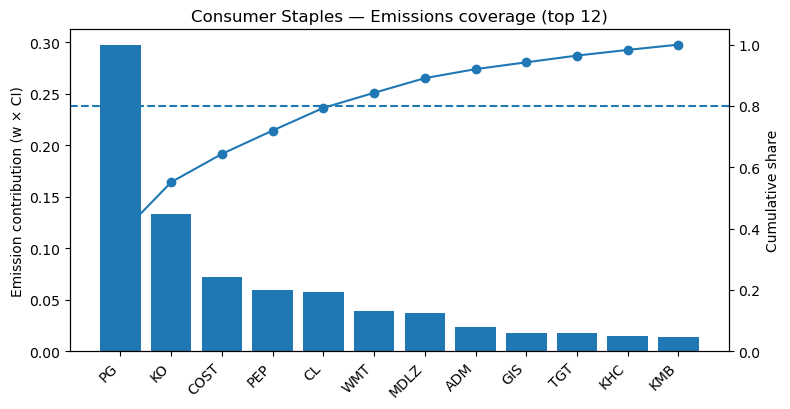

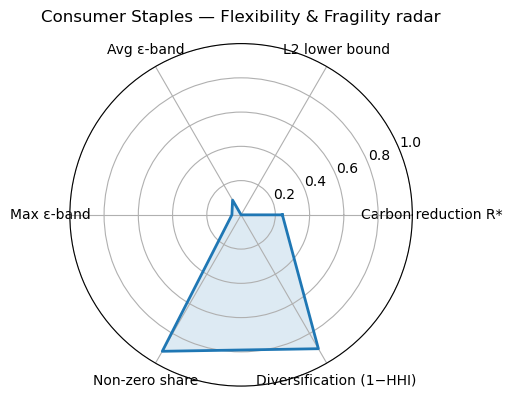

In [21]:
sector = "Consumer Staples"

# 1) profile card
sector_profile_table(sector, data, optimal_portfolios_shrink,
                     sector_bands, summary_df)

# 2a) emissions bar/Pareto (benchmark)
plot_sector_emissions_bar(sector, data, optimal_portfolios_shrink, top_k=12)

# 2b) radar (normalized across sectors)
plot_sector_radar(sector, summary_df,
                  optimal_portfolios_shrink, sector_bands)



=== Room for Maneuver — per sector (raw & composite) ===
                Sector  Slope_at_2pct  Elasticity_at_2pct  AUC_to_5pctTE  MaxCut_at_5pctTE  TE_for_50pctCut  Composite_Score
Communication Services           8.34                0.91           0.01              0.41              NaN             0.32
Consumer Discretionary          14.71                0.42           0.03              0.82             0.01             0.59
      Consumer Staples          15.78                0.87           0.02              0.73             0.03             0.52
                Energy          21.05                0.83           0.03              0.77             0.02             0.66
            Financials           3.08                0.07           0.05              0.97             0.00             0.60
           Health Care          17.74                0.69           0.03              0.82             0.02             0.62
           Industrials           5.48                0.12          

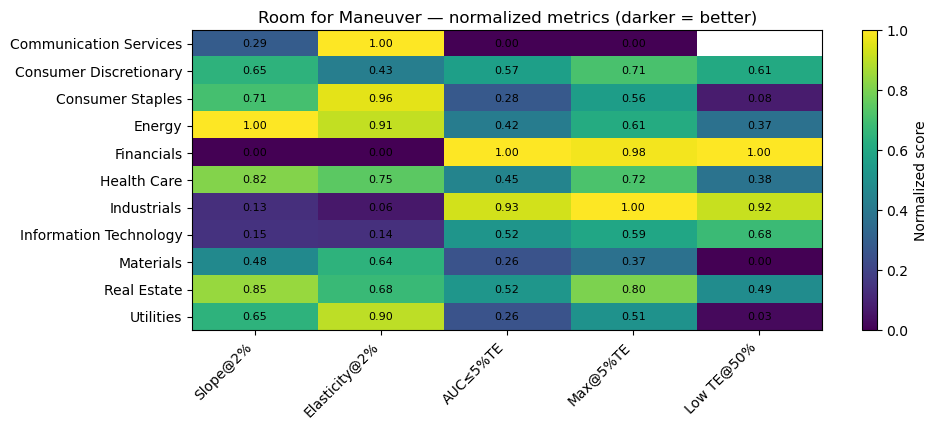

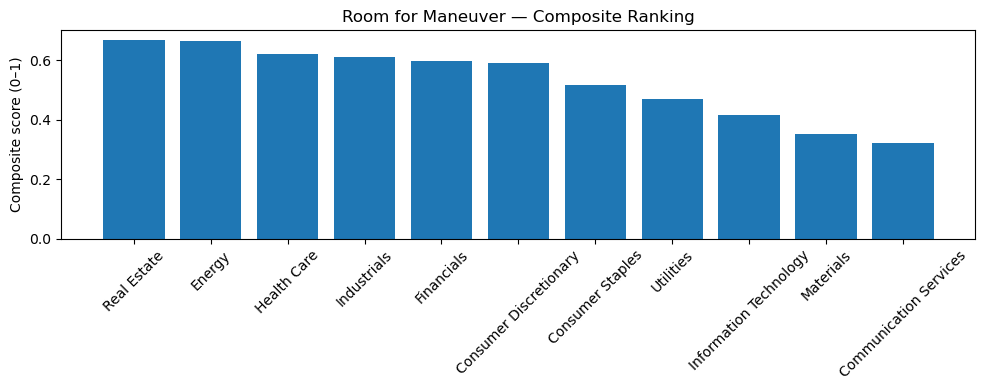

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Config
# =========================
TE_TARGET   = 0.02      # 2% TE point for slope / elasticity
TE_AUC_MAX  = 0.05      # integrate AUC up to 5% TE
TE_WIN_BPS  = 25        # +/- window (in bps) around TE_TARGET for finite-diff slope
PLOT_ORDER  = None      # or provide a list of sector names to control row order

# =========================
# Helpers
# =========================
def _prep_frontier(te_bps, cuts_pct):
    """Sort by TE, convert TE bps->fraction and cuts %->fraction, dedup on TE (keep max cut)."""
    te = np.asarray(te_bps, float) / 10000.0
    c  = np.asarray(cuts_pct, float) / 100.0
    m  = np.isfinite(te) & np.isfinite(c)
    te, c = te[m], c[m]
    order = np.argsort(te)
    te, c = te[order], c[order]
    # collapse duplicate TE by taking max cut
    if len(np.unique(te)) != len(te):
        uniq_te = np.unique(te)
        uniq_c  = [np.nanmax(c[te == t]) for t in uniq_te]
        te, c = uniq_te, np.array(uniq_c)
    return te, c

def _interp(te0, te_grid, c_grid):
    """Linear interpolate c(te0); clip outside range."""
    if te0 <= te_grid[0]:
        return float(c_grid[0])
    if te0 >= te_grid[-1]:
        return float(c_grid[-1])
    return float(np.interp(te0, te_grid, c_grid))

def _slope_at(te_grid, c_grid, te0, win_bps=25):
    """Finite-difference slope dc/dTE using a small symmetric window around te0."""
    if len(te_grid) < 2: return np.nan
    h = win_bps / 10000.0
    tl = max(te_grid[0], te0 - h)
    tr = min(te_grid[-1], te0 + h)
    if tr <= tl: return np.nan
    cl = _interp(tl, te_grid, c_grid)
    cr = _interp(tr, te_grid, c_grid)
    return (cr - cl) / (tr - tl)

def _elasticity_at(te_grid, c_grid, te0, win_bps=25):
    """Elasticity ≈ slope * (TE / c)."""
    c0 = _interp(te0, te_grid, c_grid)
    s  = _slope_at(te_grid, c_grid, te0, win_bps)
    if not np.isfinite(c0) or c0 <= 0 or not np.isfinite(s): return np.nan
    return s * (te0 / c0)

def _auc_to(te_grid, c_grid, te_max):
    """Trapezoid area under c(TE) from 0 to te_max."""
    xs = np.unique(np.clip(np.r_[0.0, te_grid, te_max], 0, te_max))
    ys = np.array([_interp(x, te_grid, c_grid) for x in xs])
    return float(np.trapz(ys, xs))

def _te_for_cut(te_grid, c_grid, cut_frac):
    """Smallest TE where c(TE) >= cut_frac (linear). Returns np.nan if unreachable."""
    if c_grid[0] >= cut_frac: return 0.0
    if c_grid[-1] <  cut_frac: return np.nan
    idx = np.searchsorted(c_grid, cut_frac, side="left")
    if idx == 0: return float(te_grid[0])
    x0, x1 = te_grid[idx-1], te_grid[idx]
    y0, y1 = c_grid[idx-1], c_grid[idx]
    if y1 == y0: return float(x1)
    t = (cut_frac - y0) / (y1 - y0)
    return float(x0 + t*(x1 - x0))

def _minmax(x):
    x = np.asarray(x, float)
    m = np.isfinite(x)
    if m.sum() <= 1: return np.full_like(x, np.nan)
    lo, hi = np.nanmin(x[m]), np.nanmax(x[m])
    if hi == lo: return np.zeros_like(x)
    out = (x - lo) / (hi - lo)
    out[~m] = np.nan
    return out

# =========================
# Build the metrics table
# =========================
def build_room_for_maneuver(sector_weights,
                            te_target=TE_TARGET,
                            te_auc_max=TE_AUC_MAX,
                            te_win_bps=TE_WIN_BPS,
                            sector_order=PLOT_ORDER):
    rows, skipped = [], []
    for sector, d in sector_weights.items():
        te_bps = d.get('tracking_errors', [])
        c_pct  = d.get('carbon_reductions', [])
        if len(te_bps) == 0 or len(c_pct) == 0:
            skipped.append(sector); continue

        te, c = _prep_frontier(te_bps, c_pct)
        if len(te) < 2:
            skipped.append(sector); continue

        slope2   = _slope_at(te, c, te_target, te_win_bps)
        elast2   = _elasticity_at(te, c, te_target, te_win_bps)
        auc5     = _auc_to(te, c, te_auc_max)
        max5     = _interp(te_auc_max, te, c)
        te50     = _te_for_cut(te, c, 0.50)

        rows.append(dict(
            Sector=sector,
            Slope_at_2pct=slope2,                # dc / dTE  at 2%
            Elasticity_at_2pct=elast2,           # (dc/c)/(dTE/TE) at 2%
            AUC_to_5pctTE=auc5,                  # ∫ c(TE) dTE, TE∈[0,5%]
            MaxCut_at_5pctTE=max5,               # c(5% TE)
            TE_for_50pctCut=te50                 # min TE s.t. c >= 50%
        ))

    df = pd.DataFrame(rows)
    if df.empty:
        return df, skipped

    # Normalizations (higher=better), invert TE_for_50pctCut
    df["norm_Slope_at_2pct"]      = _minmax(df["Slope_at_2pct"])
    df["norm_Elasticity_at_2pct"] = _minmax(df["Elasticity_at_2pct"])
    df["norm_AUC_to_5pctTE"]      = _minmax(df["AUC_to_5pctTE"])
    df["norm_MaxCut_at_5pctTE"]   = _minmax(df["MaxCut_at_5pctTE"])
    inv_te50                      = 1.0 - _minmax(df["TE_for_50pctCut"])
    df["norm_TE_for_50pctCut"]    = inv_te50

    norm_cols = [c for c in df.columns if c.startswith("norm_")]
    df["Composite_Score"] = np.nanmean(df[norm_cols].to_numpy(float), axis=1)

    # Optional ordering
    if sector_order:
        df["__ord__"] = pd.Categorical(df["Sector"], categories=sector_order, ordered=True)
        df = df.sort_values("__ord__").drop(columns="__ord__")
    else:
        df = df.sort_values("Sector")

    return df, skipped

def plot_cross_sector_heatmap(metrics_df):
    viz_cols   = ["norm_Slope_at_2pct", "norm_Elasticity_at_2pct",
                  "norm_AUC_to_5pctTE", "norm_MaxCut_at_5pctTE", "norm_TE_for_50pctCut"]
    viz_labels = ["Slope@2%", "Elasticity@2%", "AUC≤5%TE", "Max@5%TE", "Low TE@50%"]

    H = metrics_df[viz_cols].to_numpy(float)
    sectors = metrics_df["Sector"].tolist()

    fig, ax = plt.subplots(figsize=(10, max(4, 0.4*len(sectors))))
    im = ax.imshow(H, aspect="auto")
    ax.set_yticks(np.arange(len(sectors)))
    ax.set_yticklabels(sectors)
    ax.set_xticks(np.arange(len(viz_labels)))
    ax.set_xticklabels(viz_labels, rotation=45, ha="right")
    ax.set_title("Room for Maneuver — normalized metrics (darker = better)")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Normalized score")

    # annotate
    for i in range(H.shape[0]):
        for j in range(H.shape[1]):
            val = H[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

def plot_composite_bar(metrics_df):
    order = np.argsort(-metrics_df["Composite_Score"].to_numpy(float))
    sectors = np.array(metrics_df["Sector"])[order]
    scores  = metrics_df["Composite_Score"].to_numpy(float)[order]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(sectors, scores)
    ax.set_ylabel("Composite score (0–1)")
    ax.set_title("Room for Maneuver — Composite Ranking")
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

# =========================
# Run it
# =========================
metrics_df, skipped = build_room_for_maneuver(sector_weights,
                                              te_target=TE_TARGET,
                                              te_auc_max=TE_AUC_MAX,
                                              te_win_bps=TE_WIN_BPS,
                                              sector_order=PLOT_ORDER)

print("\n=== Room for Maneuver — per sector (raw & composite) ===")
display_cols = ["Sector","Slope_at_2pct","Elasticity_at_2pct","AUC_to_5pctTE","MaxCut_at_5pctTE","TE_for_50pctCut","Composite_Score"]
print(metrics_df[display_cols].round(3).to_string(index=False))

if skipped:
    print("\n(Frontier missing/too short for: " + ", ".join(skipped) + ")")

# Visualizations
plot_cross_sector_heatmap(metrics_df)
plot_composite_bar(metrics_df)


# Weight Perturbation Sensitivity – Before and After
Answering to the question: "Which sectors deliver robust solutions under changing input assumptions?"

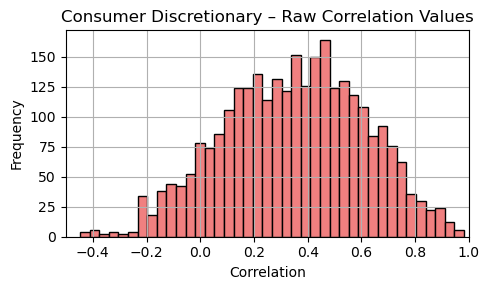

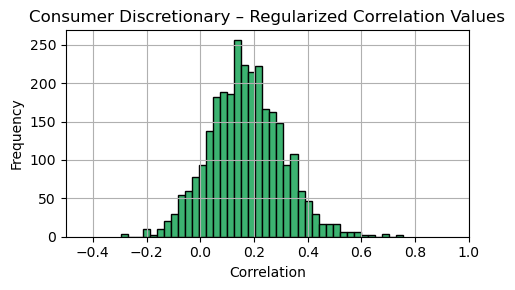

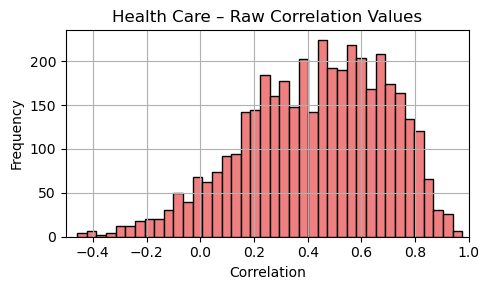

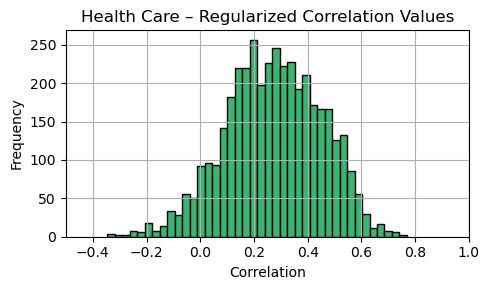

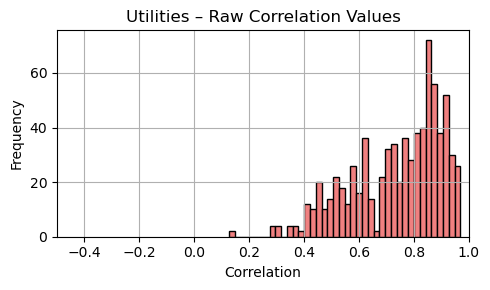

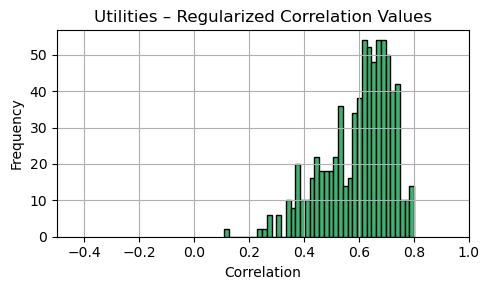

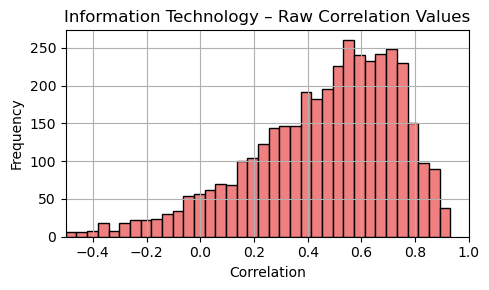

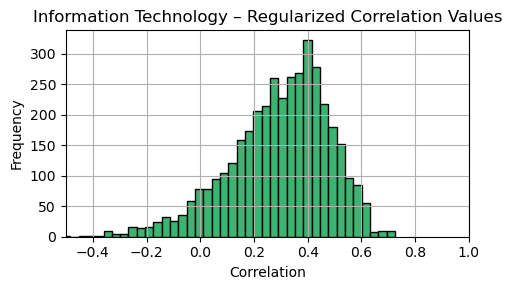

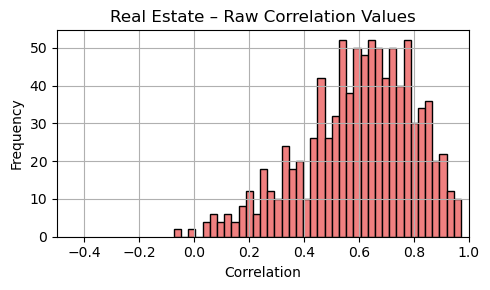

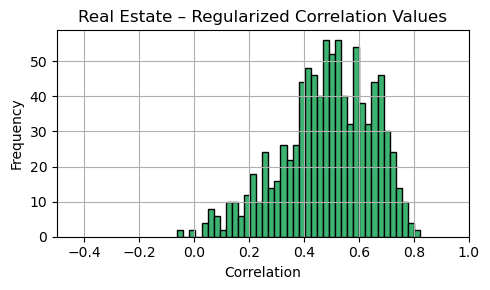

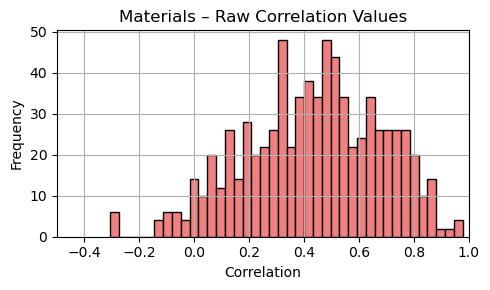

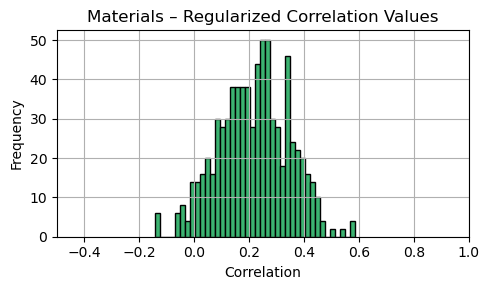

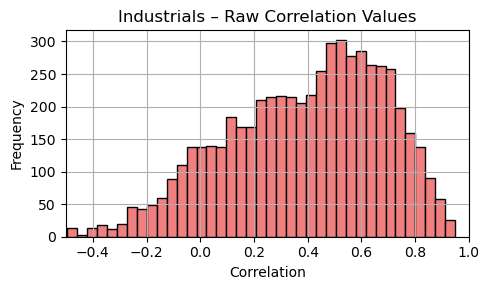

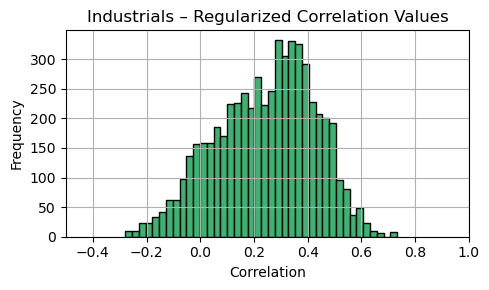

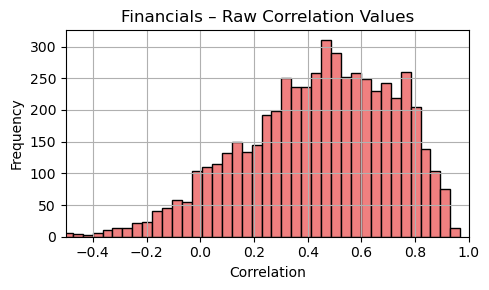

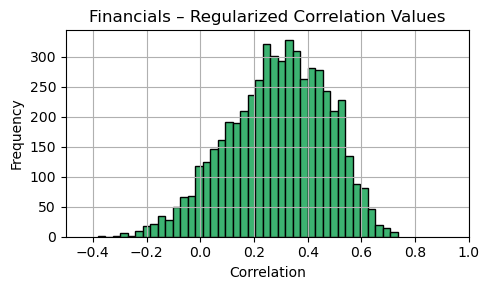

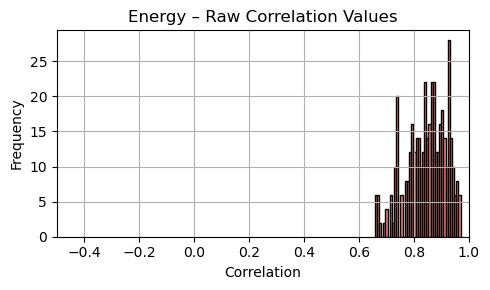

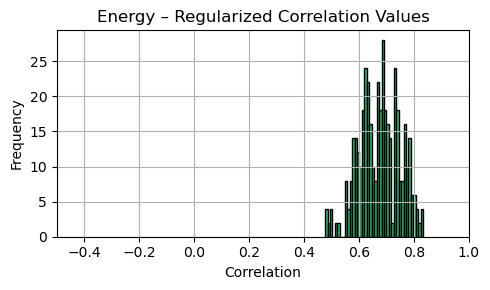

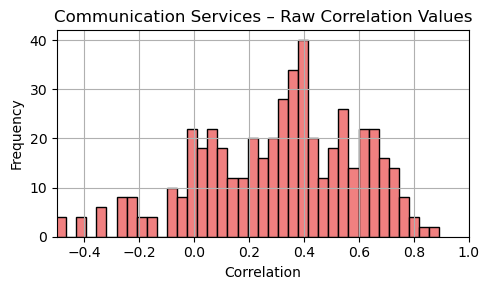

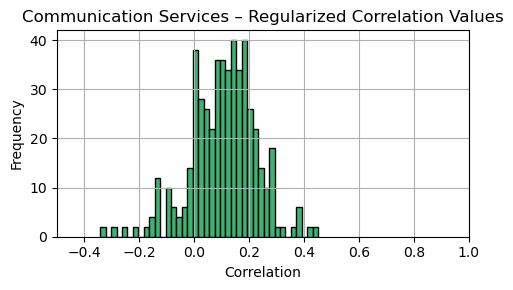

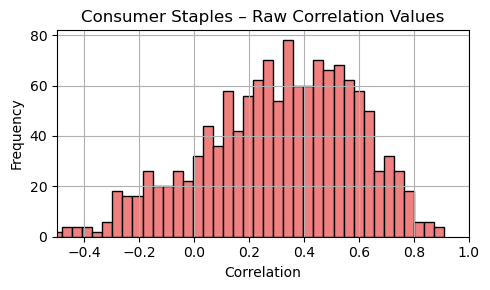

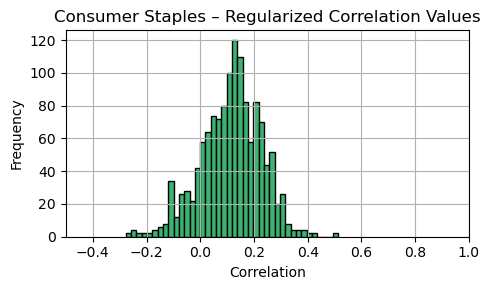

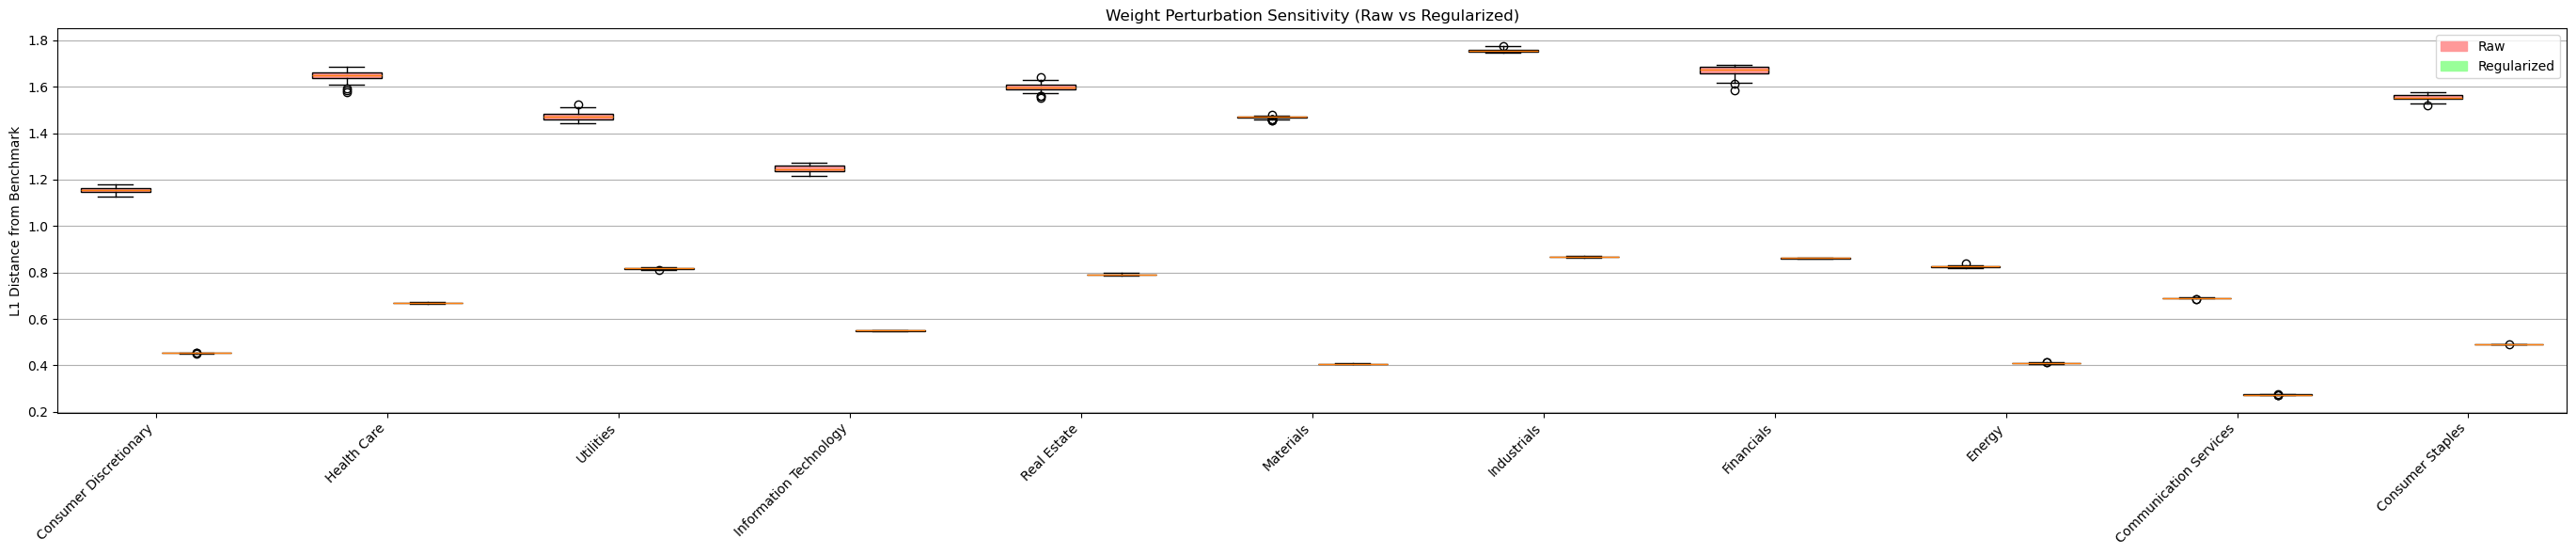

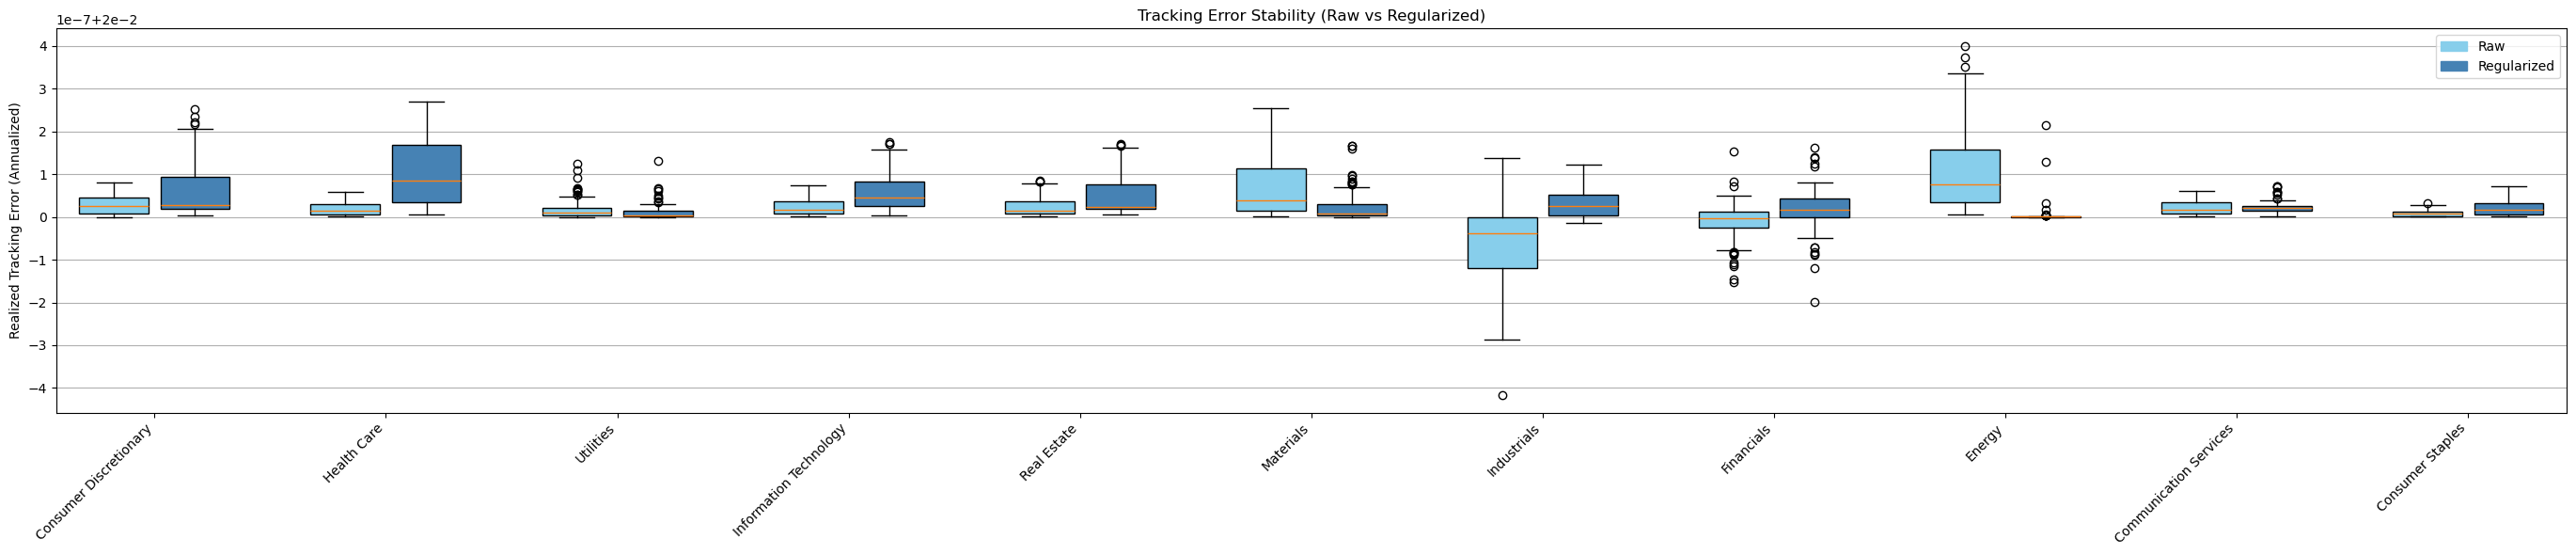

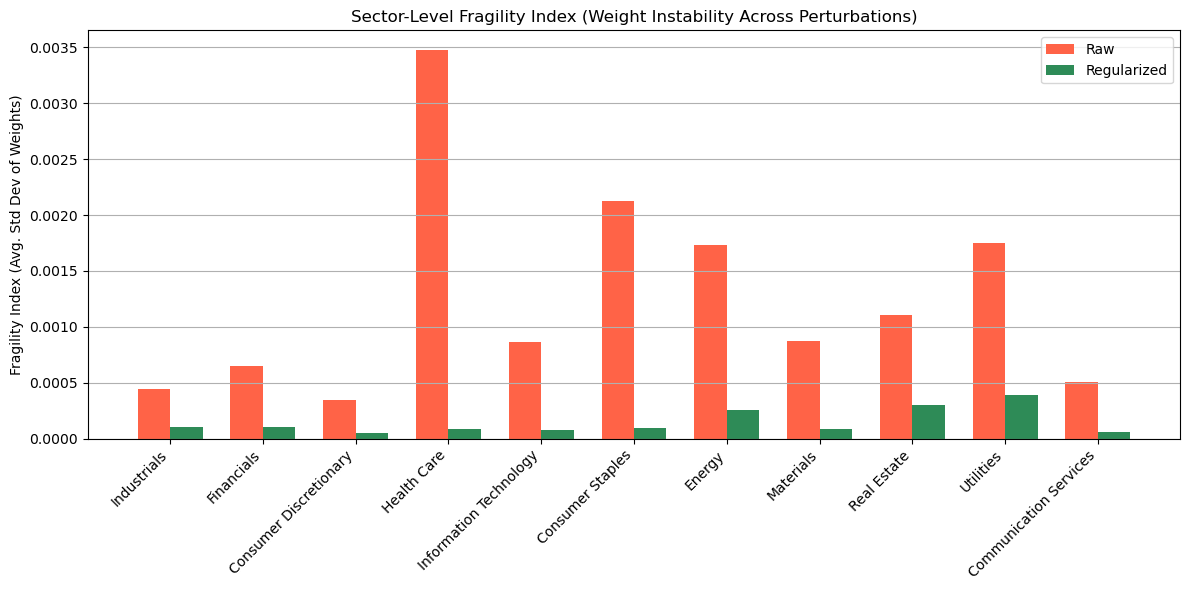

In [23]:
def sigma_reg_fn(R_clean):

    # Apply Ledoit-Wolf shrinkage
    lw = LedoitWolf().fit(R_clean)
    Sigma_shrink = lw.covariance_
    tolerance = 1e-4  # or 0.0001 (allows small wiggle room)

    # --- λI regularization ---
    lambda_I = 1e-5
    Sigma_reg = Sigma_shrink + lambda_I * np.eye(Sigma_shrink.shape[0])
    return Sigma_reg
def compute_perturbed_weights(
    R_clean,
    w_b_vec,
    c_vec,
    Sigma_fn,
    te_cap=0.03,
    n_trials=100,
    noise_std=0.01
):
    N = R_clean.shape[1]
    te_cap_var_monthly = (te_cap / np.sqrt(12)) ** 2
    weights = []
    tracking_errors = []

    for seed in range(n_trials):
        np.random.seed(seed)
        noise = np.random.normal(0, noise_std, R_clean.shape)
        R_perturbed = R_clean + R_clean.multiply(noise)
        Sigma = Sigma_fn(R_perturbed)

        w = cp.Variable(N)
        tracking_error = cp.quad_form(w - w_b_vec, cp.psd_wrap(Sigma))
        constraints = [tracking_error <= te_cap_var_monthly, cp.sum(w) == 1, w >= 0]
        objective = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.ECOS, verbose=False)

        if w.value is not None and prob.status in ["optimal", "optimal_inaccurate"]:
            weights.append(w.value)
            # compute realized TE
            diff = w.value - w_b_vec
            te_real = np.sqrt(diff.T @ Sigma @ diff) * np.sqrt(12)
            tracking_errors.append(te_real)
        else:
            weights.append(np.full(N, np.nan))
            tracking_errors.append(np.nan)

    return np.array(weights), np.array(tracking_errors)


data = pd.read_excel("Data/out-of-sample/dataset_comp_0622.xlsx")

for sector_name in data['GICS Sector'].unique():
    
    
    R = pd.read_excel("Data/out-of-sample/sector_log_returns_comp_0622.xlsx", sheet_name=sector_name)
    

    # Drop the 'Date' column — keep only numeric log returns
    R_numeric = R.drop(columns=['Date'])
    R_clean = R_numeric.dropna()
    
        # --- Histogram of Raw Correlation Matrix ---
    corr_raw = np.corrcoef(R_clean.T)
    off_diag_raw = corr_raw[~np.eye(corr_raw.shape[0], dtype=bool)]

    plt.figure(figsize=(5, 3))
    plt.hist(off_diag_raw, bins=40, color='lightcoral', edgecolor='black')
    plt.xlim(-0.5, 1)
    plt.title(f"{sector_name} – Raw Correlation Values")
    plt.xlabel("Correlation")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.grid(True)
    plt.show()

    # --- Histogram of Regularized Correlation Matrix ---
    Sigma_reg = sigma_reg_fn(R_clean)  # ← make sure sigma_reg_fn returns matrix only
    stds = np.sqrt(np.diag(Sigma_reg))
    corr_reg = Sigma_reg / np.outer(stds, stds)
    np.fill_diagonal(corr_reg, np.nan)
    off_diag_reg = corr_reg[~np.isnan(corr_reg)]

    plt.figure(figsize=(5, 3))
    plt.hist(off_diag_reg, bins=40, color='mediumseagreen', edgecolor='black')
    plt.title(f"{sector_name} – Regularized Correlation Values")
    plt.xlim(-0.5, 1)
    plt.xlabel("Correlation")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.grid(True)
    plt.show()

    sector = data.loc[data['GICS Sector'] == sector_name]

    w_b_sector = sector[['weight_in_sector']]
    w_b_vec = w_b_sector.values.flatten()
    c_sector = sector[['Carbon Intensity']]
    c_vec = c_sector.values.flatten()
    
    w_pert_raw, te_pert_raw = compute_perturbed_weights(R_clean, w_b_vec, c_vec, sigma_raw_fn, te_cap=0.02)
    w_pert_reg, te_pert_reg = compute_perturbed_weights(R_clean, w_b_vec, c_vec, sigma_reg_fn, te_cap=0.02)

    # Store
    sector_weights[sector_name]["te_raw"] = te_pert_raw[~np.isnan(te_pert_raw)]
    sector_weights[sector_name]["te_reg"] = te_pert_reg[~np.isnan(te_pert_reg)]

    # Compute standard deviation across perturbations (axis=0 → across trials)
    frag_raw = np.nanstd(w_pert_raw, axis=0).mean()
    frag_reg = np.nanstd(w_pert_reg, axis=0).mean()

    sector_weights[sector_name]["frag_raw"] = frag_raw
    sector_weights[sector_name]["frag_reg"] = frag_reg

    # L1 distances from baseline
    baseline_w = w_b_vec
    l1_raw = [np.sum(np.abs(w - baseline_w)) for w in w_pert_raw if not np.isnan(w).any()]
    l1_reg = [np.sum(np.abs(w - baseline_w)) for w in w_pert_reg if not np.isnan(w).any()]

    sector_weights[sector_name]["l1_raw"] = l1_raw
    sector_weights[sector_name]["l1_reg"] = l1_reg

    sectors = list(sector_weights.keys())
num_sectors = len(sectors)

fig, ax = plt.subplots(figsize=(2.5 * num_sectors, 6))

# Prepare data and positions
all_data = []
positions = []
labels = []
colors = []

for i, sector in enumerate(sectors):
    raw = sector_weights[sector]['l1_raw']
    reg = sector_weights[sector]['l1_reg']
    
    all_data.extend([raw, reg])
    positions.extend([2 * i, 2 * i + 0.7])
    labels.extend([f'{sector}\nRaw', 'Reg'])
    colors.extend(['#ff9999', '#99ff99'])  # light red, light green

# Plot boxplots
box = ax.boxplot(all_data, positions=positions, patch_artist=True, widths=0.6)

# Apply custom colors
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Set x-axis
ax.set_xticks([2 * i + 0.35 for i in range(num_sectors)])
ax.set_xticklabels(sectors, rotation=45, ha='right')

# Labels and styling
ax.set_ylabel("L1 Distance from Benchmark")
ax.set_title("Weight Perturbation Sensitivity (Raw vs Regularized)")
ax.grid(True, axis='y')

# Legend manually
legend_patches = [Patch(color='#ff9999', label='Raw'), Patch(color='#99ff99', label='Regularized')]
ax.legend(handles=legend_patches, loc='upper right')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(2.5 * num_sectors, 6))
all_te_data = []
te_positions = []
te_colors = []
te_labels = []

for i, sector in enumerate(sectors):
    raw = sector_weights[sector]['te_raw']
    reg = sector_weights[sector]['te_reg']

    all_te_data.extend([raw, reg])
    te_positions.extend([2 * i, 2 * i + 0.7])
    te_labels.extend([f'{sector}\nRaw', 'Reg'])
    te_colors.extend(['#87CEEB', '#4682B4'])  # blue shades

box = ax.boxplot(all_te_data, positions=te_positions, patch_artist=True, widths=0.6)
for patch, color in zip(box['boxes'], te_colors):
    patch.set_facecolor(color)

ax.set_xticks([2 * i + 0.35 for i in range(num_sectors)])
ax.set_xticklabels(sectors, rotation=45, ha='right')
ax.set_ylabel("Realized Tracking Error (Annualized)")
ax.set_title("Tracking Error Stability (Raw vs Regularized)")
ax.grid(True, axis='y')

legend_patches = [Patch(color='#87CEEB', label='Raw'), Patch(color='#4682B4', label='Regularized')]
ax.legend(handles=legend_patches, loc='upper right')

plt.tight_layout()
plt.show()

frag_raw_all = []
frag_reg_all = []
sectors = []

for sector_name in ordered_sectors:
    if sector_name in sector_weights:
        if "frag_raw" in sector_weights[sector_name] and "frag_reg" in sector_weights[sector_name]:
            frag_raw_all.append(sector_weights[sector_name]["frag_raw"])
            frag_reg_all.append(sector_weights[sector_name]["frag_reg"])
            sectors.append(sector_name)

x = np.arange(len(sectors))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, frag_raw_all, width, label='Raw', color='tomato')
plt.bar(x + width/2, frag_reg_all, width, label='Regularized', color='seagreen')
plt.xticks(x, sectors, rotation=45, ha='right')
plt.ylabel("Fragility Index (Avg. Std Dev of Weights)")
plt.title("Sector-Level Fragility Index (Weight Instability Across Perturbations)")
plt.legend()
plt.tight_layout()
plt.grid(True, axis='y')
plt.show()



In [24]:

# === UTILITIES ===

def sigma_raw_fn(R_clean):
    return R_clean.cov()

def sigma_reg_fn(R_clean):
    lw = LedoitWolf().fit(R_clean)
    Sigma_shrink = lw.covariance_
    lambda_I = 1e-5
    return Sigma_shrink + lambda_I * np.eye(Sigma_shrink.shape[0])

def simulate_parametric_noise(mu, Sigma, T, n_trials):
    return [np.random.multivariate_normal(mu, Sigma, T) for _ in range(n_trials)]

def bootstrap_returns(R_clean_np, n_trials):
    T = R_clean_np.shape[0]
    return [R_clean_np[np.random.choice(T, T, replace=True)] for _ in range(n_trials)]

def compute_perturbed_weights_from_samples(R_samples, w_b_vec, c_vec, Sigma_fn, te_cap=0.03):
    weights, tracking_errors = [], []
    te_cap_var_monthly = (te_cap / np.sqrt(12)) ** 2
    N = len(w_b_vec)

    for R_perturbed in R_samples:
        Sigma = Sigma_fn(pd.DataFrame(R_perturbed))
        w = cp.Variable(N)
        tracking_error = cp.quad_form(w - w_b_vec, cp.psd_wrap(Sigma))
        constraints = [tracking_error <= te_cap_var_monthly, cp.sum(w) == 1, w >= 0]
        objective = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.ECOS, verbose=False)

        if w.value is not None and prob.status in ["optimal", "optimal_inaccurate"]:
            weights.append(w.value)
            diff = w.value - w_b_vec
            te_real = np.sqrt(diff.T @ Sigma @ diff) * np.sqrt(12)
            tracking_errors.append(te_real)
        else:
            weights.append(np.full(N, np.nan))
            tracking_errors.append(np.nan)

    return np.array(weights), np.array(tracking_errors)

def compute_perturbed_weights(
    R_clean,
    w_b_vec,
    c_vec,
    Sigma_fn,
    te_cap=0.03,
    n_trials=100,
    noise_std=0.01,
    noise_type="multiplicative"  # or "additive"
):
    N = R_clean.shape[1]
    te_cap_var_monthly = (te_cap / np.sqrt(12)) ** 2
    weights = []
    tracking_errors = []

    for seed in range(n_trials):
        np.random.seed(seed)
        noise = np.random.normal(0, noise_std, R_clean.shape)

        if noise_type == "multiplicative":
            R_perturbed = R_clean + R_clean.multiply(noise)
        elif noise_type == "additive":
            R_perturbed = R_clean + noise
        else:
            raise ValueError("noise_type must be 'multiplicative' or 'additive'")

        Sigma = Sigma_fn(R_perturbed)

        w = cp.Variable(N)
        tracking_error = cp.quad_form(w - w_b_vec, cp.psd_wrap(Sigma))
        constraints = [tracking_error <= te_cap_var_monthly, cp.sum(w) == 1, w >= 0]
        objective = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.ECOS, verbose=False)

        if w.value is not None and prob.status in ["optimal", "optimal_inaccurate"]:
            weights.append(w.value)
            diff = w.value - w_b_vec
            te_real = np.sqrt(diff.T @ Sigma @ diff) * np.sqrt(12)
            tracking_errors.append(te_real)
        else:
            weights.append(np.full(N, np.nan))
            tracking_errors.append(np.nan)

    return np.array(weights), np.array(tracking_errors)


def compute_hhi(weights):
    return np.sum(np.square(weights))

def check_total_variability(R_clean, sector_name):
    stds = R_clean.std(axis=0)
    avg_std = np.mean(stds)
    print(f"{sector_name}: Avg Std Dev = {avg_std:.4f}")

In [25]:
data = pd.read_excel("Data/out-of-sample/dataset_comp_0622.xlsx")
sector_weights = {}
n_trials = 100

for sector_name in data['GICS Sector'].unique():
    R = pd.read_excel("Data/out-of-sample/sector_log_returns_comp_0622.xlsx", sheet_name=sector_name)
    R_clean = R.drop(columns=['Date']).dropna()
    R_np = R_clean.values
    mu_hat = R_np.mean(axis=0)
    Sigma_hat = np.cov(R_np, rowvar=False)
    T = R_np.shape[0]

    sector = data[data['GICS Sector'] == sector_name]
    w_b_vec = sector['weight_in_sector'].values
    c_vec = sector['Carbon Intensity'].values

    # Simulate
    param_samples = simulate_parametric_noise(mu_hat, Sigma_hat, T, n_trials)
    boot_samples = bootstrap_returns(R_np, n_trials)

    # Optimization (raw vs regularized)
    w_param_raw, te_param_raw = compute_perturbed_weights_from_samples(param_samples, w_b_vec, c_vec, sigma_raw_fn)
    w_param_reg, te_param_reg = compute_perturbed_weights_from_samples(param_samples, w_b_vec, c_vec, sigma_reg_fn)

    w_boot_raw, te_boot_raw = compute_perturbed_weights_from_samples(boot_samples, w_b_vec, c_vec, sigma_raw_fn)
    w_boot_reg, te_boot_reg = compute_perturbed_weights_from_samples(boot_samples, w_b_vec, c_vec, sigma_reg_fn)

    w_mult_raw, te_mult_raw = compute_perturbed_weights(R_clean, w_b_vec, c_vec, sigma_raw_fn, noise_type="multiplicative", noise_std=0.3)
    w_mult_reg, te_mult_reg = compute_perturbed_weights(R_clean, w_b_vec, c_vec, sigma_reg_fn, noise_type="multiplicative", noise_std=0.3)

    w_add_raw, te_add_raw = compute_perturbed_weights(R_clean, w_b_vec, c_vec, sigma_raw_fn, noise_type="additive")
    w_add_reg, te_add_reg = compute_perturbed_weights(R_clean, w_b_vec, c_vec, sigma_reg_fn, noise_type="additive")

    # Condition Numbers
    cond_raw = np.linalg.cond(sigma_raw_fn(R_clean))
    cond_reg = np.linalg.cond(sigma_reg_fn(R_clean))

    # Fragility
    frag_param_raw = np.nanstd(w_param_raw, axis=0).mean()
    frag_param_reg = np.nanstd(w_param_reg, axis=0).mean()
    frag_boot_raw = np.nanstd(w_boot_raw, axis=0).mean()
    frag_boot_reg = np.nanstd(w_boot_reg, axis=0).mean()
    frag_mult_raw = np.nanstd(w_mult_raw, axis=0).mean()
    frag_mult_reg = np.nanstd(w_mult_reg, axis=0).mean()
    frag_add_raw = np.nanstd(w_add_raw, axis=0).mean()
    frag_add_reg = np.nanstd(w_add_reg, axis=0).mean()

    # Fragility ratios
    frag_ratio_param = frag_param_raw / frag_param_reg if frag_param_reg > 0 else np.nan
    frag_ratio_boot = frag_boot_raw / frag_boot_reg if frag_boot_reg > 0 else np.nan
    frag_ratio_mult = frag_mult_raw / frag_mult_reg if frag_mult_reg > 0 else np.nan
    frag_ratio_add = frag_add_raw / frag_add_reg if frag_add_reg > 0 else np.nan

    # L1 deviation
    l1_param_raw = [np.sum(np.abs(w - w_b_vec)) for w in w_param_raw if not np.isnan(w).any()]
    l1_param_reg = [np.sum(np.abs(w - w_b_vec)) for w in w_param_reg if not np.isnan(w).any()]
    l1_boot_raw = [np.sum(np.abs(w - w_b_vec)) for w in w_boot_raw if not np.isnan(w).any()]
    l1_boot_reg = [np.sum(np.abs(w - w_b_vec)) for w in w_boot_reg if not np.isnan(w).any()]
    l1_mult_raw = [np.sum(np.abs(w - w_b_vec)) for w in w_mult_raw if not np.isnan(w).any()]
    l1_mult_reg = [np.sum(np.abs(w - w_b_vec)) for w in w_mult_reg if not np.isnan(w).any()]
    l1_add_raw = [np.sum(np.abs(w - w_b_vec)) for w in w_add_raw if not np.isnan(w).any()]
    l1_add_reg = [np.sum(np.abs(w - w_b_vec)) for w in w_add_reg if not np.isnan(w).any()]

   # Concentration metrics
    hhi_benchmark = compute_hhi(w_b_vec)
   
    sector_weights[sector_name] = {
        # Fragility
        "frag_param_raw": frag_param_raw,
        "frag_param_reg": frag_param_reg,
        "frag_boot_raw": frag_boot_raw,
        "frag_boot_reg": frag_boot_reg,
        "frag_mult_raw": frag_mult_raw,
        "frag_mult_reg": frag_mult_reg,
        "frag_add_raw": frag_add_raw,
        "frag_add_reg": frag_add_reg,

        # Fragility ratios
        "frag_ratio_param": frag_ratio_param,
        "frag_ratio_boot": frag_ratio_boot,
        "frag_ratio_mult": frag_ratio_mult,
        "frag_ratio_add": frag_ratio_add,

        # L1 distances
        "l1_param_raw": l1_param_raw,
        "l1_param_reg": l1_param_reg,
        "l1_boot_raw": l1_boot_raw,
        "l1_boot_reg": l1_boot_reg,
        "l1_mult_raw": l1_mult_raw,
        "l1_mult_reg": l1_mult_reg,
        "l1_add_raw": l1_add_raw,
        "l1_add_reg": l1_add_reg,

        # Tracking Error
        "te_param_raw": te_param_raw,
        "te_param_reg": te_param_reg,
        "te_boot_raw": te_boot_raw,
        "te_boot_reg": te_boot_reg,
        "te_mult_raw": te_mult_raw,
        "te_mult_reg": te_mult_reg,
        "te_add_raw": te_add_raw,
        "te_add_reg": te_add_reg,

        # HHI – Concentration Scores
        "hhi_benchmark": hhi_benchmark,
        "hhi_param_raw": np.nanmean([compute_hhi(w) for w in w_param_raw if not np.isnan(w).any()]),
        "hhi_param_reg": np.nanmean([compute_hhi(w) for w in w_param_reg if not np.isnan(w).any()]),
        "hhi_boot_raw": np.nanmean([compute_hhi(w) for w in w_boot_raw if not np.isnan(w).any()]),
        "hhi_boot_reg": np.nanmean([compute_hhi(w) for w in w_boot_reg if not np.isnan(w).any()]),
        "hhi_mult_raw": np.nanmean([compute_hhi(w) for w in w_mult_raw if not np.isnan(w).any()]),
        "hhi_mult_reg": np.nanmean([compute_hhi(w) for w in w_mult_reg if not np.isnan(w).any()]),
        "hhi_add_raw": np.nanmean([compute_hhi(w) for w in w_add_raw if not np.isnan(w).any()]),
        "hhi_add_reg": np.nanmean([compute_hhi(w) for w in w_add_reg if not np.isnan(w).any()]),

        # Condition number
        "cond_raw": cond_raw,
        "cond_reg": cond_reg
    }


In [26]:
# ---------- main KPI function ----------
import numpy as np
import pandas as pd
import cvxpy as cp

# ---------- helpers ----------
def l1_turnover_pct(w_from, w_to):
    """One-way turnover (% of portfolio) to go from w_from → w_to."""
    return 0.5 * float(np.abs(w_to - w_from).sum()) * 100.0

def cosine_similarity(a, b):
    a = np.asarray(a); b = np.asarray(b)
    na = np.linalg.norm(a); nb = np.linalg.norm(b)
    if na == 0 or nb == 0:
        return np.nan
    return float(np.dot(a, b) / (na * nb))

def realized_te_annual(w, w_b, Sigma):
    """Annualized TE in decimal (e.g., 0.02 == 2%)."""
    diff = (w - w_b)
    te_m = float(diff.T @ Sigma @ diff)
    te_a = np.sqrt(te_m) * np.sqrt(12.0)
    return te_a

def carbon_reduction_pct(w, w_b, c_vec):
    """% reduction relative to benchmark carbon; returns in percent units."""
    cb = float(np.dot(w_b, c_vec))
    co = float(np.dot(w,   c_vec))
    if cb == 0:
        return np.nan
    return (cb - co) / cb * 100.0

def nanpercentile(x, q):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.percentile(x, q)) if x.size else np.nan

def sensitivity_kpis_from_trials(
    w_trials,             # (n_trials, N) weights from perturbations (optimized each trial)
    te_trials_annual,     # (n_trials,) TE in decimal for each trial (annualized)
    R_clean,              # baseline returns (DataFrame without Date)
    w_b_vec,              # benchmark weights (N,)
    c_vec,                # carbon intensity per name (N,)
    Sigma_fn,             # function R_clean -> Sigma
    te_cap=0.02,          # baseline TE cap (annual)
    w_opt0=None           # baseline optimized weights; if None, will solve
):
    """
    Returns a dict with the KPIs + the raw per-trial series (for plots).
    """
    # Baseline (with clean Sigma)
    w_opt0, te0, Rstar0, Sigma0 = baseline_diagnostics(R_clean, w_b_vec, c_vec, Sigma_fn, te_cap, w_opt0)

    # Per-trial measures vs baseline optimized portfolio
    turnovers = []
    cosines   = []
    carbon_losses_pp = []   # baseline reduction minus trial reduction (pp)
    te_drifts_bps    = []   # |TE_trial - TE_baseline| in bps

    for w_t, te_t in zip(w_trials, te_trials_annual):
        if w_t is None or not np.all(np.isfinite(w_t)) or (te_t is None) or not np.isfinite(te_t):
            turnovers.append(np.nan); cosines.append(np.nan)
            carbon_losses_pp.append(np.nan); te_drifts_bps.append(np.nan)
            continue

        # Turnover and Cosine vs baseline optimized
        turnovers.append(l1_turnover_pct(w_opt0, w_t))
        cosines.append(cosine_similarity(w_opt0, w_t))

        # Carbon reduction loss (pp): max(0, baseline_reduction - trial_reduction)
        Rstar_t = carbon_reduction_pct(w_t, w_b_vec, c_vec)   # in %
        carbon_losses_pp.append(max(0.0, Rstar0 - Rstar_t))

        # TE drift (bps) relative to baseline TE
        te_drifts_bps.append(abs(te_t - te0) * 10000.0)

    # Aggregate KPIs
    kpis = {
        "Median_Turnover_pct":        nanpercentile(turnovers, 50),
        "Median_Cosine":              nanpercentile(cosines, 50),
        "P95_CarbonLoss_pp":          nanpercentile(carbon_losses_pp, 95),
        "P95_TE_Drift_bps":           nanpercentile(te_drifts_bps, 95),
        # keep handy for plots/debug
        "series": {
            "turnover_pct": np.array(turnovers, dtype=float),
            "cosine":       np.array(cosines, dtype=float),
            "carbon_loss_pp": np.array(carbon_losses_pp, dtype=float),
            "te_drift_bps":   np.array(te_drifts_bps, dtype=float),
            "baseline": {
                "w_opt0": w_opt0,
                "te0_annual": te0,
                "Rstar0_pct": Rstar0
            }
        }
    }
    return kpis

# ---------- baseline (can reuse your precomputed dict) ----------
def baseline_diagnostics(R_clean, w_b_vec, c_vec, Sigma_fn, te_cap=0.02, w_opt=None):
    """
    Returns (w_opt0, te0_annual, Rstar0, Sigma0)
    - If w_opt is None, solves the baseline optimization; otherwise uses provided w_opt.
    """
    # Sigma at baseline (on clean returns)
    Sigma0 = Sigma_fn(R_clean)

    if w_opt is None:
        # Solve baseline optim (same as your optimize_sector but minimal)
        N = len(w_b_vec)
        w = cp.Variable(N)
        te_cap_var_monthly = (te_cap / np.sqrt(12))**2
        tracking_error = cp.quad_form(w - w_b_vec, cp.psd_wrap(Sigma0))
        obj = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        cons = [tracking_error <= te_cap_var_monthly, cp.sum(w) == 1, w >= 0]
        prob = cp.Problem(obj, cons)
        prob.solve(solver=cp.ECOS, verbose=False)
        if prob.status not in ("optimal","optimal_inaccurate") or w.value is None:
            raise RuntimeError(f"Baseline optimization failed: {prob.status}")
        w_opt0 = w.value
    else:
        w_opt0 = np.asarray(w_opt, dtype=float)

    te0 = realized_te_annual(w_opt0, w_b_vec, Sigma0)              # decimal, e.g. 0.02
    Rstar0 = carbon_reduction_pct(w_opt0, w_b_vec, c_vec)          # percent
    return w_opt0, te0, Rstar0, Sigma0

In [27]:
import pickle

# number of perturbations
n_trials = 100

sensitivity_results = {}

for sector_name in data['GICS Sector'].unique():
    print(f"[{sector_name}] computing sensitivity KPIs…")

    # Load returns for this sector
    R = pd.read_excel("Data/out-of-sample/sector_log_returns_comp_0622.xlsx", sheet_name=sector_name)
    R_clean = R.drop(columns=['Date']).dropna()

    # Benchmark weights + carbon intensity
    sector = data[data['GICS Sector'] == sector_name]
    w_b_vec = sector['weight_in_sector'].values
    c_vec   = sector['Carbon Intensity'].values

    # Baseline optimized weights (already precomputed in your dict)
    w_opt0 = optimal_portfolios_shrink[sector_name]["w_opt"]

    # === Perturbations ===
    # Use multiplicative noise on returns + regularized covariance (recommended)
    w_trials, te_trials = compute_perturbed_weights(
        R_clean,
        w_b_vec,
        c_vec,
        sigma_reg_fn,
        te_cap=0.02,          # annual TE cap
        n_trials=n_trials,
        noise_std=0.3,
        noise_type="multiplicative"
    )

    # === Compute KPIs ===
    kpis = sensitivity_kpis_from_trials(
        w_trials=w_trials,
        te_trials_annual=te_trials,
        R_clean=R_clean,
        w_b_vec=w_b_vec,
        c_vec=c_vec,
        Sigma_fn=sigma_reg_fn,
        te_cap=0.02,
        w_opt0=w_opt0
    )

    sensitivity_results[sector_name] = {
        "Median_Turnover_pct": kpis["Median_Turnover_pct"],
        "Median_Cosine": kpis["Median_Cosine"],
        "P95_CarbonLoss_pp": kpis["P95_CarbonLoss_pp"],
        "P95_TE_Drift_bps": kpis["P95_TE_Drift_bps"],
    }

# Save results to pickle
with open("Data/out-of-sample/sensitivity_kpis_0622.pkl", "wb") as f:
    pickle.dump(sensitivity_results, f)

print("✅ All done. Saved sensitivity KPIs to sensitivity_kpis.pkl")


[Consumer Discretionary] computing sensitivity KPIs…
[Health Care] computing sensitivity KPIs…
[Utilities] computing sensitivity KPIs…
[Information Technology] computing sensitivity KPIs…
[Real Estate] computing sensitivity KPIs…
[Materials] computing sensitivity KPIs…
[Industrials] computing sensitivity KPIs…
[Financials] computing sensitivity KPIs…
[Energy] computing sensitivity KPIs…
[Communication Services] computing sensitivity KPIs…
[Consumer Staples] computing sensitivity KPIs…
✅ All done. Saved sensitivity KPIs to sensitivity_kpis.pkl


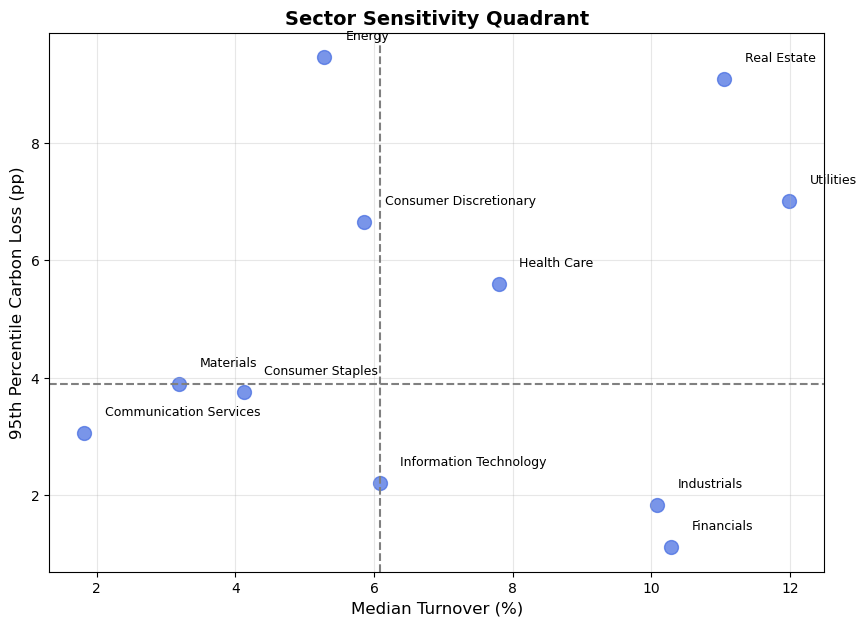

In [28]:
import matplotlib.pyplot as plt

# Your sensitivity data

# Extract values
sectors = list(sensitivity_results.keys())
x = [sensitivity_results[s]['Median_Turnover_pct'] for s in sectors]
y = [sensitivity_results[s]['P95_CarbonLoss_pp'] for s in sectors]

# Calculate medians to define quadrant boundaries
x_med = np.median(x)
y_med = np.median(y)

# Plot
plt.figure(figsize=(10, 7))
plt.scatter(x, y, s=100, color="royalblue", alpha=0.7)

# Add labels
for i, sector in enumerate(sectors):
    plt.text(x[i]+0.3, y[i]+0.3, sector, fontsize=9)

# Quadrant lines
plt.axvline(x=x_med, color="grey", linestyle="--")
plt.axhline(y=y_med, color="grey", linestyle="--")

# Titles and labels
plt.title("Sector Sensitivity Quadrant", fontsize=14, fontweight="bold")
plt.xlabel("Median Turnover (%)", fontsize=12)
plt.ylabel("95th Percentile Carbon Loss (pp)", fontsize=12)

# Axis grid
plt.grid(alpha=0.3)

plt.show()


In [29]:
for sector_name in data['GICS Sector'].unique():
    R = pd.read_excel("Data/out-of-sample/sector_log_returns_comp_0622.xlsx", sheet_name=sector_name)
    R_clean = R.drop(columns=['Date']).dropna()
    check_total_variability(R_clean, sector_name)

Consumer Discretionary: Avg Std Dev = 0.0949
Health Care: Avg Std Dev = 0.0851
Utilities: Avg Std Dev = 0.0636
Information Technology: Avg Std Dev = 0.0969
Real Estate: Avg Std Dev = 0.0749
Materials: Avg Std Dev = 0.0893
Industrials: Avg Std Dev = 0.0776
Financials: Avg Std Dev = 0.0745
Energy: Avg Std Dev = 0.1196
Communication Services: Avg Std Dev = 0.0982
Consumer Staples: Avg Std Dev = 0.0616


Consumer Discretionary 1.3956519191646154e+18
Health Care 1.3146291732146364e+19
Utilities 4.424457249983664e+18
Information Technology 1.1446198882998241e+19
Real Estate 2.5117231967879905e+18
Materials 2.2180520884204419e+18
Industrials 1.8131872030255841e+19
Financials 1.0730589972528468e+19
Energy 6.416214520919002e+17
Communication Services 1.571598540484927e+18
Consumer Staples 2.001751148000778e+18


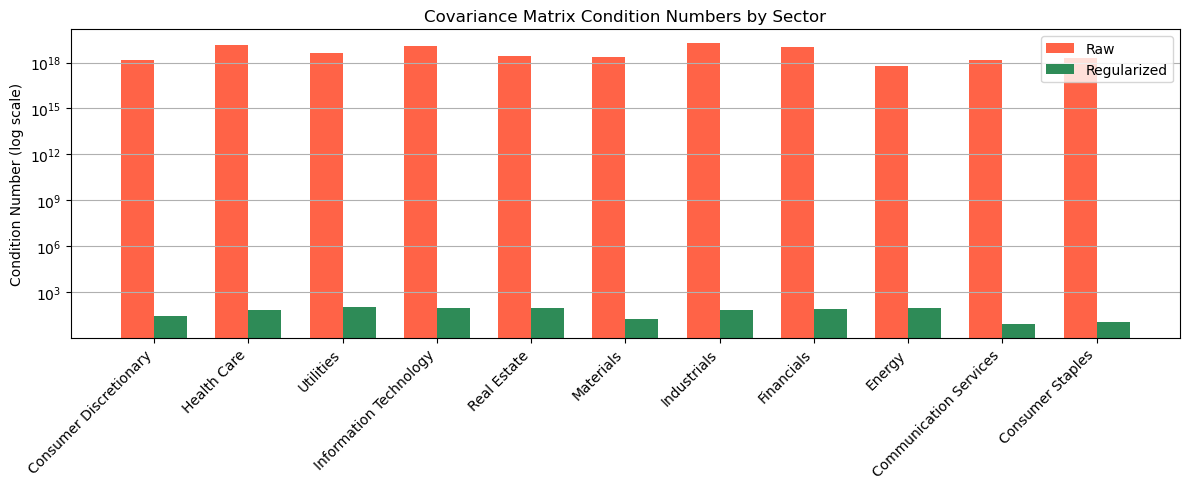

In [30]:
sectors = list(sector_weights.keys())
cond_raws = [sector_weights[s]["cond_raw"] for s in sectors]
cond_regs = [sector_weights[s]["cond_reg"] for s in sectors]
for s in sectors:
    print(s, sector_weights[s]["cond_raw"])

x = np.arange(len(sectors))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width / 2, cond_raws, width, label='Raw', color='tomato')
ax.bar(x + width / 2, cond_regs, width, label='Regularized', color='seagreen')

ax.set_yscale('log')  # <--- ADD THIS

ax.set_xticks(x)
ax.set_xticklabels(sectors, rotation=45, ha='right')
ax.set_ylabel("Condition Number (log scale)")
ax.set_title("Covariance Matrix Condition Numbers by Sector")
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()


In general all sectors are severely ill-conditioned, except for the Energy and Communication Services sectors that are mildy ill-conditioned.  What could be the reason why Energy condition number is lower?
Maybe because narrow spread of correlation (tigh around 0.6-0.9) can sometimes reduce spread in eigenvalues.
For communication services, it may be simply because of the low number of constituents. 

min: -2.12e-17
max: 2.00e-01
Condition number: -9.42e+15
1.40e+18


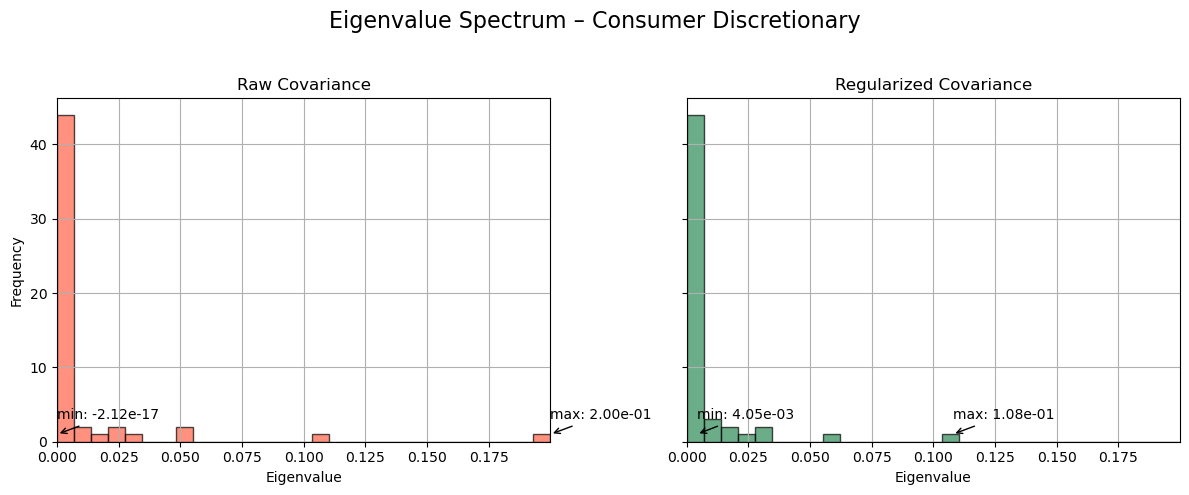

min: -1.34e-17
max: 2.46e-01
Condition number: -1.83e+16
1.31e+19


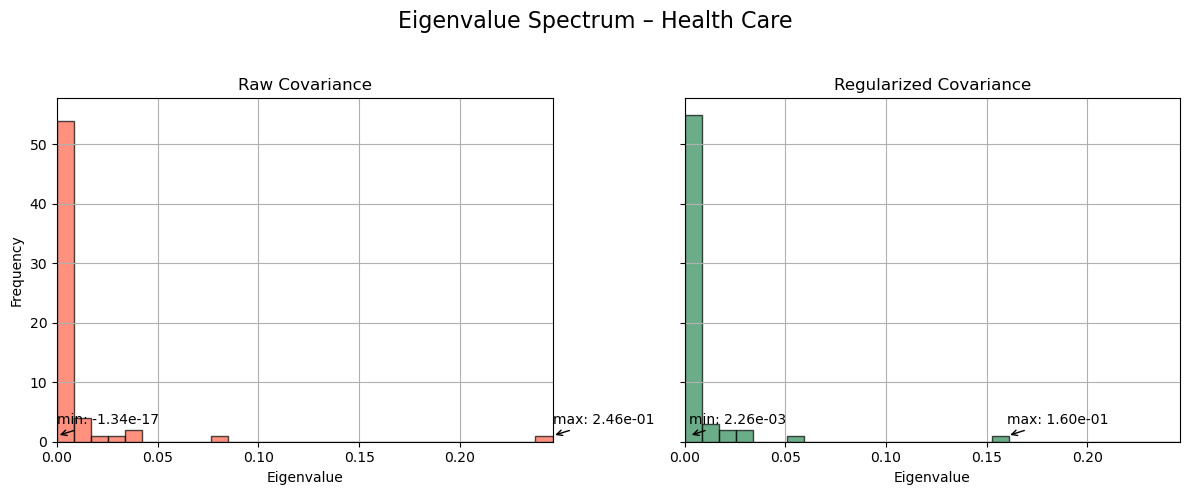

min: -2.28e-18
max: 8.43e-02
Condition number: -3.70e+16
4.42e+18


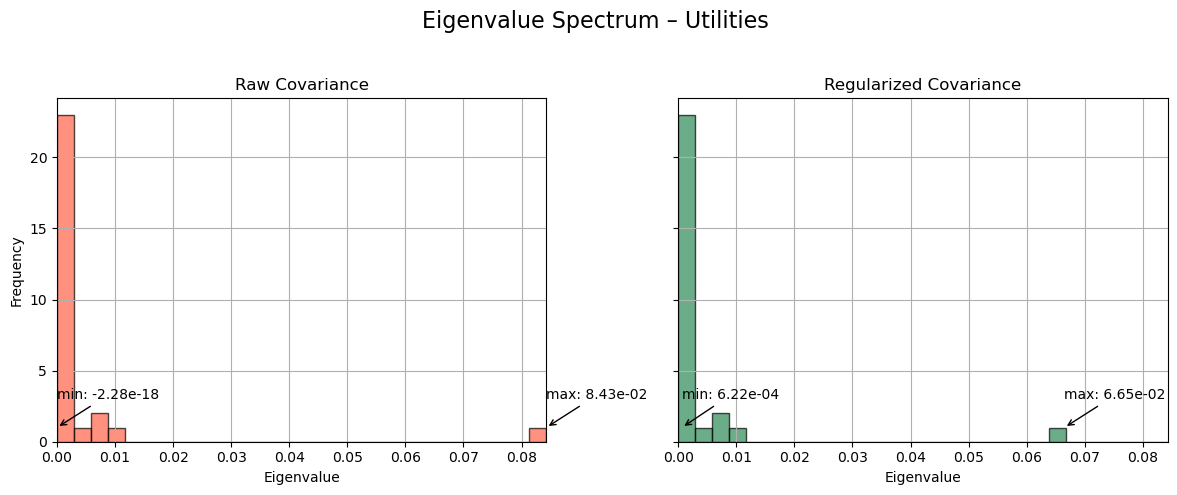

min: -1.80e-17
max: 3.41e-01
Condition number: -1.89e+16
1.14e+19


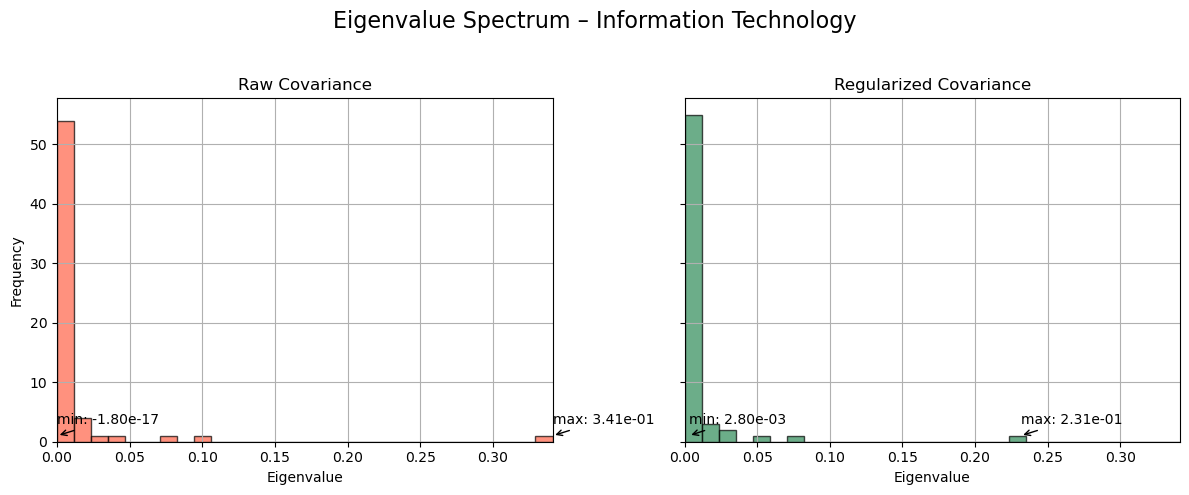

min: -5.77e-18
max: 1.13e-01
Condition number: -1.96e+16
2.51e+18


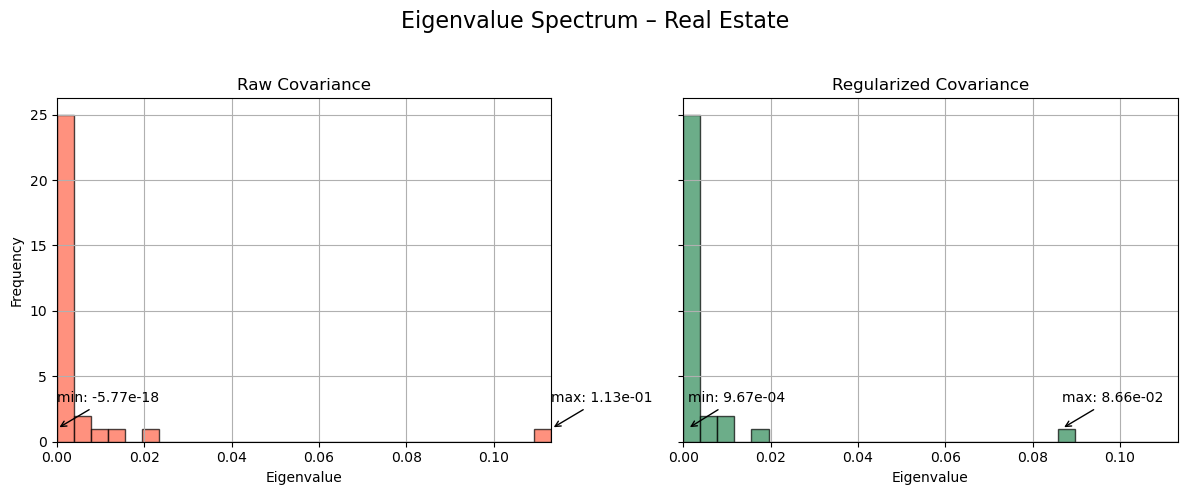

min: -6.80e-18
max: 1.15e-01
Condition number: -1.69e+16
2.22e+18


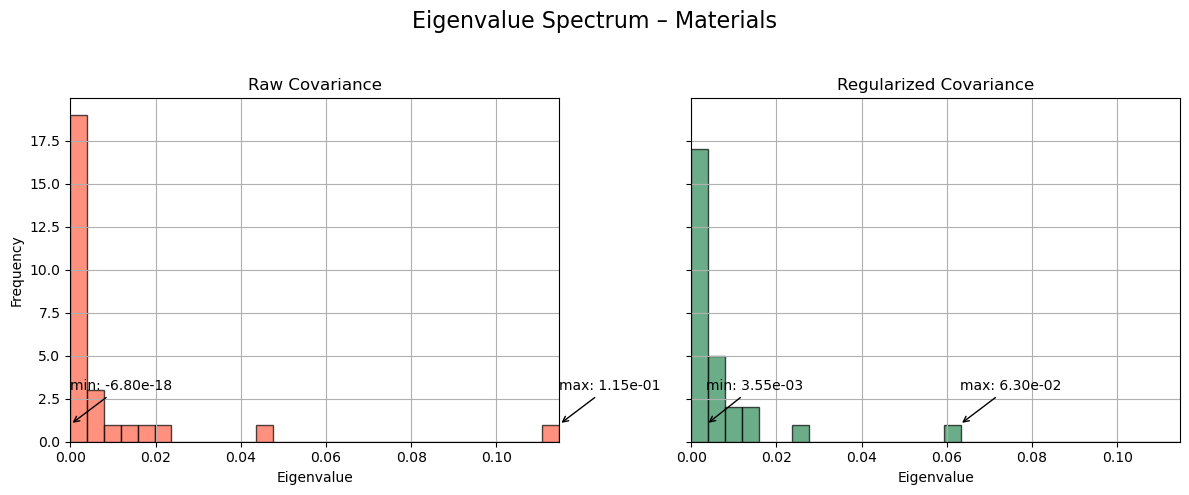

min: -1.95e-17
max: 2.18e-01
Condition number: -1.12e+16
1.81e+19


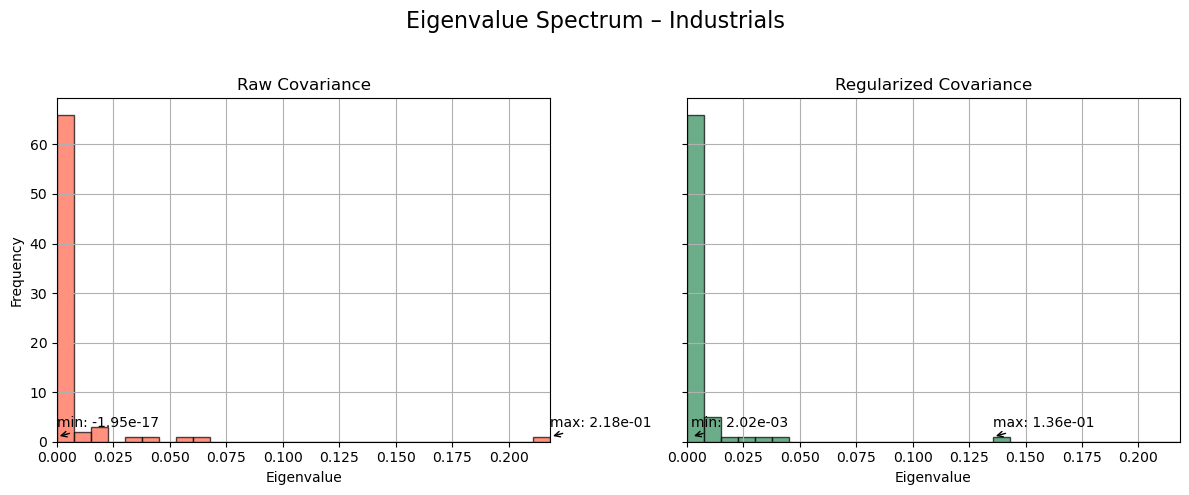

min: -1.47e-17
max: 2.10e-01
Condition number: -1.43e+16
1.07e+19


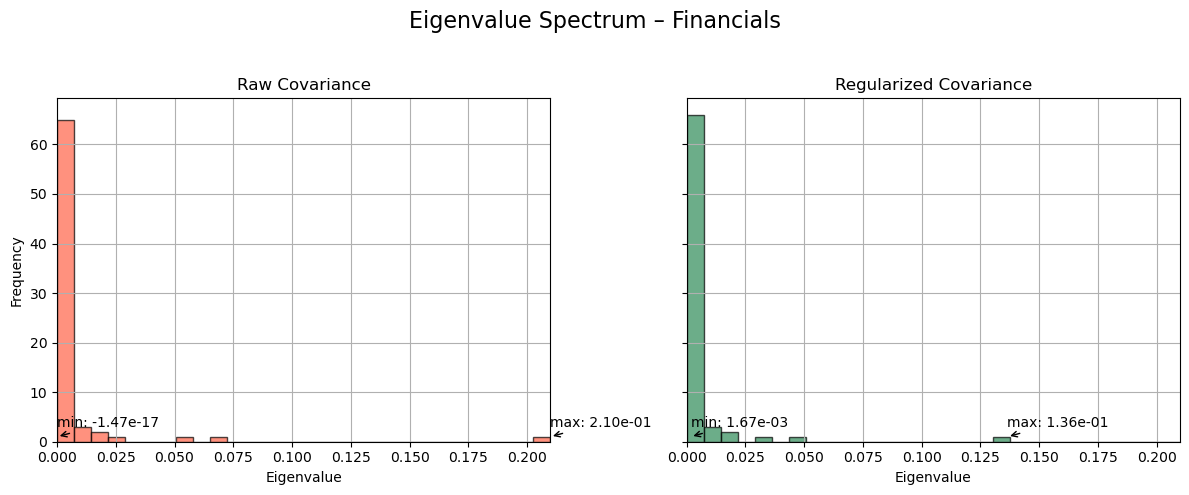

min: -1.02e-17
max: 2.68e-01
Condition number: -2.62e+16
6.42e+17


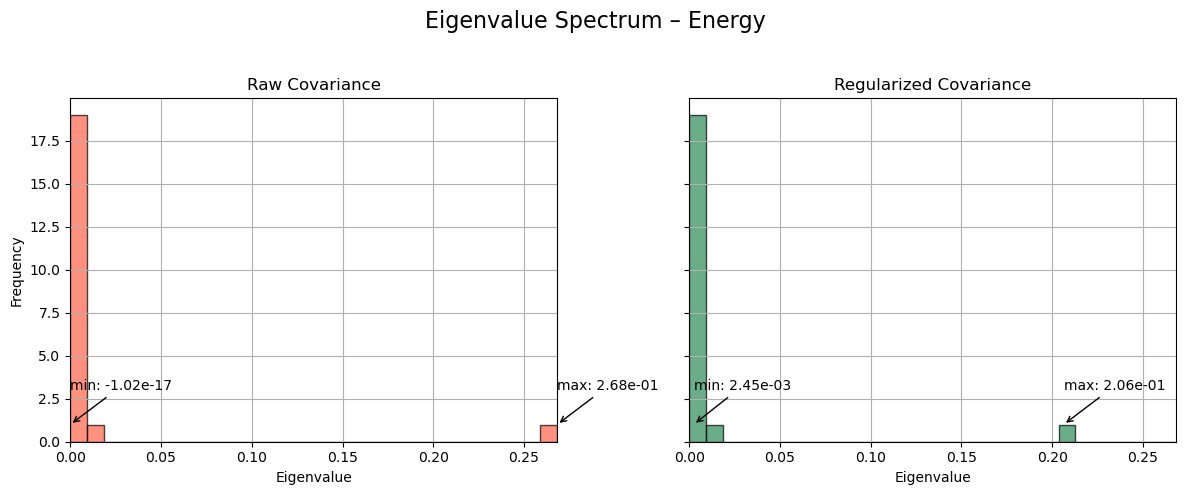

min: -5.78e-18
max: 1.09e-01
Condition number: -1.88e+16
1.57e+18


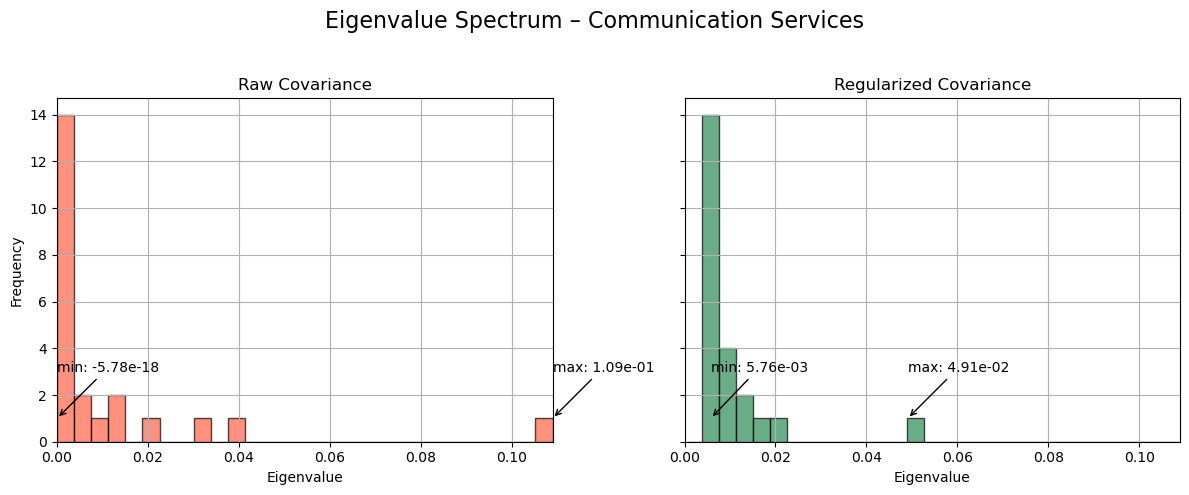

min: -8.02e-18
max: 4.91e-02
Condition number: -6.12e+15
2.00e+18


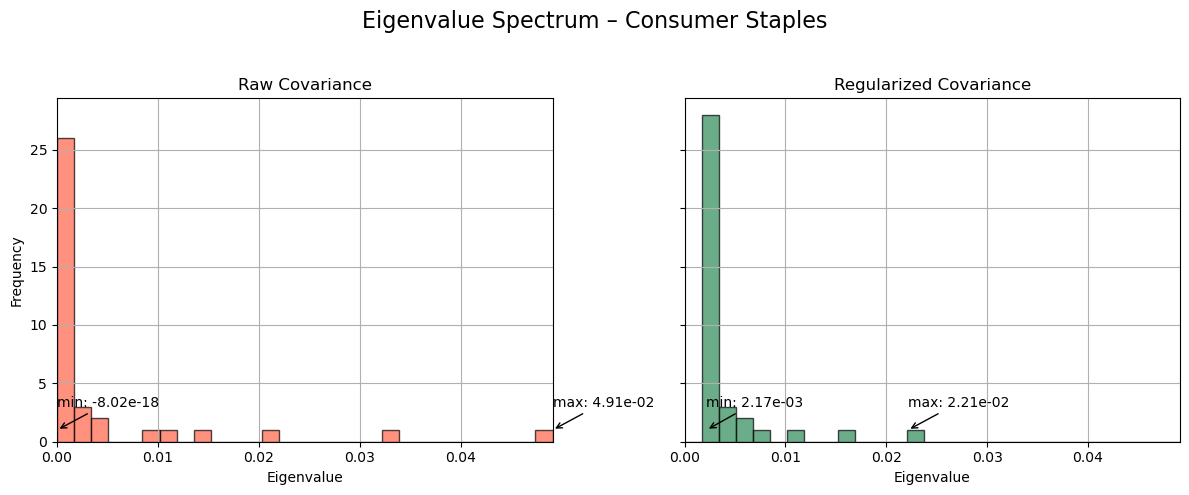

In [31]:

def sigma_raw_fn(R_clean):
    return R_clean.cov()

def sigma_reg_fn(R_clean):
    lw = LedoitWolf().fit(R_clean)
    Sigma_shrink = lw.covariance_
    lambda_I = 1e-5
    return Sigma_shrink + lambda_I * np.eye(Sigma_shrink.shape[0])

for sector_name in data['GICS Sector'].unique():
    R = pd.read_excel("Data/out-of-sample/sector_log_returns_comp_0622.xlsx", sheet_name=sector_name)
    R_clean = R.drop(columns=['Date']).dropna()
    Sigma_raw = sigma_raw_fn(R_clean)
    Sigma_reg = sigma_reg_fn(R_clean)
    eigvals_raw = np.linalg.eigvalsh(Sigma_raw)
    eigvals_reg = np.linalg.eigvalsh(Sigma_reg)

    # Combine eigenvalues to get common x-axis range
    all_eigvals = np.concatenate([eigvals_raw, eigvals_reg])
    xmin, xmax = np.min(all_eigvals), np.max(all_eigvals)
    bins = np.linspace(xmin, xmax, 30)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    fig.suptitle(f"Eigenvalue Spectrum – {sector_name}", fontsize=16)

    # Raw
    axes[0].hist(eigvals_raw, bins=bins, alpha=0.7, color='tomato', edgecolor='black')
    axes[0].set_title("Raw Covariance")
    axes[0].set_xlabel("Eigenvalue")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(True)
    axes[0].set_xlim(xmin, xmax)
    print(f"min: {eigvals_raw.min():.2e}")
    print(f"max: {eigvals_raw.max():.2e}")
    print(f"Condition number: {eigvals_raw.max()/eigvals_raw.min():.2e}")
    cond_number = np.linalg.cond(sigma_raw_fn(R_clean))
    print(f"{cond_number:.2e}")
    # Annotate min and max eigenvalues
    axes[0].annotate(f"min: {eigvals_raw.min():.2e}", xy=(eigvals_raw.min(), 1), xytext=(eigvals_raw.min(), 3),
                     arrowprops=dict(arrowstyle="->", color='black'), fontsize=10, color='black')
    axes[0].annotate(f"max: {eigvals_raw.max():.2e}", xy=(eigvals_raw.max(), 1), xytext=(eigvals_raw.max(), 3),
                     arrowprops=dict(arrowstyle="->", color='black'), fontsize=10, color='black')

    # Regularized
    axes[1].hist(eigvals_reg, bins=bins, alpha=0.7, color='seagreen', edgecolor='black')
    axes[1].set_title("Regularized Covariance")
    axes[1].set_xlabel("Eigenvalue")
    axes[1].grid(True)
    axes[1].set_xlim(xmin, xmax)

    # Annotate min and max eigenvalues
    axes[1].annotate(f"min: {eigvals_reg.min():.2e}", xy=(eigvals_reg.min(), 1), xytext=(eigvals_reg.min(), 3),
                     arrowprops=dict(arrowstyle="->", color='black'), fontsize=10, color='black')
    axes[1].annotate(f"max: {eigvals_reg.max():.2e}", xy=(eigvals_reg.max(), 1), xytext=(eigvals_reg.max(), 3),
                     arrowprops=dict(arrowstyle="->", color='black'), fontsize=10, color='black')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


The max eigenvalue gets pulled down toward the average variance, so better conditioning is achieved.

A low condition number is good because:

- It means the matrix is well-conditioned
- The matrix is invertible
- Portfolio weights are less sensitive to estimation noise
- Optimization becomes more robust

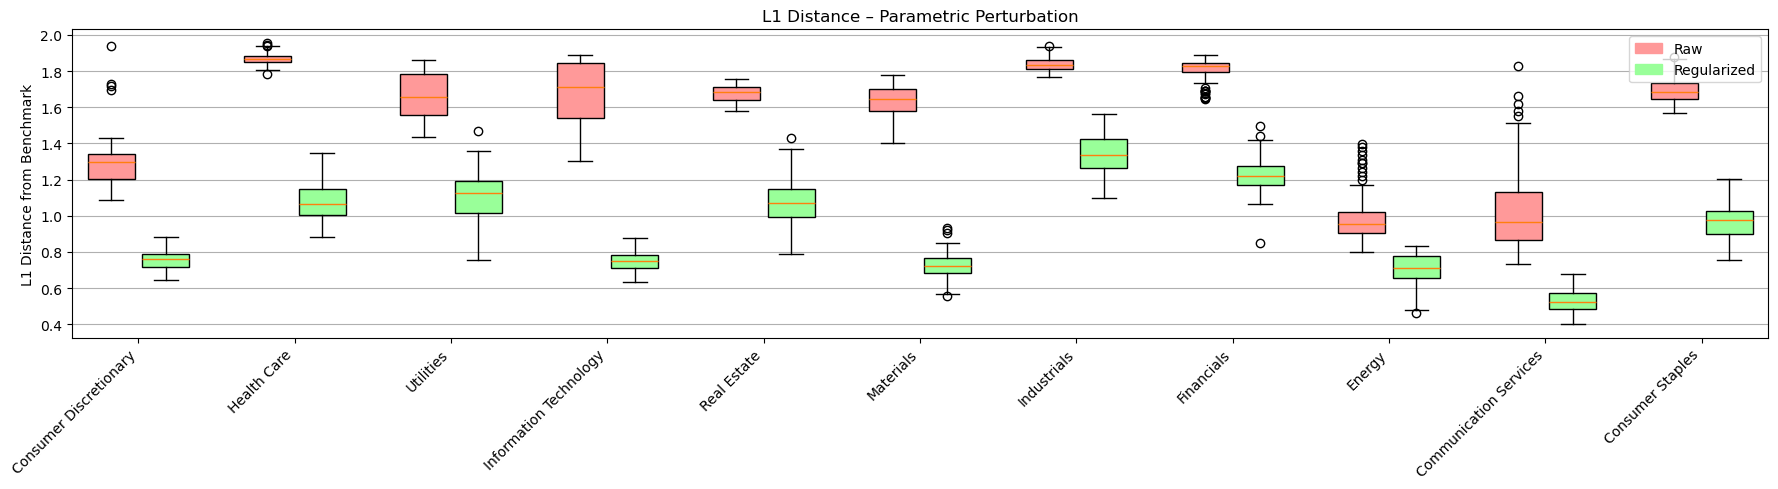

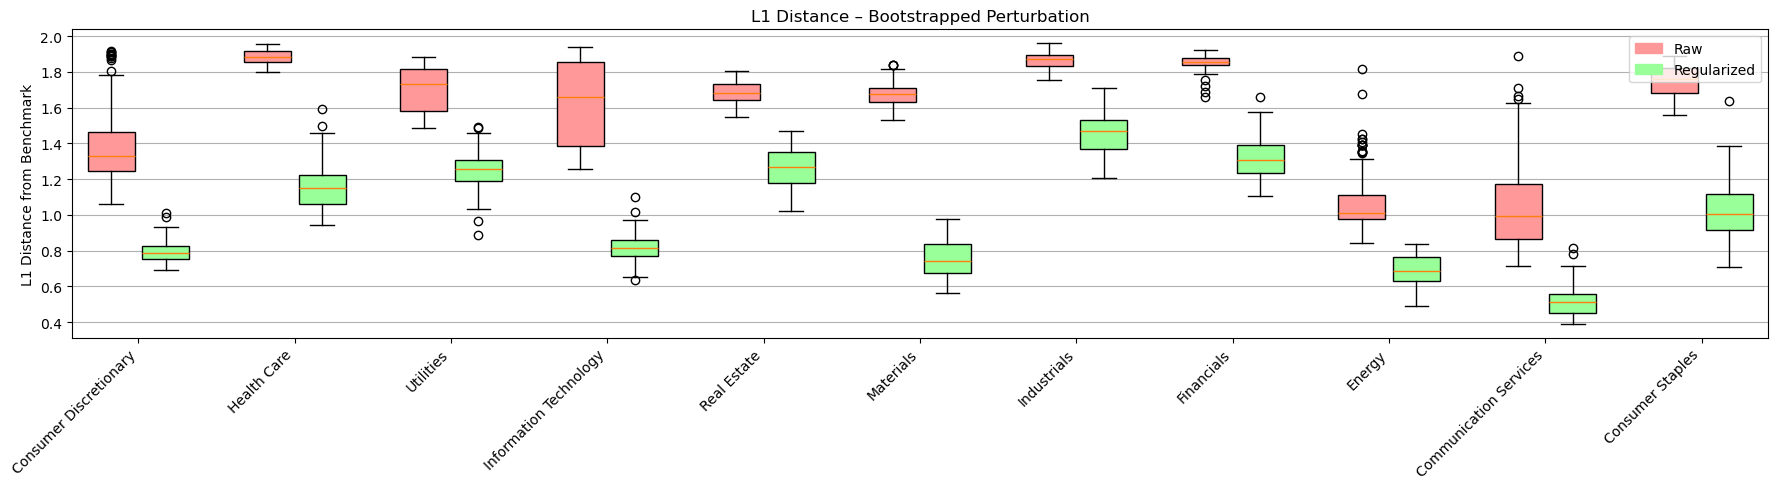

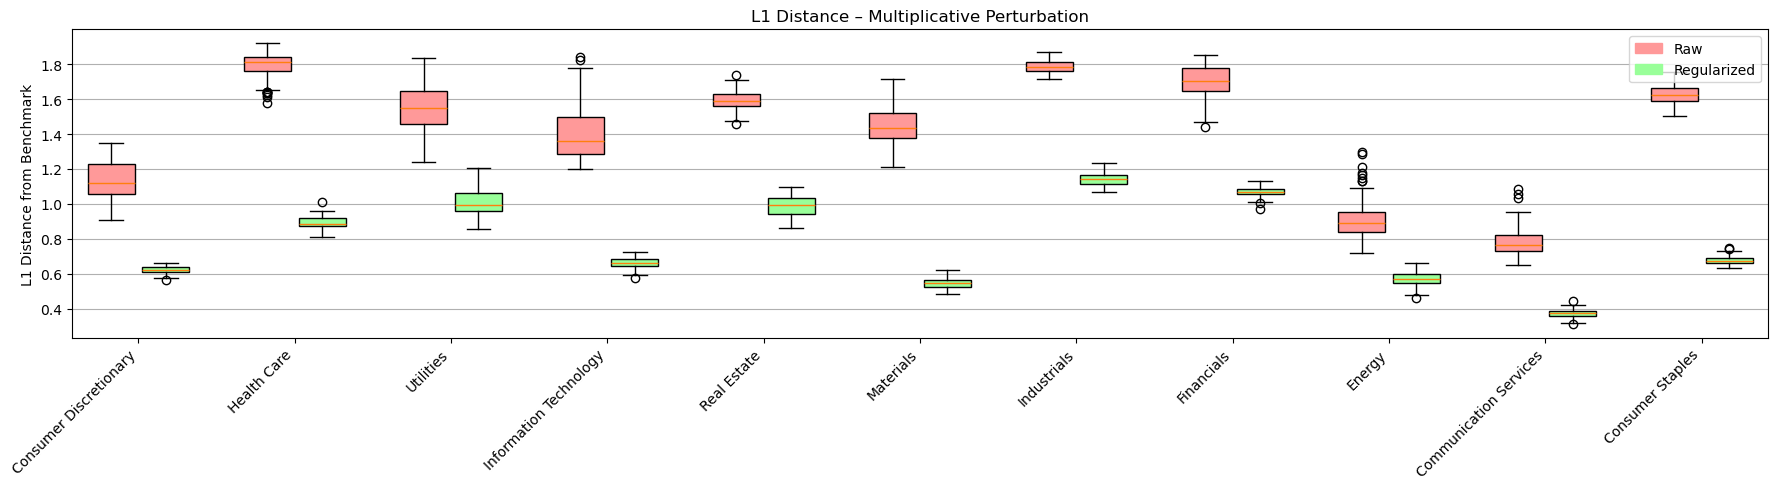

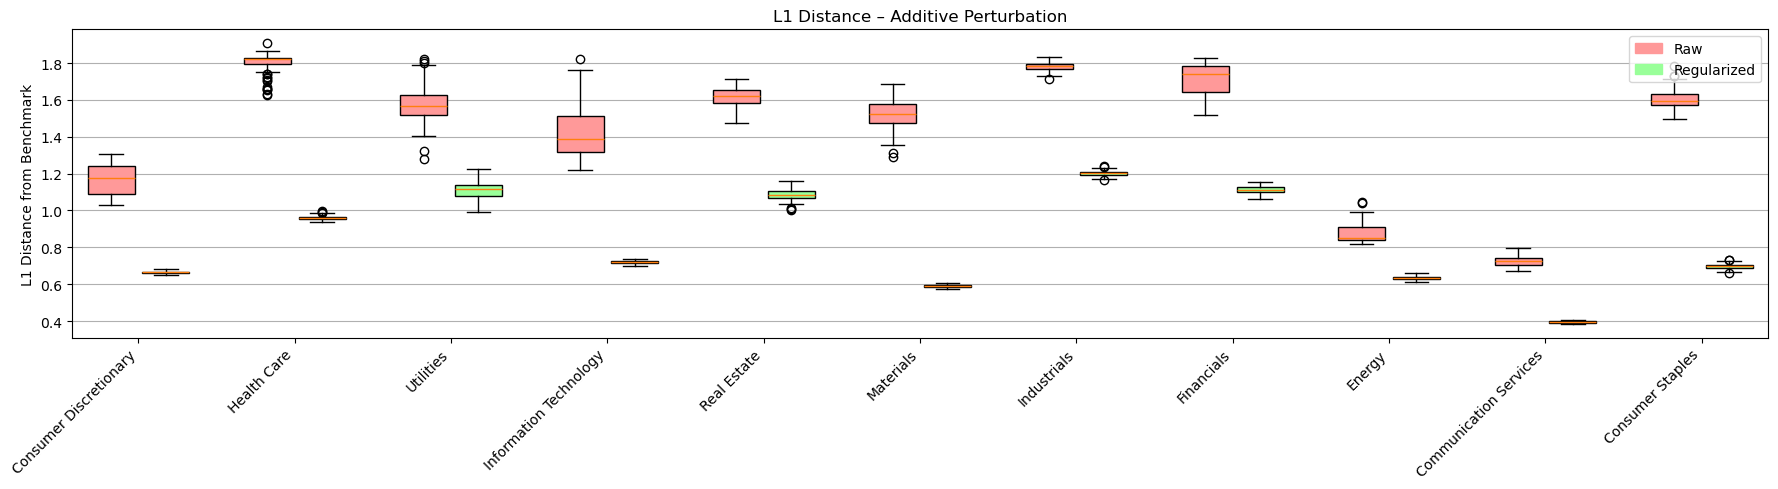

In [32]:
def plot_l1_boxplot(sector_weights, sectors, noise_type, title):
    fig, ax = plt.subplots(figsize=(18, 5))
    positions = []
    data = []
    colors = []
    labels = []

    for i, sector in enumerate(sectors):
        data.extend([
            sector_weights[sector][f"l1_{noise_type}_raw"],
            sector_weights[sector][f"l1_{noise_type}_reg"]
        ])
        positions.extend([2 * i, 2 * i + 0.7])
        colors.extend(['#FF9999', '#99FF99'])
        labels.extend([f"{sector}\nRaw", "Reg"])

    box = ax.boxplot(data, positions=positions, patch_artist=True, widths=0.6)
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)

    # X-axis formatting
    ax.set_xticks([2 * i + 0.35 for i in range(len(sectors))])
    ax.set_xticklabels(sectors, rotation=45, ha='right')

    # Labels & title
    ax.set_title(f"L1 Distance – {title}")
    ax.set_ylabel("L1 Distance from Benchmark")
    ax.grid(True, axis='y')

    # Legend
    legend_patches = [
        Patch(color='#FF9999', label='Raw'),
        Patch(color='#99FF99', label='Regularized')
    ]
    ax.legend(handles=legend_patches, loc='upper right')

    plt.tight_layout()
    plt.show()

# Usage
sectors = list(sector_weights.keys())
# Captures joint distribution if estimation is accurate
plot_l1_boxplot(sector_weights, sectors, noise_type="param", title="Parametric Perturbation")
# Non-parametric, respects empirical distribution
plot_l1_boxplot(sector_weights, sectors, noise_type="boot", title="Bootstrapped Perturbation")
# Noise is return-scaled, but not volatility-aware
plot_l1_boxplot(sector_weights, sectors, noise_type="mult", title="Multiplicative Perturbation")
# Adds uniform noise regardless of asset properties
plot_l1_boxplot(sector_weights, sectors, noise_type="add", title="Additive Perturbation")



# to do: hierarchical clustering

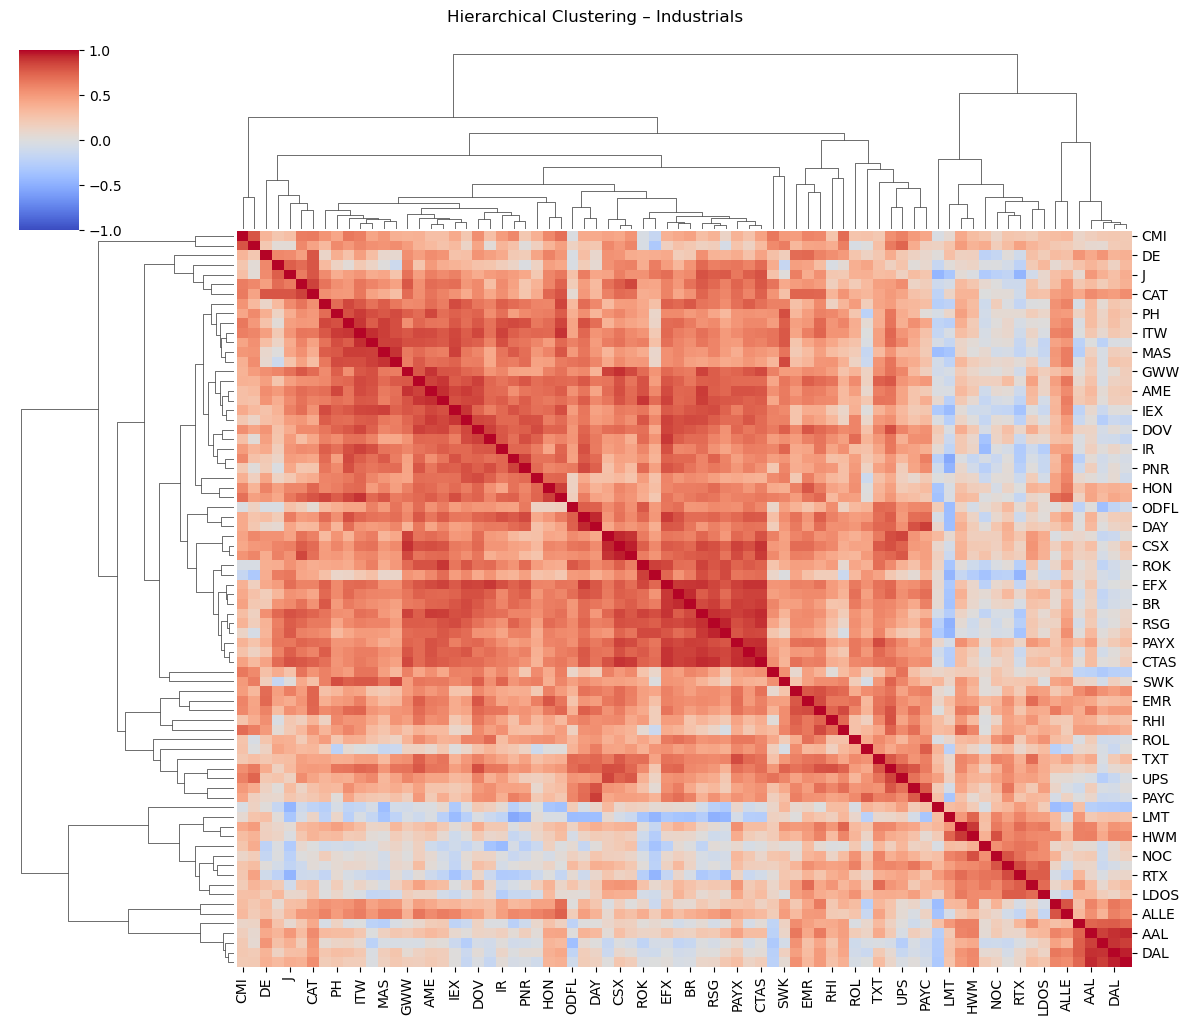

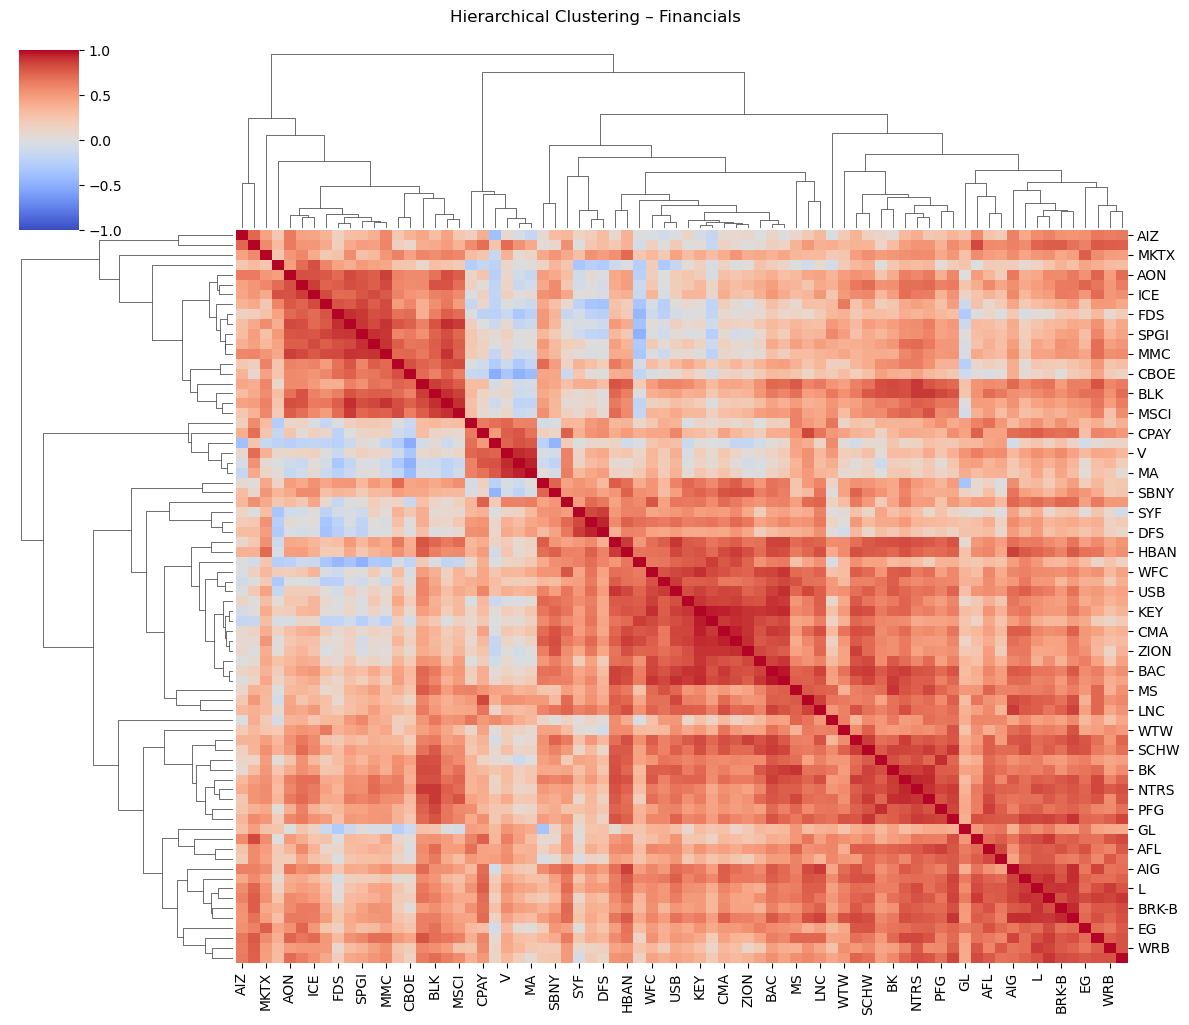

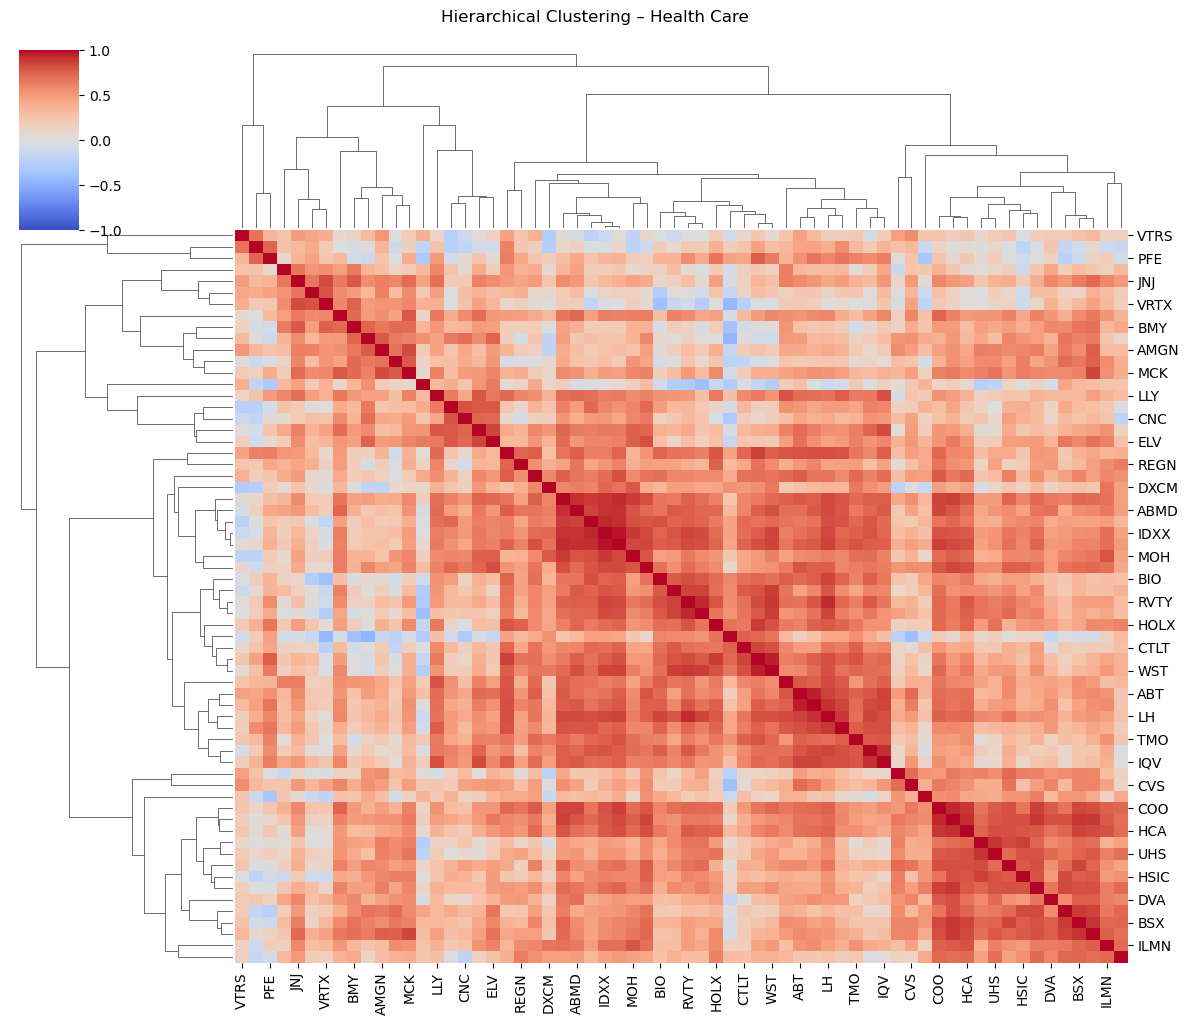

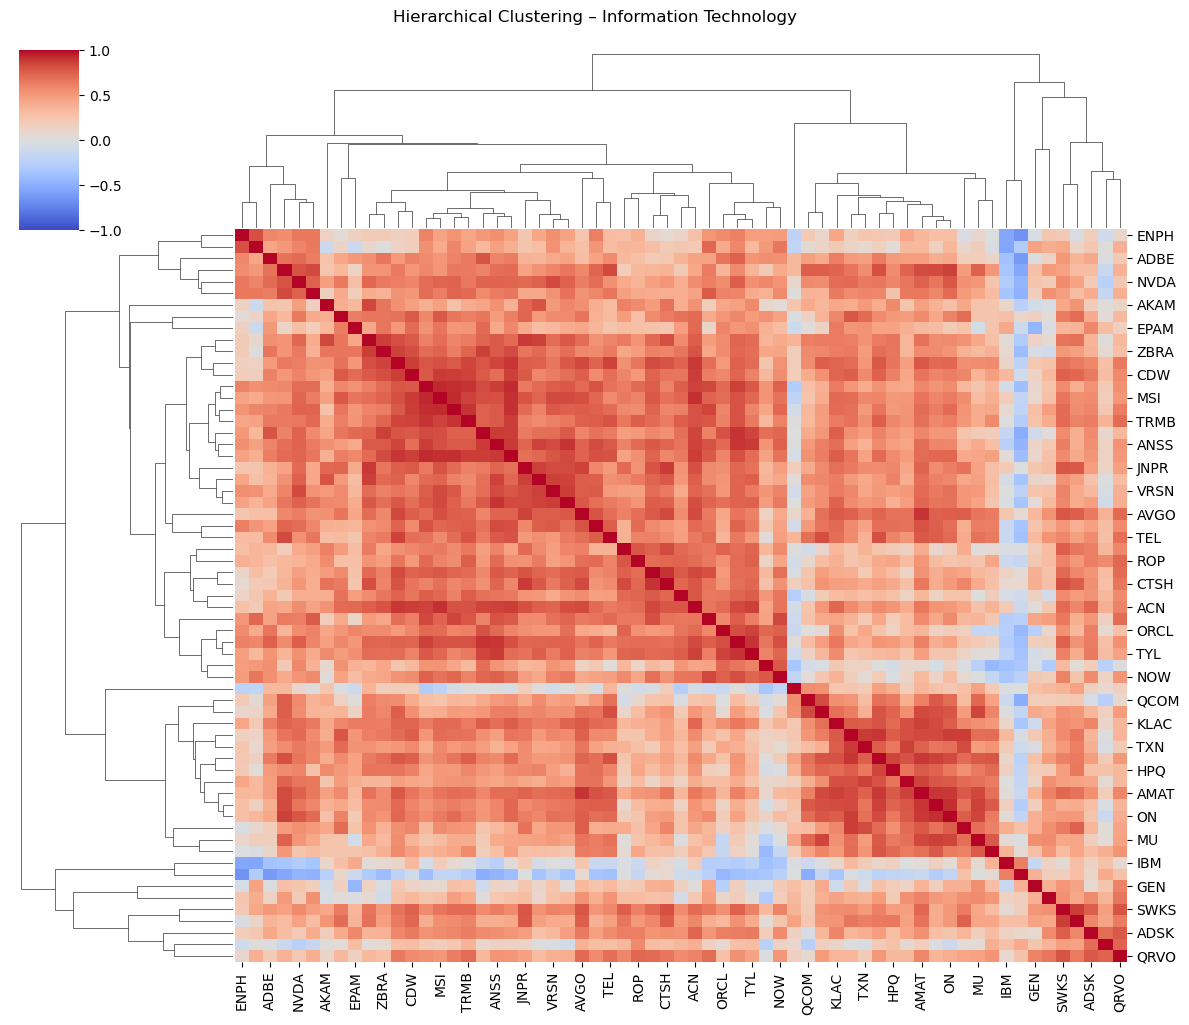

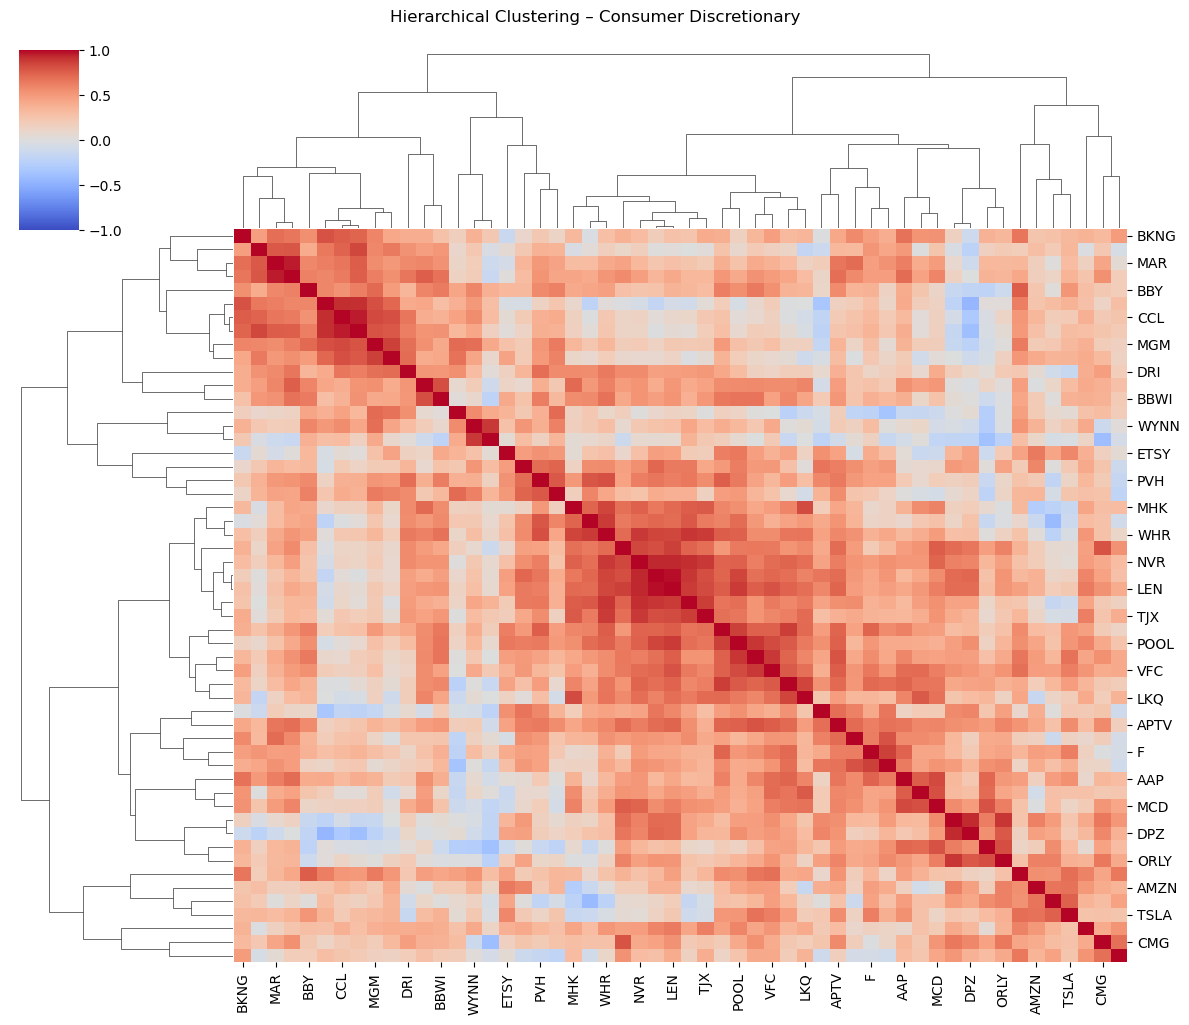

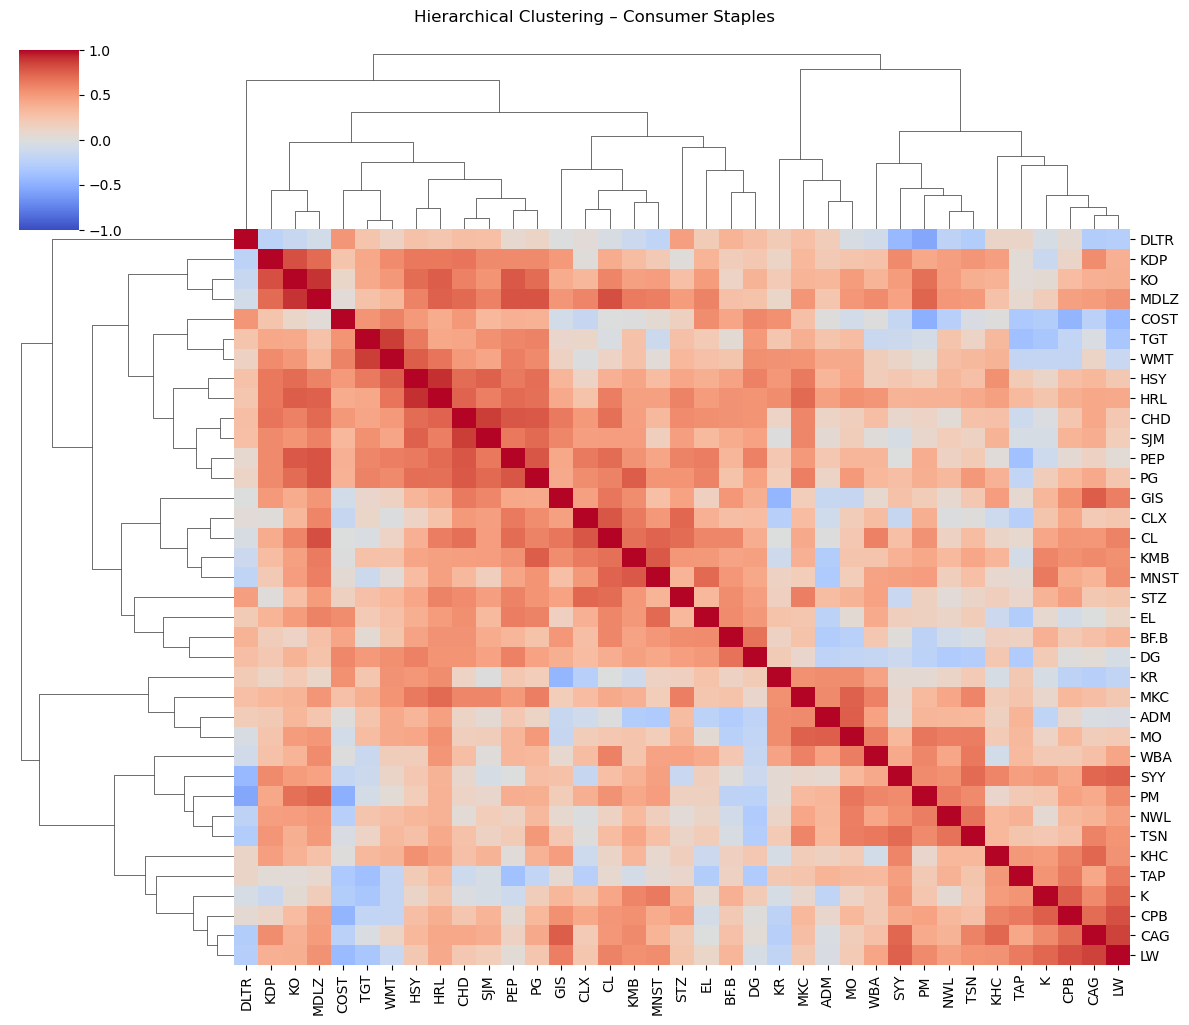

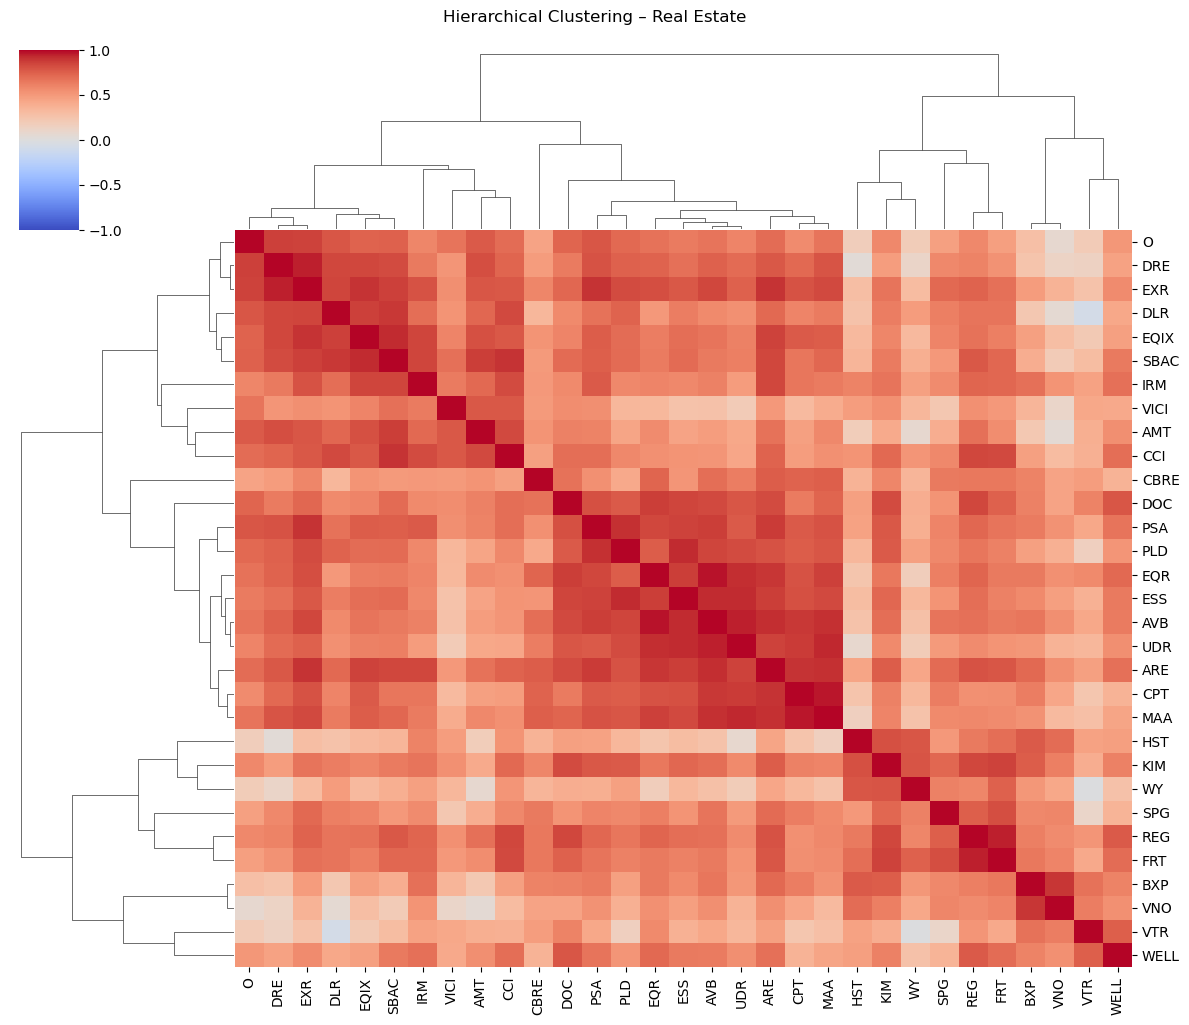

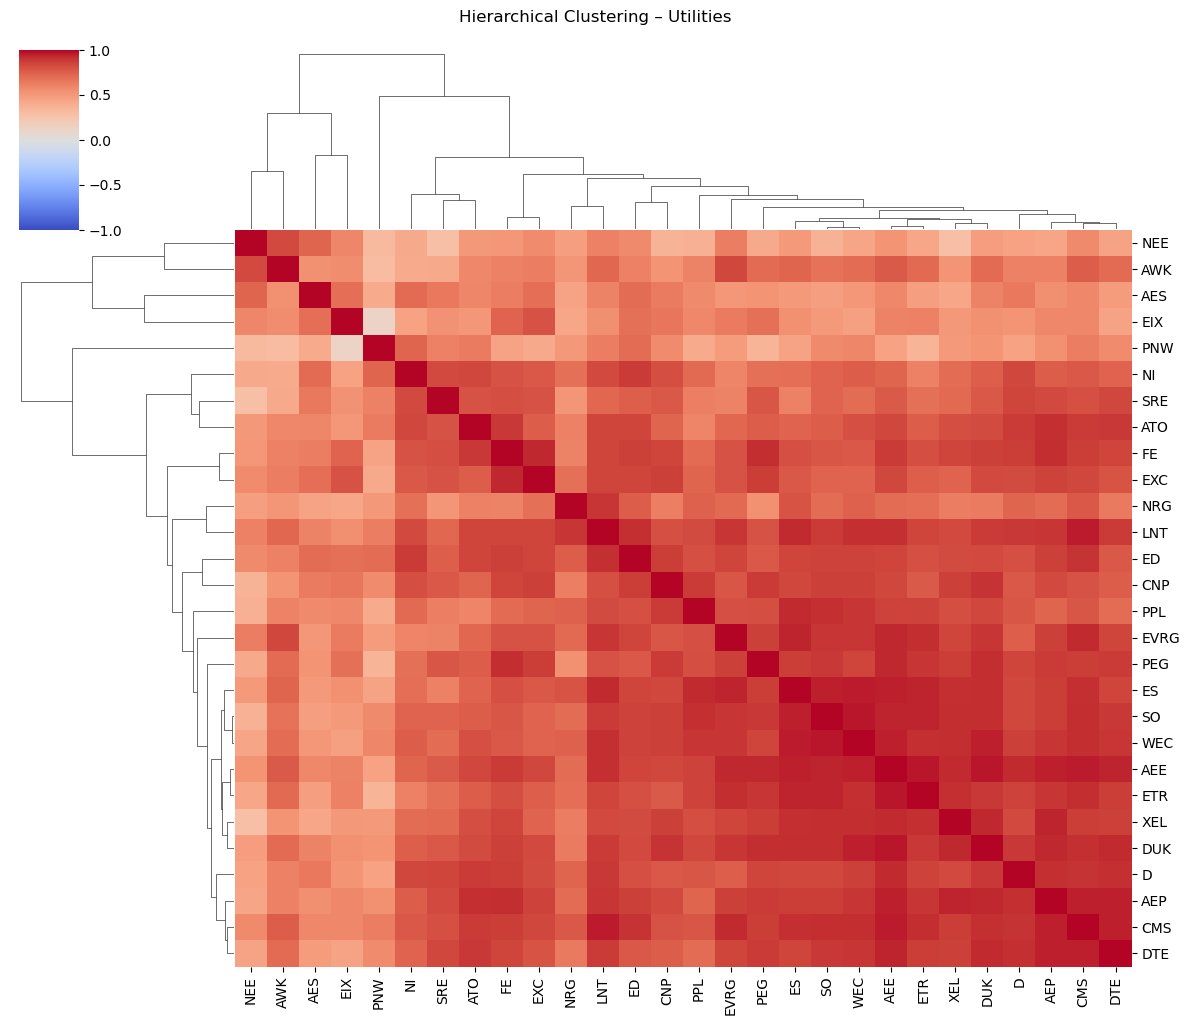

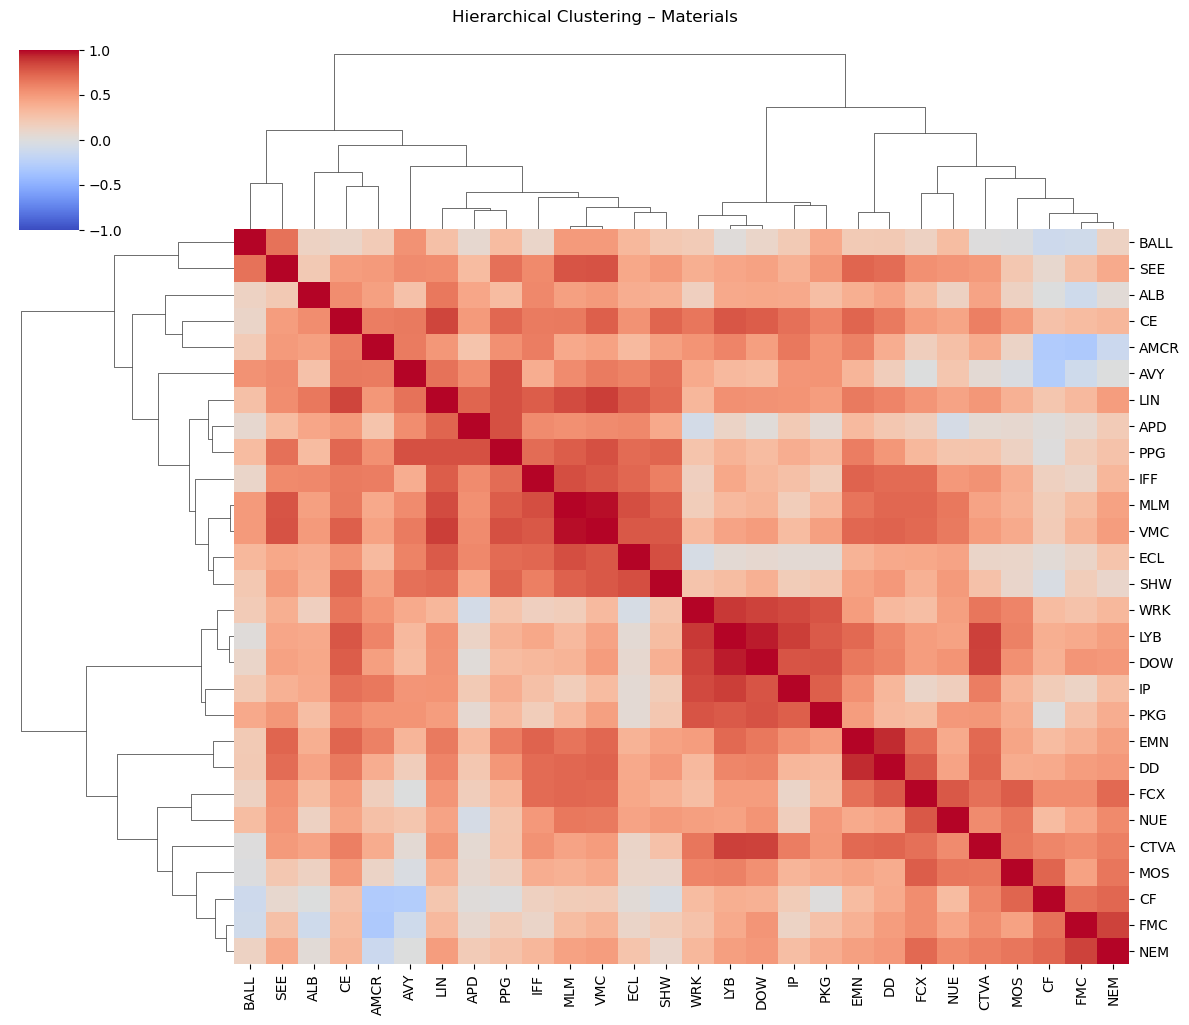

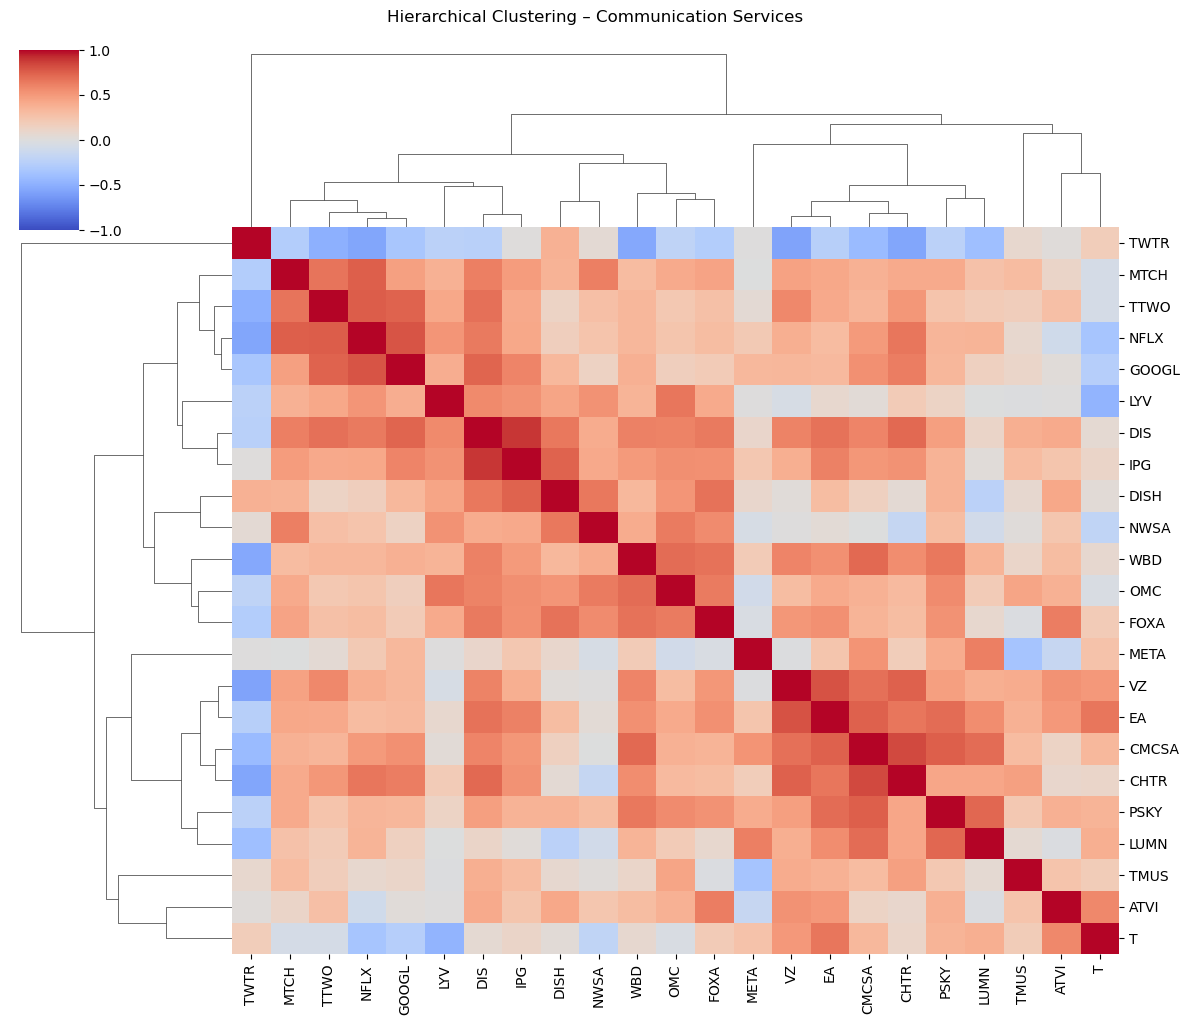

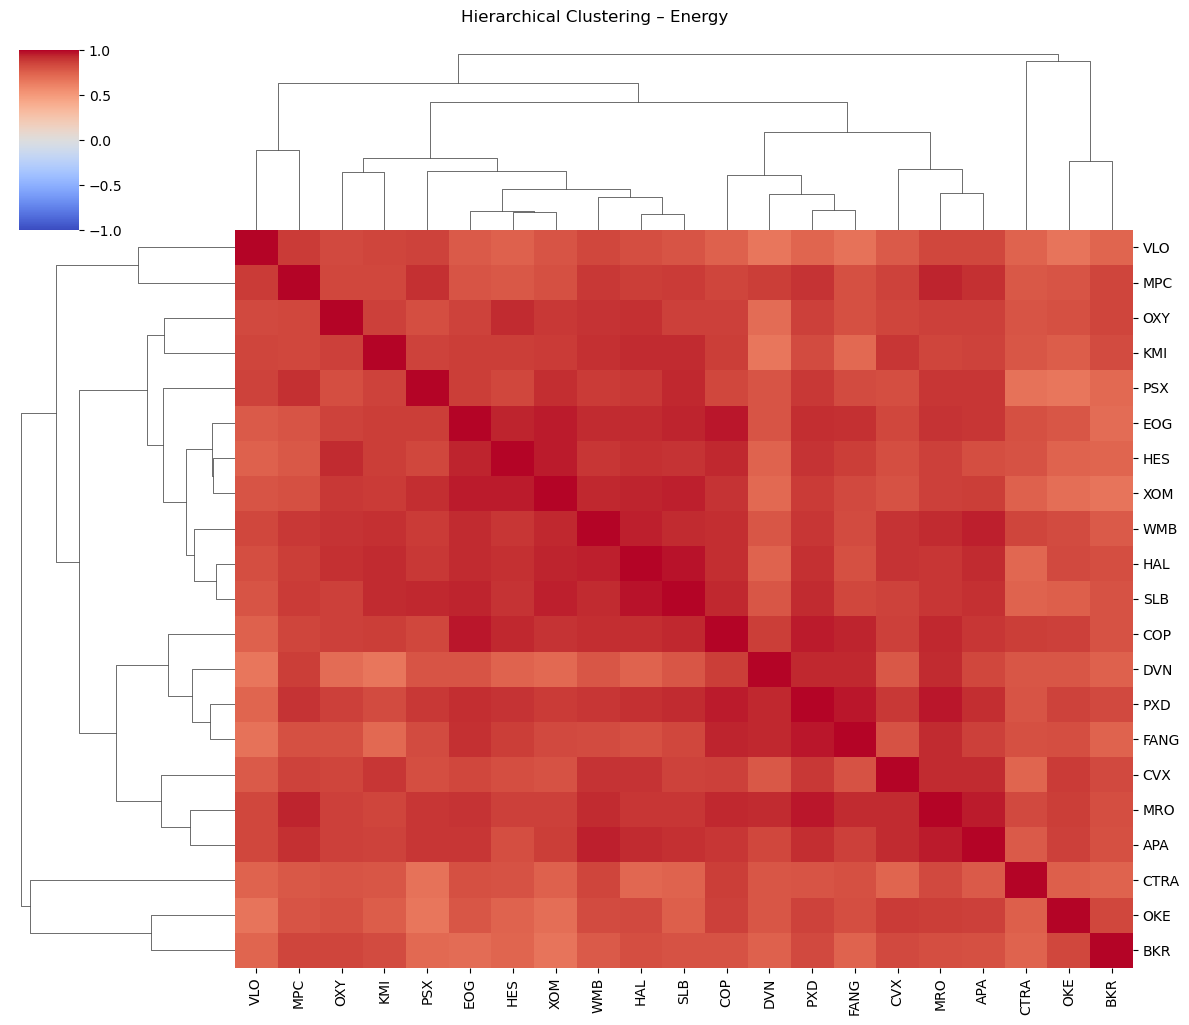

In [33]:
# Load dataset to count stocks per sector
data = pd.read_excel("Data/out-of-sample/dataset_comp_0622.xlsx")

# Count number of stocks per sector
sector_stock_counts = {
    sector: data[data['GICS Sector'] == sector]['SYMBOL'].nunique()
    for sector in data['GICS Sector'].unique()
}

# Sort sectors by number of stocks descending
sorted_sectors = sorted(sector_stock_counts.items(), key=lambda x: x[1], reverse=True)

# Loop through sorted sectors
for sector_name, _ in sorted_sectors:
    # Load returns
    R = pd.read_excel("Data/out-of-sample/sector_log_returns_comp_0622.xlsx", sheet_name=sector_name)
    R_clean = R.drop(columns=['Date']).dropna()

    # Compute correlation matrix
    corr_matrix = R_clean.corr()

    # Use seaborn clustermap with hierarchical clustering
    g = sns.clustermap(
        corr_matrix,
        method='average',           # you can try 'complete', 'ward', etc.
        metric='correlation',       # distance = 1 - corr
        cmap='coolwarm',
        center=0,
        vmin=-1, vmax=1,
        figsize=(12, 10)
    )

    # Set title
    g.fig.suptitle(f"Hierarchical Clustering – {sector_name}", y=1.02)

    plt.show()


Lower correlation means better diversification and so the overall portfolio risk can be reduce. However, excessively low correlations may be a sign of modeling noise and on the other hand, if secors have high correlations but uniform then the covariance matrix might be less fragile. In fact if we look at what happens after shrinking the covariance matrix for the Energy sector (a sector with strong and uniform correlations) the L1 distance boxplot was already narrow before the regularisation and keeps the same length after regularisation. While for Communication Services a sector with lower correlations, the shrinkage narrowes significantly the L1 distance boxplot, meaning that the inputs sensitivity is reduced. 

In [34]:

for sector_name in data['GICS Sector'].unique():
    R = pd.read_excel("Data/out-of-sample/sector_log_returns_comp_0622.xlsx", sheet_name=sector_name)
    R_clean = R.drop(columns=['Date']).dropna()
    R_np = R_clean.values
    mu_hat = R_np.mean(axis=0)
    Sigma_hat = np.cov(R_np, rowvar=False)
    T = R_np.shape[0]
    print(mu_hat.shape)
    print(Sigma_hat.shape)
    print(sector_name, mu_hat.mean(), Sigma_hat.mean())

(54,)
(54, 54)
Consumer Discretionary -0.025398049288626504 0.0031272163127485427
(64,)
(64, 64)
Health Care -0.006860965287365706 0.003147081513410908
(28,)
(28, 28)
Utilities 0.01085713266834205 0.0028854987737055283
(63,)
(63, 63)
Information Technology -0.015162267756978813 0.004338126562135357
(31,)
(31, 31)
Real Estate -0.002979009814580515 0.003448477419914484
(28,)
(28, 28)
Materials -0.005442184381711403 0.0035492441029969513
(76,)
(76, 76)
Industrials -0.011656255592643138 0.0024037312604393984
(74,)
(74, 74)
Financials -0.008864208406736865 0.002480040413180514
(21,)
(21, 21)
Energy 0.02605914172298411 0.012193298228064541
(23,)
(23, 23)
Communication Services -0.02882505196572558 0.0030917108396328967
(37,)
(37, 37)
Consumer Staples 0.003067753979791256 0.0011559439858230738


In [35]:
def plot_te_boxplot(sector_weights, sectors, noise_type, title):
    fig, ax = plt.subplots(figsize=(18, 5))
    positions = []
    data = []
    colors = []

    for i, sector in enumerate(sectors):
        data.extend([
            sector_weights[sector][f"te_{noise_type}_raw"],
            sector_weights[sector][f"te_{noise_type}_reg"]
        ])
        positions.extend([2 * i, 2 * i + 0.7])
        colors.extend(['#87CEEB', '#4682B4'])  # Light/dark blue for raw/regularized

    box = ax.boxplot(data, positions=positions, patch_artist=True, widths=0.6)
  
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)

    ax.set_xticks([2 * i + 0.35 for i in range(len(sectors))])
    ax.set_xticklabels(sectors, rotation=45, ha='right')
    ax.set_title(f"Realized Tracking Error – {title}")
    ax.set_ylabel("Tracking Error (Annualized)")
    ax.set_ylim(0.02999, 0.03001)
    ax.ticklabel_format(style='plain', axis='y')

    ax.grid(True, axis='y')

    legend_patches = [
        Patch(color='#87CEEB', label='Raw'),
        Patch(color='#4682B4', label='Regularized')
    ]
    ax.legend(handles=legend_patches, loc='upper right')

    plt.tight_layout()
    plt.show()


In [36]:
for sector_name in sectors:
    print(np.mean(sector_weights[sector_name]['te_param_reg']))

for sector_name in sectors:
    print(np.mean(sector_weights[sector_name]['te_boot_reg']))

for sector_name in sectors:
    print(np.mean(sector_weights[sector_name]['te_mult_reg']))

for sector_name in sectors:
    print(np.mean(sector_weights[sector_name]['te_add_reg']))


for sector_name in sectors:
    print(np.mean(sector_weights[sector_name]['te_param_raw']))

for sector_name in sectors:
    print(np.mean(sector_weights[sector_name]['te_boot_raw']))

for sector_name in sectors:
    print(np.mean(sector_weights[sector_name]['te_mult_raw']))

for sector_name in sectors:
    print(np.mean(sector_weights[sector_name]['te_add_raw']))


0.030000040685456406
0.030000038843087738
0.030000012760938603
0.030000028169771133
0.030000037953942685
0.030000031854302552
0.030000005222663915
0.029999992020152577
0.030000049087432087
0.030000024301276604
0.030000018482239037
0.030000029972198545
0.030000027127423893
0.030000012058893445
0.030000026667725353
0.0300000328422564
0.030000029855895206
0.02999998723906828
0.030000003046397675
0.030000050964359266
0.030000021083576772
0.030000018339430907
0.030000022091993463
0.030000030944648457
0.030000017813173633
0.030000018309639255
0.030000038039274132
0.0300000356868781
0.030000009884280306
0.029999979774621016
0.030000033962326454
0.030000011088598563
0.030000012710046698
0.030000018289471228
0.030000030042498498
0.03000001743830939
0.03000002188085087
0.03000004266147451
0.03000002017607411
0.0300000133766135
0.030000000452593684
0.0300000411815685
0.030000011457565205
0.030000011038475362
0.03000001186600484
0.030000005197826102
0.030000011524304364
0.030000009699942255
0.0300

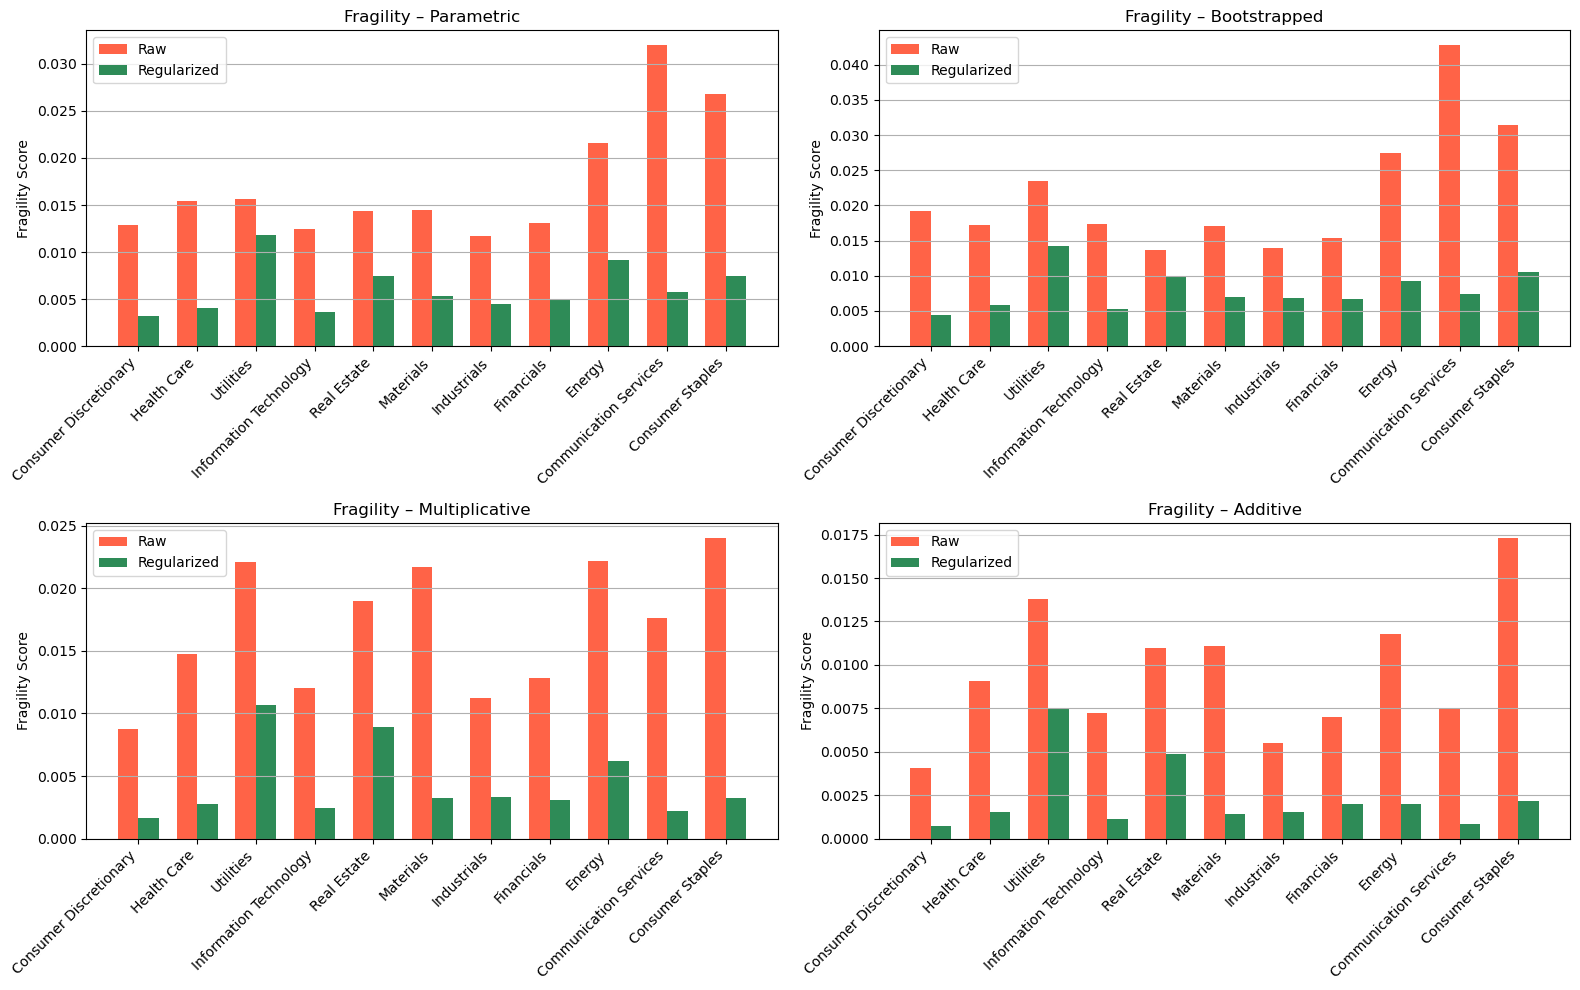

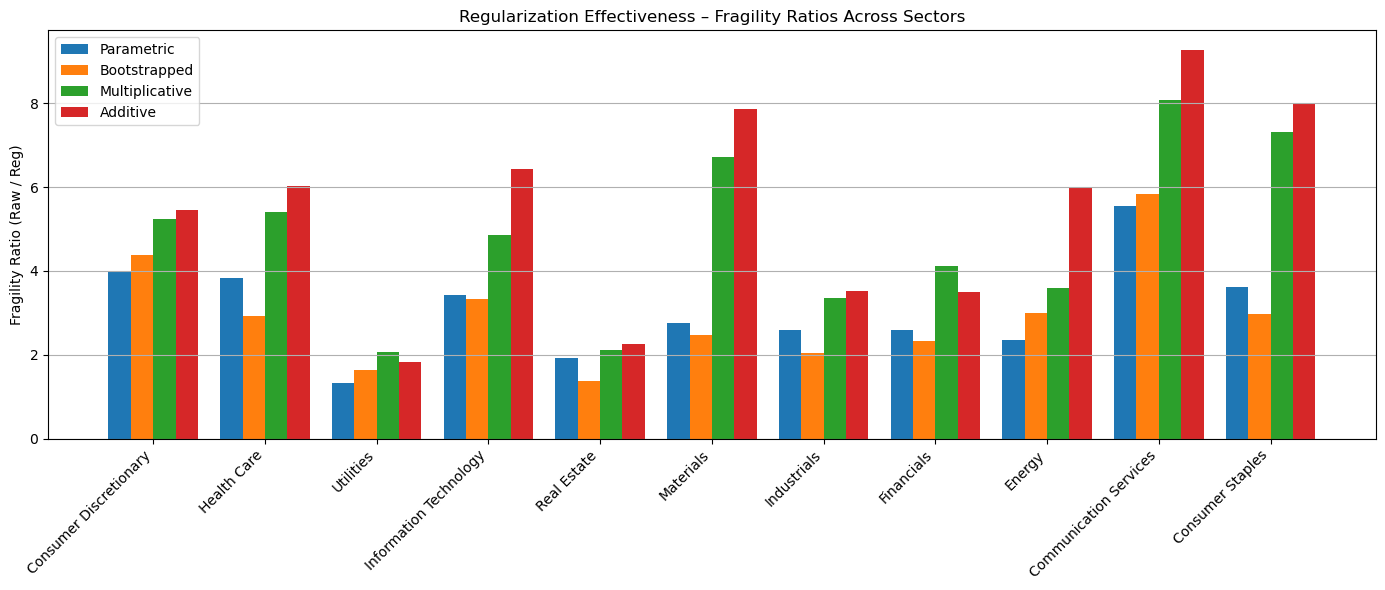

In [37]:
frag_raw_all = {"param": [], "boot": [], "mult": [], "add": []}
frag_reg_all = {"param": [], "boot": [], "mult": [], "add": []}
frag_ratio_all = {"param": [], "boot": [], "mult": [], "add": []}

sectors = list(sector_weights.keys())
for sector in sectors:
    for noise_type in ["param", "boot", "mult", "add"]:
        frag_raw_all[noise_type].append(sector_weights[sector][f"frag_{noise_type}_raw"])
        frag_reg_all[noise_type].append(sector_weights[sector][f"frag_{noise_type}_reg"])
        frag_ratio_all[noise_type].append(sector_weights[sector][f"frag_ratio_{noise_type}"])

# Plot Fragility (Raw vs Reg)
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
noise_labels = ["param", "boot", "mult", "add"]
titles = ["Parametric", "Bootstrapped", "Multiplicative", "Additive"]

for i, noise_type in enumerate(noise_labels):
    ax = axs[i // 2, i % 2]
    x = np.arange(len(sectors))
    width = 0.35

    ax.bar(x - width/2, frag_raw_all[noise_type], width, label='Raw', color='tomato')
    ax.bar(x + width/2, frag_reg_all[noise_type], width, label='Regularized', color='seagreen')
    ax.set_xticks(x)
    ax.set_xticklabels(sectors, rotation=45, ha='right')
    ax.set_ylabel("Fragility Score")
    ax.set_title(f"Fragility – {titles[i]}")
    ax.legend()
    ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

# Plot Fragility Ratios
fig, ax = plt.subplots(figsize=(14, 6))

width = 0.2
x = np.arange(len(sectors))

for i, noise_type in enumerate(noise_labels):
    offset = (i - 1.5) * width
    ax.bar(x + offset, frag_ratio_all[noise_type], width, label=titles[i])

ax.set_xticks(x)
ax.set_xticklabels(sectors, rotation=45, ha='right')
ax.set_ylabel("Fragility Ratio (Raw / Reg)")
ax.set_title("Regularization Effectiveness – Fragility Ratios Across Sectors")
ax.legend()
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

So what happens for Consumer Staples?
1. Regularization shrinks the weight variability
- Each individual asset weight is more tightly concentrated across trials. That means fragility (weight-level std deviation) is lower.

2. But it may allow small, coordinated shifts away from benchmark
- Those smaller deviations may consistently be in different directions across trials. So while the overall size of deviation is small, the L1 distance from benchmark still varies more.

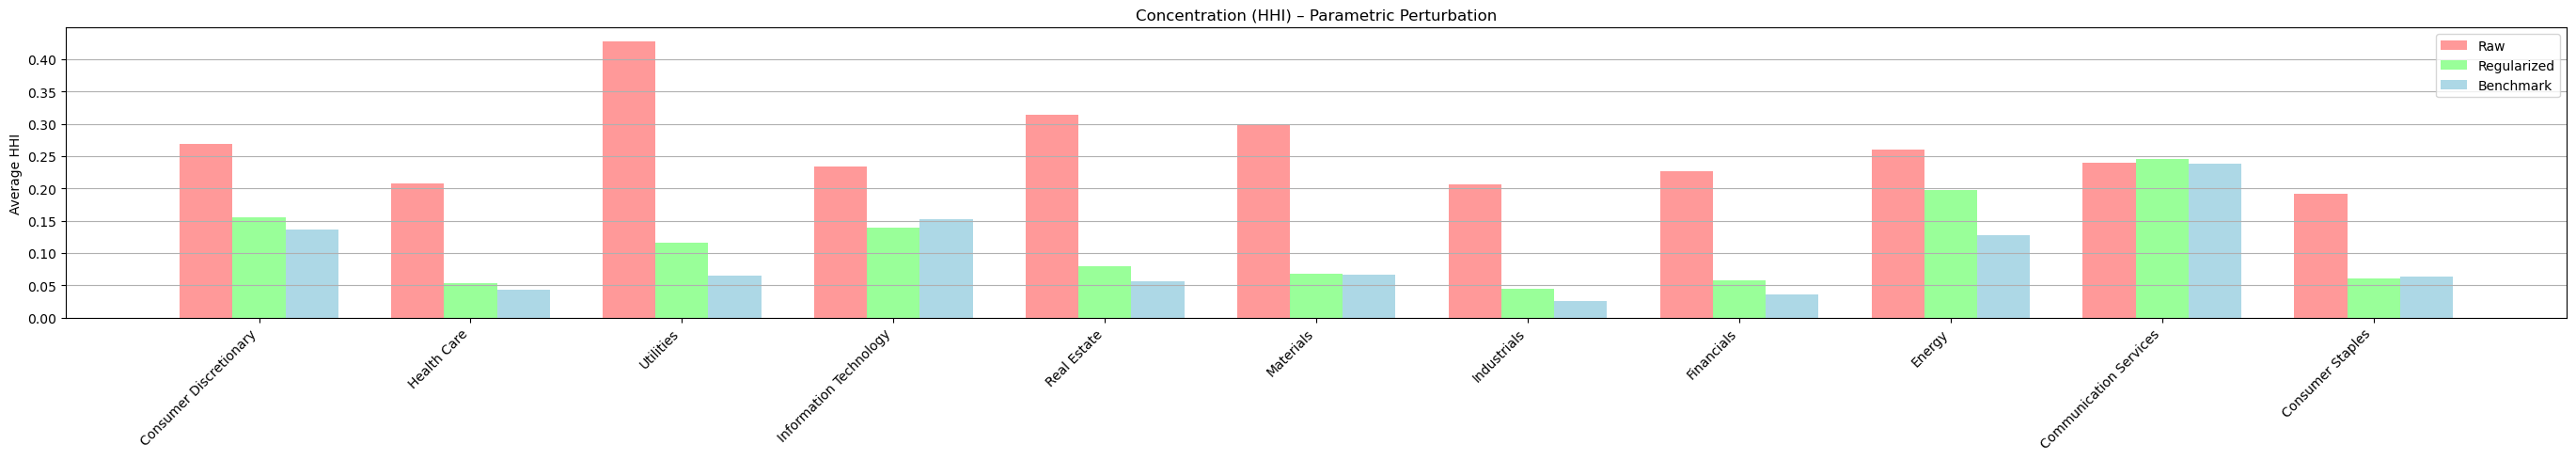

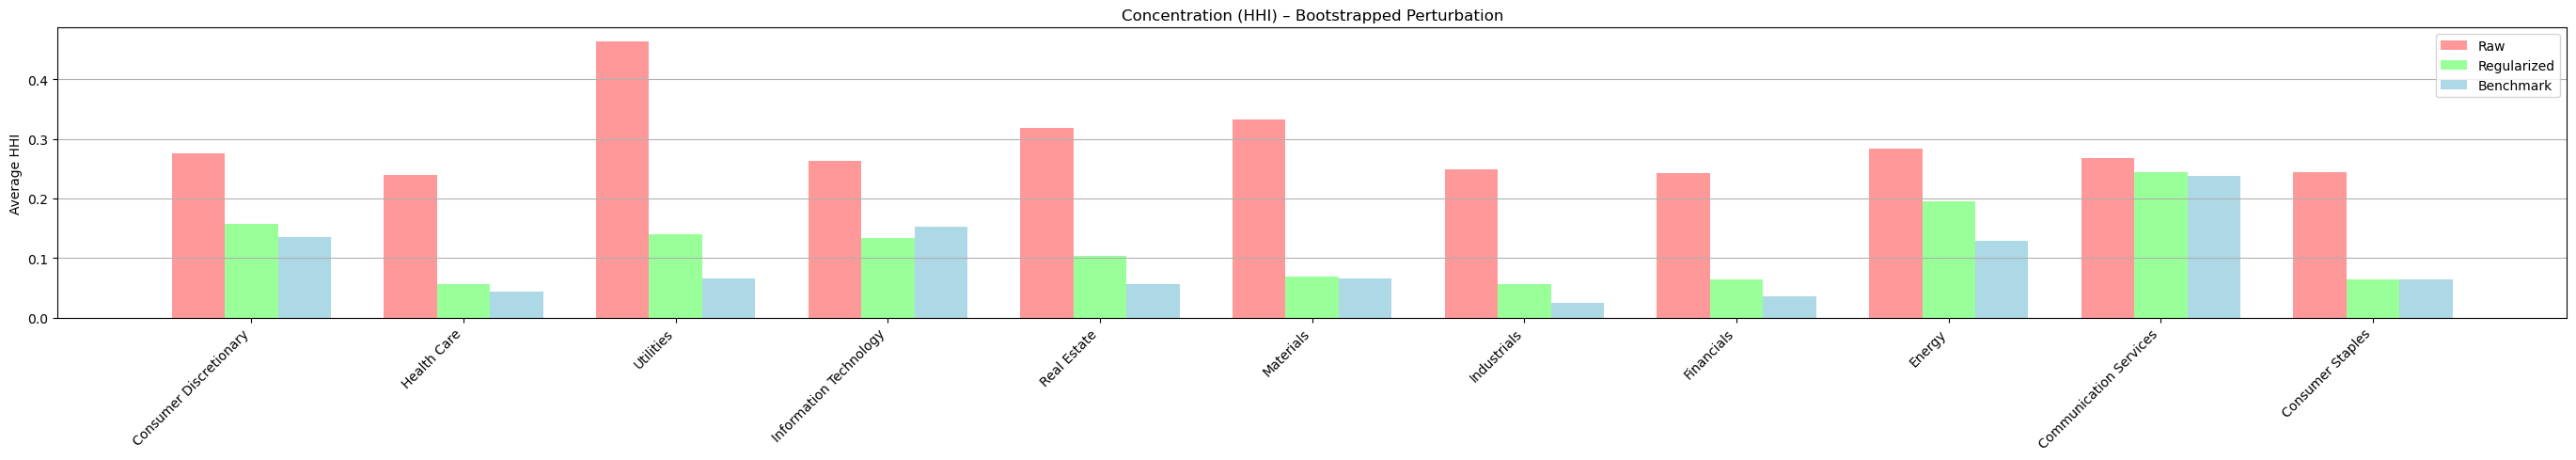

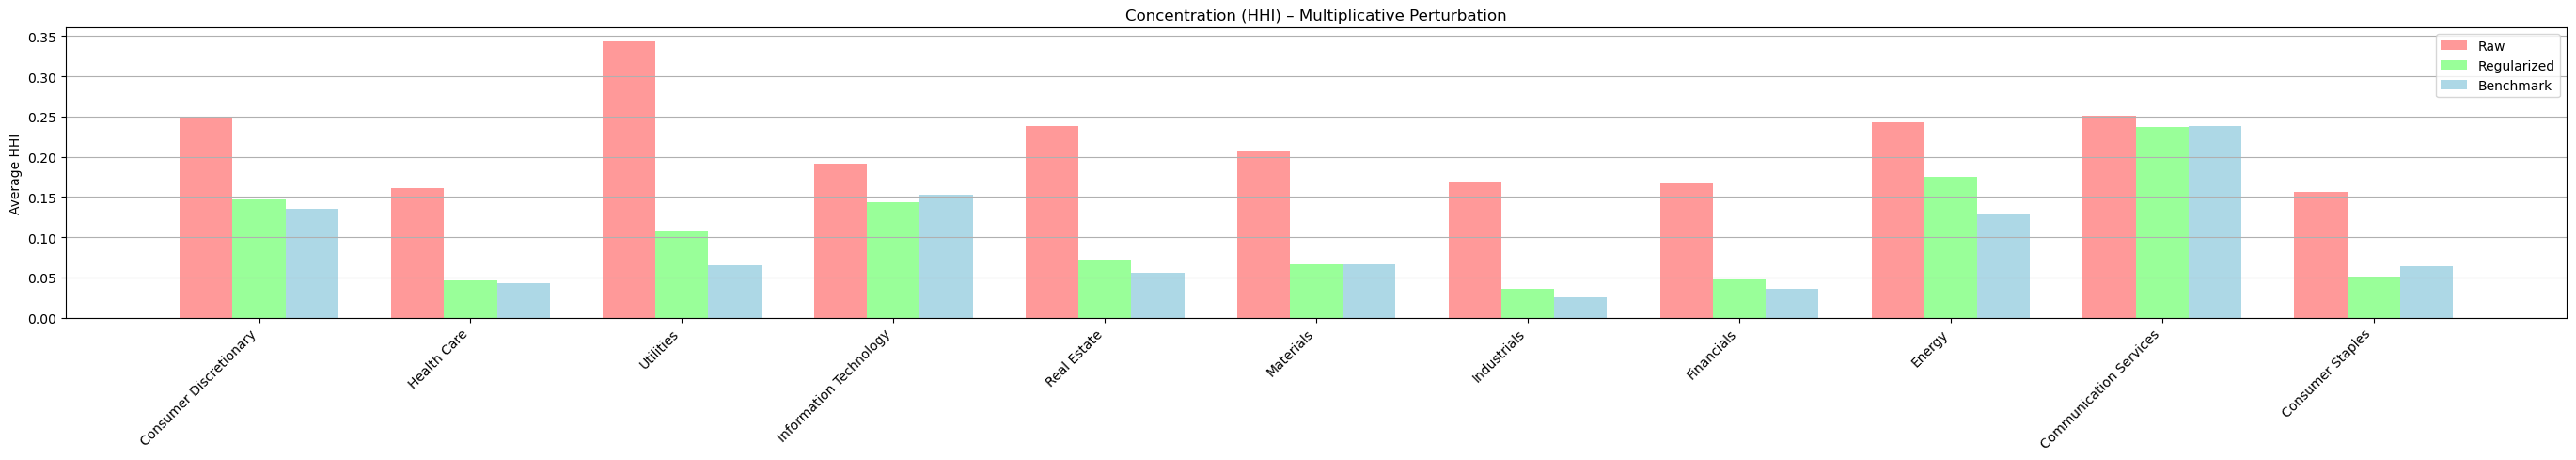

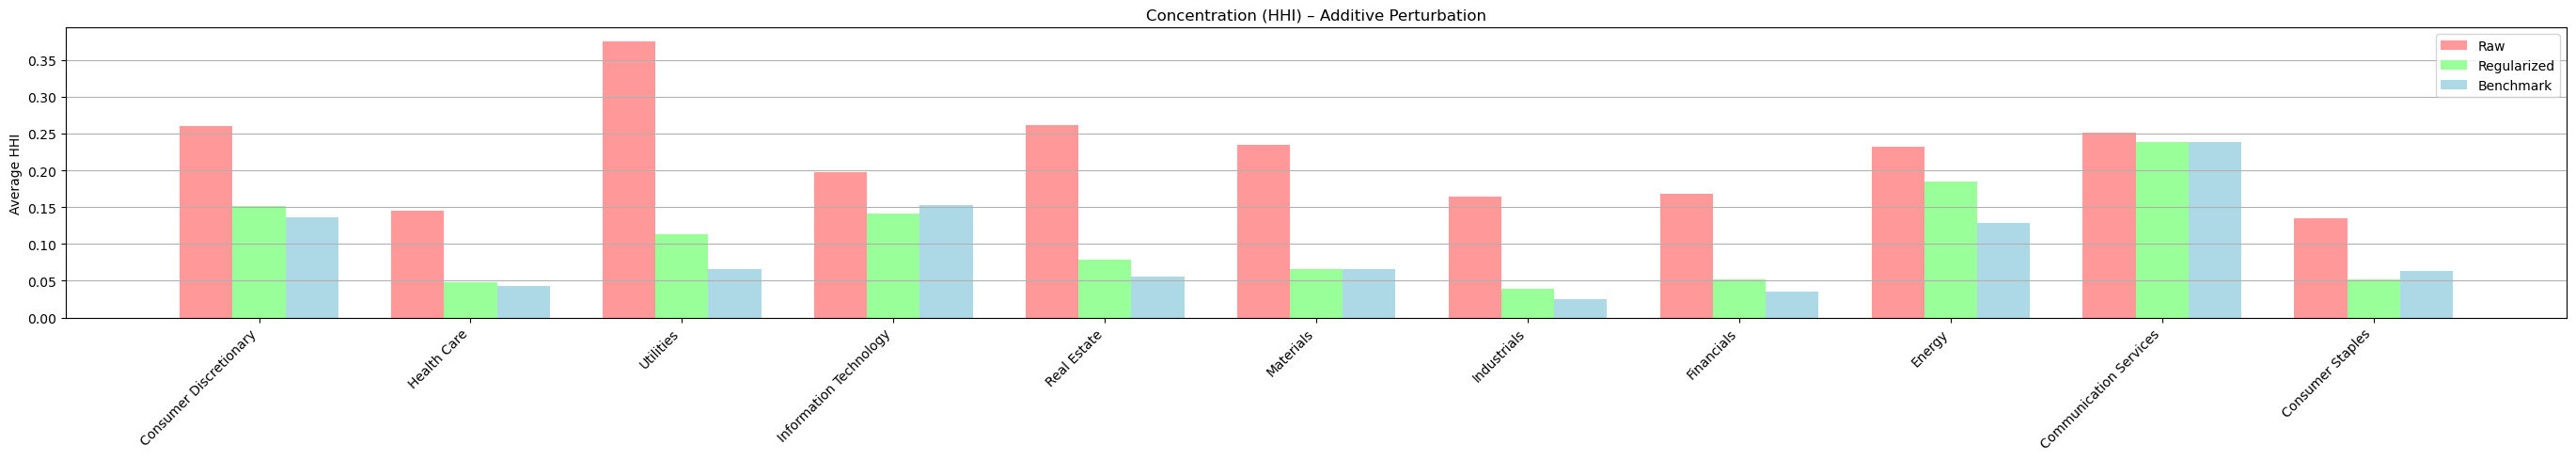

In [38]:
def plot_hhi_bars(sector_weights, sectors, noise_type, title):
    hhi_raw = []
    hhi_reg = []
    hhi_benchmark = []

    for sector in sectors:
        hhi_raw.append(sector_weights[sector][f"hhi_{noise_type}_raw"])
        hhi_reg.append(sector_weights[sector][f"hhi_{noise_type}_reg"])
        hhi_benchmark.append(sector_weights[sector]["hhi_benchmark"])

    x = np.arange(len(sectors))
    width = 0.25  # Narrower to fit 3 bars

    fig, ax = plt.subplots(figsize=(2.5 * len(sectors), 5))

    ax.bar(x - width, hhi_raw, width, label='Raw', color='#FF9999')
    ax.bar(x, hhi_reg, width, label='Regularized', color='#99FF99')
    ax.bar(x + width, hhi_benchmark, width, label='Benchmark', color='#ADD8E6')

    ax.set_xticks(x)
    ax.set_xticklabels(sectors, rotation=45, ha='right')
    ax.set_ylabel("Average HHI")
    ax.set_title(f"Concentration (HHI) – {title}")
    ax.legend()
    ax.grid(True, axis='y')

    plt.tight_layout()
    plt.show()

sectors = list(sector_weights.keys())

plot_hhi_bars(sector_weights, sectors, noise_type="param", title="Parametric Perturbation")
plot_hhi_bars(sector_weights, sectors, noise_type="boot", title="Bootstrapped Perturbation")
plot_hhi_bars(sector_weights, sectors, noise_type="mult", title="Multiplicative Perturbation")
plot_hhi_bars(sector_weights, sectors, noise_type="add", title="Additive Perturbation")

In [39]:
optimal_portfolios_shrink['Consumer Discretionary']

{'w_b_vec': array([0.29414484, 0.01139568, 0.00437555, 0.00942822, 0.00216717,
        0.01284834, 0.00606843, 0.00399128, 0.00760013, 0.00574228,
        0.0031311 , 0.09183323, 0.00529498, 0.00238522, 0.03636962,
        0.00341909, 0.0537926 , 0.0020821 , 0.01423344, 0.00404001,
        0.04224374, 0.00146344, 0.00304773, 0.00697691, 0.00212474,
        0.00429806, 0.00333633, 0.02660445, 0.00666706, 0.00426074,
        0.00269598, 0.00166507, 0.00442361, 0.00438551, 0.02131807,
        0.00402672, 0.00360351, 0.01075603, 0.00645187, 0.00124555,
        0.00407144, 0.00110801, 0.17673641, 0.01246122, 0.01413356,
        0.00451068, 0.00700848, 0.00122977, 0.02287616, 0.00259725,
        0.00204887, 0.00231859, 0.00285613, 0.010105  ]),
 'w_opt': array([3.03291617e-01, 2.50966782e-02, 2.39370573e-08, 1.53946236e-09,
        1.39995308e-02, 2.19428759e-09, 1.04821103e-02, 1.11640704e-02,
        9.15217046e-03, 1.04063440e-02, 2.50004627e-07, 1.08495986e-01,
        3.74311065e-08, 7.

In [40]:

print("\nSummary of Optimal Portfolio Diagnostics by Sector (TE = 2%):\n")

columns = ["count_1", "count_3", "count_5", "count_10", "zero_stocks", "zero_stocks_%", "hhi_benchmark_portfolio" ,"hhi_optimised_portfolio", '% carbon reduction']
summary_data = []

for sector_name, info in optimal_portfolios_shrink.items():
    row = [sector_name]
    for col in columns:
        row.append(info.get(col, None))  # Use .get() to avoid KeyError
    summary_data.append(row)

# Create a DataFrame to display nicely
summary_df = pd.DataFrame(summary_data, columns=["Sector"] + columns)
summary_df.set_index("Sector", inplace=True)

# Format percentages and print
summary_df["zero_stocks_%"] = summary_df["zero_stocks_%"].apply(lambda x: f"{x:.2%}")
print(summary_df.sort_values(by = 'zero_stocks_%', ascending=False))




Summary of Optimal Portfolio Diagnostics by Sector (TE = 2%):

                        count_1  count_3  count_5  count_10  zero_stocks  \
Sector                                                                     
Information Technology        1        2        5         5           38   
Financials                    1        2        3         4           31   
Industrials                   0        0        1         5           31   
Consumer Discretionary        1        3        4         6           22   
Health Care                   1        2        3         5           25   
Utilities                     0        2        2         4            9   
Communication Services        1        2        4         9            6   
Real Estate                   0        1        2         5            8   
Energy                        1        3        4         7            5   
Materials                     1        2        3         7            4   
Consumer Staples        

In the Financials sector, there are few top 10 stocks in common with the benchmark, and a high percentage of stocks are assigned zero weight. This may be because the top 10 companies in this sector are too carbon-intensive, and with a 2% tracking error constraint, the optimiser can still allow relatively high carbon intensity. This is especially true because the sector has a large number of constituents and is not very concentrated.

In contrast, in highly concentrated sectors that have high or medium carbon intensity in their top 10 stocks, I expect the optimiser to achieve only a modest carbon reduction. That’s the case for Communication Services, which has only 22 stocks — the most concentrated sector — and therefore achieves a relatively low carbon reduction (only 20%).

But there are also cases like Consumer Discretionary, where the concentration is relatively high (HHI ≈ 0.11), yet the optimiser achieves a significant carbon reduction of 73%. This might be because the top 10 companies in that sector already have relatively low carbon intensity.

In the case of Materials, the percentage of stocks with zero weight is the lowest across all sectors. This could be because, given the sector’s low concentration, the optimiser needs to retain most of the constituents to stay close to the benchmark. Excluding too many companies would increase the tracking error — especially since the sector already has a small number of stocks (29)

In [41]:
data.loc[data['SYMBOL'] == 'DFS']

,Unnamed: 0,NAME,TYPE,SYMBOL,GICS Sector,ffnosh last day Jun 22,Price last day Jun 22,Scope 1,Scope 2,Scope 3,...,Sector_Information Technology,Sector_Materials,Sector_Real Estate,Sector_Utilities,Scope 1 Imputed,Scope 2 Imputed,Scope 3 Imputed,weight_in_sector,float_mcap,rank_in_sector
357,357,DISCOVER FINANCIAL SVS. DEAD - DELIST.19/05/25,50642F,DFS,Financials,245452,94.58,"3,547.00","31,242.00","279,900.00",...,0,0,0,0,NaN,NaN,1.00,0.01,"23,214,850.16",42


In [42]:
data

,Unnamed: 0,NAME,TYPE,SYMBOL,GICS Sector,ffnosh last day Jun 22,Price last day Jun 22,Scope 1,Scope 2,Scope 3,...,Sector_Information Technology,Sector_Materials,Sector_Real Estate,Sector_Utilities,Scope 1 Imputed,Scope 2 Imputed,Scope 3 Imputed,weight_in_sector,float_mcap,rank_in_sector
0,0,AMAZON.COM,891399,AMZN,Consumer Discretionary,8500880,106.21,"13,020,000.00","3,060,000.00","49,020,000.00",...,0,0,0,0,NaN,NaN,NaN,0.29,"902,878,464.80",1
1,1,ABBOTT LABORATORIES,916328,ABT,Health Care,1751220,108.65,"530,000.00","476,000.00","12,829,000.00",...,0,0,0,0,NaN,NaN,NaN,0.04,"190,270,053.00",8
2,2,AES,545101,AES,Utilities,544112,21.01,"39,931,000.00","479,000.00","3,118,000.00",...,0,0,0,1,NaN,NaN,NaN,0.01,"11,431,793.12",25
3,3,ABIOMED DEAD - DELIST.23/12/22,777953,ABMD,Health Care,39157,247.51,"39,931,000.00","3,921,611.00","235,000,000.00",...,0,0,0,0,1.00,1.00,1.00,0.00,"9,691,749.07",59
4,4,INTERNATIONAL BUS.MCHS.,906187,IBM,Information Technology,777751,141.19,"79,000.00","330,000.00","586,000.00",...,1,0,0,0,NaN,NaN,NaN,0.02,"109,810,663.69",12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,494,WEC ENERGY GROUP,902335,WEC,Utilities,292689,100.64,"18,865,000.00","231,000.00","28,348,000.00",...,0,0,0,1,NaN,NaN,NaN,0.03,"29,456,220.96",10
495,495,MONSTER BEVERAGE,512785,MNST,Consumer Staples,751239,46.35,"10,077.00","8,300.00","1,854,377.00",...,0,0,0,0,NaN,NaN,NaN,0.02,"34,819,852.53",19
496,496,LINDE (NYS),9373MH,LIN,Materials,498366,287.53,"16,813,000.00","20,903,000.00","25,859,001.00",...,0,1,0,0,NaN,NaN,NaN,0.18,"143,295,175.98",1
497,497,SBA COMMS.,699786,SBAC,Real Estate,101609,320.05,"11,100.00","21,000.00","85,692.00",...,0,0,1,0,NaN,NaN,1.00,0.04,"32,519,960.45",9


## Minimum weight constraint:

In [43]:
# Load data
# Regularized Sigma (shrinkage + lambda_I + nearest PSD)

def compute_hhi(weights):
    return np.sum(np.square(weights))

def sigma_reg_fn(R_clean):

    # Apply Ledoit-Wolf shrinkage
    lw = LedoitWolf().fit(R_clean)
    Sigma_shrink = lw.covariance_
    tolerance = 1e-4  # or 0.0001 (allows small wiggle room)

    # --- λI regularization ---
    lambda_I = 1e-5
    Sigma_reg = Sigma_shrink + lambda_I * np.eye(Sigma_shrink.shape[0])
    return Sigma_reg, lw.shrinkage_

def nearest_psd(A):
    eigvals, eigvecs = np.linalg.eigh(A)
    eigvals[eigvals < 0] = 0  # clip negative eigenvalues
    return eigvecs @ np.diag(eigvals) @ eigvecs.T

data = pd.read_excel("Data/out-of-sample/dataset_comp_0622.xlsx")
w_min = 0.0025  # 0.25% minimum weight (in decimals)

sector_weights = {} 
optimal_portfolios_shrink = {}
optimal_portfolios_by_te = {}  # dictionary to store multiple TE levels

diagnostics = []
reductions = []

for sector_name in data['GICS Sector'].unique():
    sector_weights[sector_name] = {
    'weights_by_te': [],
    'tracking_errors': [],
    'carbon_reductions': [],
    'relative_deltas': [],
    }
    sector = data.loc[data['GICS Sector'] == sector_name]

    w_b_sector = sector[['weight_in_sector']]
    assert np.isclose(w_b_sector.sum().values[0], 1.0), f"{sector_name}: weights don't sum to 1"

    c_sector = sector[['Carbon Intensity']]
    assert c_sector.isna().sum().values[0] == 0, f"{sector_name}: carbon data has NaNs"
    R = pd.read_excel("Data/out-of-sample/sector_log_returns_comp_0622.xlsx", sheet_name=sector_name)
    
    # Drop the 'Date' column — keep only numeric log returns
    R_numeric = R.drop(columns=['Date'])
    R_clean = R_numeric.dropna()
    stock_labels = R_clean.columns
    # Asserting that the sector order between log returns matrix and df is the same
    assert (sector['SYMBOL'].values == stock_labels).all()
    Sigma_sector, shrinkage_alpha = sigma_reg_fn(R_clean)
  
    Sigma_sector = nearest_psd(Sigma_sector)

    eigvals = np.linalg.eigvalsh(Sigma_sector)
    rank = np.linalg.matrix_rank(Sigma_sector)
    num_features = Sigma_sector.shape[1]
   
    # Prepare optimization inputs
    N = len(w_b_sector)
    w_b_vec = w_b_sector.values.flatten()
    c_vec = c_sector.values.flatten()

    te_caps_annual = np.linspace(0.002, 0.05, 100)
    #te_caps_annual = [0.02]
    tracking_errors = []
    carbon_reductions = []
    smallest_eigs = np.sort(eigvals)[:5]


 
    for te_annual in te_caps_annual:
        te_cap_var_monthly = (te_annual / np.sqrt(12)) ** 2

        w = cp.Variable(N)
        z = cp.Variable(N, boolean=True)  # binary variable: 1 if stock is included, 0 if excluded

        tracking_error = cp.quad_form(w - w_b_vec, cp.psd_wrap(Sigma_sector))
        constraints = [
        tracking_error <= te_cap_var_monthly,
        cp.sum(w) == 1,
        w >= 0,
        w <= z,  # if z[i] == 0 ⇒ w[i] == 0; if z[i] == 1 ⇒ w[i] ≤ 1
        w >= w_min * z  # if z[i] == 1 ⇒ w[i] ≥ w_min; if z[i] == 0 ⇒ w[i] ≥ 0
    ]

        objective = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.ECOS_BB, verbose=False)

        if prob.status in ["optimal", "optimal_inaccurate"] and w.value is not None:
            w_opt = w.value
            diff = w_opt - w_b_vec
            te_real = np.sqrt(diff.T @ Sigma_sector @ diff) * np.sqrt(12)
            carbon_b = w_b_vec @ c_vec
            carbon_opt = w_opt @ c_vec
            reduction_pct = (carbon_b - carbon_opt) / carbon_b * 100

            tracking_errors.append(te_real * 10000)
            carbon_reductions.append(reduction_pct)
        else:
            print(f"{sector_name}: Optimization failed at TE cap {te_annual:.3%}")
        w_opt = w.value
        if w_opt is not None:
            # Ex-post tracking error (annualized)
            diff = w_opt - w_b_vec
            te_real = np.sqrt(diff.T @ Sigma_sector @ diff) * np.sqrt(12)
            #tracking_errors.append(te_real * 10000)  # in bps

            # Carbon reduction
            carbon_b = w_b_vec @ c_vec
            carbon_opt = w_opt @ c_vec
            reduction_pct = (carbon_b - carbon_opt) / carbon_b * 100
            sector_weights[sector_name]['weights_by_te'].append(w_opt)
            sector_weights[sector_name]['tracking_errors'].append(te_real * 10000)
            sector_weights[sector_name]['carbon_reductions'].append(reduction_pct)

        
        cov_sector = pd.read_excel("Data/out-of-sample/sector_cov_matrices_comp_0622.xlsx", sheet_name=sector_name)



        if np.round(te_annual, 3) == 0.02:
            # Carbon reduction
            carbon_b = w_b_vec @ c_vec
            carbon_opt = w_opt @ c_vec
            reduction_pct = (carbon_b - carbon_opt) / carbon_b * 100
           
            optimal_portfolios_shrink[sector_name] = {
            "w_b_vec": w_b_vec,
            "w_opt": w_opt,
            "stock_labels": stock_labels,
            "% carbon reduction": reduction_pct,
            "hhi_benchmark_portfolio" : compute_hhi(w_b_vec),
            "hhi_optimised_portfolio" : compute_hhi(w_opt) } 
            # w_b_vec is the benchmark weights vector
            # w_opt is the optimised weights vector
            # stock labels is the companies name
            benchmark_df =  pd.DataFrame({"w": w_b_vec, "symbol": stock_labels})
            optimised_df = pd.DataFrame({"w": w_opt, "symbol": stock_labels})
            benchmark_df.sort_values(by = 'w', ascending=False, inplace=True)
            optimised_df.sort_values(by = 'w', ascending=False, inplace=True)

            # Count if the leading asset by portfolio weight in the optimized allocation aligns with that of the benchmark portfolio.
            optimal_portfolios_shrink[sector_name].update({'count_1' : 1 if benchmark_df['symbol'].values[0] == optimised_df['symbol'].values[0] else 0})
            # Count how many assets coincide by comparing the three assets with the highest weight in the optimized allocation coincide with the top three weighted consitutents of the benchmark portfolio.
            optimal_portfolios_shrink[sector_name].update({'count_3' : len(set(benchmark_df['symbol'].values[:3]).intersection(set(optimised_df['symbol'].values[:3])))})
            # Count how many assets coincide by comparing the five assets with the highest weight in the optimized allocation coincide with the top five weighted consitutents of the benchmark portfolio.
            optimal_portfolios_shrink[sector_name].update({'count_5' : len(set(benchmark_df['symbol'].values[:5]).intersection(set(optimised_df['symbol'].values[:5])))})
            # Count how many assets coincide by comparing the ten assets with the highest weight in the optimized allocation coincide with the top ten weighted consitutents of the benchmark portfolio.
            optimal_portfolios_shrink[sector_name].update({'count_10' : len(set(benchmark_df['symbol'].values[:10]).intersection(set(optimised_df['symbol'].values[:10])))})

            # Count stocks with non-zero weights in the optimised portfolio:
            optimal_portfolios_shrink[sector_name].update({'zero_stocks': len(optimised_df.loc[optimised_df['w'] < 1e-04])})
            optimal_portfolios_shrink[sector_name].update({'zero_stocks_%': len(optimised_df.loc[optimised_df['w'] < 1e-04])/len(optimised_df)})

        # Round to avoid floating point issues
        te_key = np.round(te_annual, 3)

        # Only process if it's one of the target TE levels
        if te_key in [0.01, 0.02, 0.03, 0.04, 0.05]:
            # Initialize dictionary for this TE level if not yet present
            if te_key not in optimal_portfolios_by_te:
                optimal_portfolios_by_te[te_key] = {}
                print(f"Creating new entry for TE cap {te_key:.2f}")

            # Store this sector’s data
            optimal_portfolios_by_te[te_key][sector_name] = {
                "w_b_vec": w_b_vec,
                "w_opt": w_opt,
                "stock_labels": stock_labels,
                "sigma": Sigma_sector,
                "c_vec": c_vec}
        



    # # Define the tracking error breakpoints (in bps)
    # absolute_te_points = [100, 200, 300, 400, 500]
    # relative_te_points = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500]

    # tracking_errors_np = np.array(tracking_errors)
    # carbon_reductions_np = np.array(carbon_reductions)
    # # === Carbon Summary Diagnostics ===
    # if len(carbon_reductions_np) > 0:
    #     start_reduction = carbon_reductions_np[0]
    #     end_reduction = carbon_reductions_np[-1]
    #     total_gain = end_reduction - start_reduction

    #     idx_2pct = np.argmin(np.abs(tracking_errors_np - 200))  # ~2% TE = 200bps
    #     reduction_at_2pct = carbon_reductions_np[idx_2pct]
       
    #     diagnostics.append({
    #         "Sector": sector_name,
    #         "Num Features": num_features,
    #         "Num time observations": R_clean.shape[0], 
    #         "Rank": rank,
    #         "Min_Eigval1": smallest_eigs[0],
    #         "Min_Eigval2": smallest_eigs[1] if len(smallest_eigs) > 1 else np.nan,
    #         "Min_Eigval3": smallest_eigs[2] if len(smallest_eigs) > 2 else np.nan,
    #         "Min_Eigval4": smallest_eigs[3] if len(smallest_eigs) > 3 else np.nan,
    #         "Min_Eigval5": smallest_eigs[4] if len(smallest_eigs) > 4 else np.nan,
    #         "Low Rank?": rank < num_features,
    #         "Not PSD?": eigvals.min() < -1e-6,
    #         "Start Reduction (%)": round(start_reduction, 2),
    #         "End Reduction (%)": round(end_reduction, 2),
    #         "Gain (%)": round(total_gain, 2),
    #         "Reduction @2% TE (%)": round(reduction_at_2pct, 2),
    #         "Shrinkage Alpha": round(shrinkage_alpha, 3)
    
    #     })
    #     reductions.append({
    #         "Sector": sector_name,
    #         "Start Reduction (%)": round(start_reduction, 2),
    #         "End Reduction (%)": round(end_reduction, 2),
    #         "Gain (%)": round(total_gain, 2),
    #         "Reduction @2% TE (%)": round(reduction_at_2pct, 2)})
    #plot_te_carbon_by_sector(tracking_errors=tracking_errors, carbon_reductions=carbon_reductions, tracking_errors_np=tracking_errors_np, absolute_te_points=absolute_te_points, sector_name=sector_name, sector_weights=sector_weights, relative_te_points=relative_te_points)

# diagnostics_df = pd.DataFrame(diagnostics)
# diagnostics_df = diagnostics_df.sort_values("Sector")  # optional
# print(tabulate(diagnostics_df, headers='keys', tablefmt='github', showindex=False))
# print()
# reductions_df = pd.DataFrame(reductions)
# print(reductions_raw_df)
# print()
# print(reductions_df)
# print()
# # Ensure the DataFrames are aligned on the 'Sector' column
# if "Sector" in reductions_raw_df.columns:
#     reductions_raw_df = reductions_raw_df.set_index("Sector")
# reductions_df = reductions_df.set_index("Sector")

# # Compute the difference: (after shrinkage) - (before shrinkage)
# delta_df = reductions_df - reductions_raw_df

# # Optional: Reset index to make 'Sector' a column again
# delta_df = delta_df.reset_index()

# # Rename columns to indicate they are deltas
# delta_df.columns = ["Sector"] + [f"Δ {col}" for col in reductions_df.columns]
# for col in delta_df.columns[1:]:
#     delta_df.sort_values(col, inplace=True, ascending= False, key= abs)
#     print(tabulate(delta_df, headers='keys', tablefmt='github', showindex=False))

# # Custom sector order
# ordered_sectors = [
#     "Industrials",
#     "Financials",
#     "Consumer Discretionary",
#     "Health Care",
#     "Information Technology",
#     "Consumer Staples",
#     "Energy",
#     "Materials",
#     "Real Estate",
#     "Utilities",
#     "Communication Services"
# ]

# plt.figure(figsize=(12, 6))  # Wider figure helps with spacing

# for sector_name in ordered_sectors:
#     if sector_name in sector_weights:
#         metrics = sector_weights[sector_name]
#         plt.plot(metrics['tracking_errors'], metrics['carbon_reductions'], label=sector_name)

# plt.xlabel('Tracking Error (bps)')
# plt.ylabel('Carbon Reduction (%)')
# plt.title('TE–Carbon Frontier for All Sectors')

# # Legend outside right
# plt.legend(title="Sectors", loc='center left', bbox_to_anchor=(1.0, 0.5))
# plt.grid(True)
# plt.tight_layout()  # Adjust layout to fit legend
# plt.show()

# plot_te_carbon_heatmap(sector_weights=sector_weights, te_caps_annual=te_caps_annual)
# for sector_name, data in optimal_portfolios_shrink.items():
#     plot_origin_vs_opt_weights_comparison(
#         data["w_b_vec"],
#         data["w_opt"],
#         data["stock_labels"],
#         sector_name=sector_name,
#         weight_comp_bool=True
#     )

Creating new entry for TE cap 0.01
Creating new entry for TE cap 0.02
Creating new entry for TE cap 0.03
Creating new entry for TE cap 0.04
Creating new entry for TE cap 0.05


In [44]:


with open("Data/out-of-sample/optimal_portfolios_by_te_0622.pkl", "wb") as f:
    pickle.dump(optimal_portfolios_by_te, f)


In [45]:

print("\nSummary of Optimal Portfolio Diagnostics by Sector (TE = 2%):\n")

columns = ["count_1", "count_3", "count_5", "count_10", "zero_stocks", "zero_stocks_%", "hhi_benchmark_portfolio" ,"hhi_optimised_portfolio", '% carbon reduction']
summary_data = []

for sector_name, info in optimal_portfolios_shrink.items():
    row = [sector_name]
    for col in columns:
        row.append(info.get(col, None))  # Use .get() to avoid KeyError
    summary_data.append(row)

# Create a DataFrame to display nicely
summary_df = pd.DataFrame(summary_data, columns=["Sector"] + columns)
summary_df.set_index("Sector", inplace=True)

# Format percentages and print
summary_df["zero_stocks_%"] = summary_df["zero_stocks_%"].apply(lambda x: f"{x:.2%}")
print(summary_df.sort_values(by = 'zero_stocks_%', ascending=False))




Summary of Optimal Portfolio Diagnostics by Sector (TE = 2%):

                        count_1  count_3  count_5  count_10  zero_stocks  \
Sector                                                                     
Information Technology        1        2        5         5           39   
Financials                    1        2        3         4           38   
Consumer Discretionary        1        3        4         6           24   
Industrials                   0        0        1         5           32   
Health Care                   1        2        3         5           26   
Utilities                     0        2        2         4            9   
Energy                        1        3        4         7            6   
Communication Services        1        2        4         9            6   
Real Estate                   0        1        2         5            8   
Consumer Staples              0        1        4         7            6   
Materials               

In [46]:
min_weight = 0.0025
epsilon = 1e-4  # Threshold for treating a number as effectively zero

for sector, data in optimal_portfolios_shrink.items():
    w_opt = data["w_opt"]
    # Find weights that are neither close to zero nor meet the min weight
    invalid_weights = [w for w in w_opt if epsilon <= w < min_weight]

    if invalid_weights:
        print(f"[⚠️] Sector: {sector} — Found {len(invalid_weights)} invalid weights:")
        print(invalid_weights)
    else:
        print(f"[✅] Sector: {sector} — All weights are valid.")


[✅] Sector: Consumer Discretionary — All weights are valid.
[✅] Sector: Health Care — All weights are valid.
[✅] Sector: Utilities — All weights are valid.
[✅] Sector: Information Technology — All weights are valid.
[✅] Sector: Real Estate — All weights are valid.
[✅] Sector: Materials — All weights are valid.
[✅] Sector: Industrials — All weights are valid.
[✅] Sector: Financials — All weights are valid.
[✅] Sector: Energy — All weights are valid.
[✅] Sector: Communication Services — All weights are valid.
[✅] Sector: Consumer Staples — All weights are valid.


In [47]:
with open('Data/out-of-sample/optimal_portfolios_0622_minimum_weight.pkl', 'wb') as f:
    pickle.dump(optimal_portfolios_shrink, f)